## Cloning GitHub

Pulls the thesis repo (code + datasets) into the Colab runtime — everything below assumes this repo's directory structure.

In [ ]:
!git clone https://github.com/meetgoel/master-thesis.git

Cloning into 'master-thesis'...
remote: Enumerating objects: 265, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 265 (delta 25), reused 4 (delta 4), pack-reused 220 (from 1)
Receiving objects: 100% (265/265), 9.99 MiB | 15.61 MiB/s, done.
Resolving deltas: 100% (70/70), done.


In [ ]:
%cd master-thesis

/content/master-thesis


## Mounting Google Drive (checkpoints)

FIX: moved to the top of the notebook and made a hard requirement. Every training/eval
cell downstream (baseline, monolingual upper bound, source model, RQ1-RQ4, seed sweeps)
saves its checkpoints under `DRIVE_CHECKPOINT_BASE_DIR`. Previously `drive.mount()` was
never actually called anywhere -- only mentioned in a comment much later in the notebook
-- so `/content/drive/MyDrive/...` was just an ordinary folder on Colab's ephemeral local
disk, and every "Saved to Drive" print was true only about the *path string*, not about
the storage actually being persistent. Mounting once, up front, and verifying it before
anything else runs.

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

if not os.path.ismount('/content/drive'):
    raise RuntimeError(
        "Google Drive did not mount successfully at /content/drive. "
        "Checkpoint saves throughout this notebook would silently fall back to local "
        "(ephemeral) Colab storage if this is not fixed before continuing -- re-run this "
        "cell and complete the Google auth flow, then verify /content/drive appears in "
        "the file browser."
    )

DRIVE_CHECKPOINT_BASE_DIR = '/content/drive/MyDrive/thesis_checkpoints'
os.makedirs(DRIVE_CHECKPOINT_BASE_DIR, exist_ok=True)
print(f"Drive mounted and verified. Checkpoints will be saved under: {DRIVE_CHECKPOINT_BASE_DIR}")

Mounted at /content/drive
Drive mounted and verified. Checkpoints will be saved under: /content/drive/MyDrive/thesis_checkpoints


## Installing Libraries

Dependencies for the full pipeline: `transformers`/`datasets`/`evaluate` (XLM-R and Qwen models), `scikit-learn` (baseline + metrics), `lime` (RQ4 interpretability).

In [ ]:
!pip install -q lime
!pip install evaluate
# !pip install transformers
# !pip install datasets
# !pip install sentencepiece
# !pip install accelerate
# !pip install shap
# !pip install lime
# !pip install scikit-learn
# !pip install nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 19.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00


## Importing Libraries

Core imports used throughout the notebook — pandas/numpy for data handling, matplotlib/seaborn for the EDA visualizations below.

In [ ]:
import pandas as pd
import numpy as np
import joblib
import torch
import os
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

In [ ]:
pd.set_option('display.max_columns', None)

## Reading Datasets

Loads the **target-language data** (DravidianCodeMix: Kannada, Tamil, Malayalam) and the **source-language data** (HASOC 2019/2020/2021: English, German, Hindi) that RQ1-RQ2's cross-lingual transfer is built on.

In [ ]:
# Complete Set - loading raw files as-is (no header row in any of these three files)

## Offensive
kannada_off_full = pd.read_csv('../master-thesis/Datasets/DravidianCodeMix/Full Data/kannada_offensive.csv', names=['label', 'text'], header=None)
malyalam_off_full = pd.read_csv('../master-thesis/Datasets/DravidianCodeMix/Full Data/mal_full_offensive.csv', delimiter='\t', names=['label', 'text'], header=None, engine='python', on_bad_lines='skip')
tamil_off_full = pd.read_table('../master-thesis/Datasets/DravidianCodeMix/Full Data/tamil_offensive_full.csv', names=['label', 'text'], header=None)

print(f"Kannada:   {len(kannada_off_full)} rows loaded")
print(f"Malayalam: {len(malyalam_off_full)} rows loaded")
print(f"Tamil:     {len(tamil_off_full)} rows loaded")

Kannada:   7772 rows loaded
Malayalam: 20010 rows loaded
Tamil:     43919 rows loaded


In [ ]:
#Cols: id text label task2 task3
hsc19_train = pd.read_table('../master-thesis/Datasets/HASOC 2019/Train Data/HASOC_2019_train.tsv')
hsc19_test = pd.read_table('../master-thesis/Datasets/HASOC 2019/Test Data/HASOC_2019_test.tsv')

#Cols: tweet_id	text	task1	task2	ID
hsc20_de_train = pd.read_excel('../master-thesis/Datasets/HASOC 2020 EN-DE-HI/Train Data/hasoc_2020_de_train.xlsx')
hsc20_de_test = pd.read_csv('../master-thesis/Datasets/HASOC 2020 EN-DE-HI/Test Data/german_test_1509.csv')

hsc20_en_train = pd.read_excel('../master-thesis/Datasets/HASOC 2020 EN-DE-HI/Train Data/hasoc_2020_en_train.xlsx')
hsc20_en_test = pd.read_csv('../master-thesis/Datasets/HASOC 2020 EN-DE-HI/Test Data/english_test_1509.csv')

hsc20_hi_train = pd.read_excel('../master-thesis/Datasets/HASOC 2020 EN-DE-HI/Train Data/hasoc_2020_hi_train.xlsx')
hsc20_hi_test = pd.read_csv('../master-thesis/Datasets/HASOC 2020 EN-DE-HI/Test Data/hindi_test_1509.csv')


#Cols: Unnamed: 0	id	text	task_1	task_2
hsc21_en_train = pd.read_csv('../master-thesis/Datasets/HASOC 2021/Train Data/en_Hasoc2021_train.csv') #(3843 x 5)

#Cols: id text
hsc21_en_test = pd.read_csv('../master-thesis/Datasets/HASOC 2021/Test Data/test_task1.csv') #(1281 x 2)

#Cols: id text label
hsc21_train = pd.read_table('../master-thesis/Datasets/HASOC 2021/Train Data/train.tsv') #(3843 x 3)

#Cols: id text label
hsc21_test = pd.read_table('../master-thesis/Datasets/HASOC 2021/Test Data/test.tsv') #(1221 x 3)


## Exploratory Data Analysis

Inspects raw file structure and class balance per dataset before any cleaning — this is what motivates the class-weighting decisions made later (e.g. in the monolingual upper-bound training).

In [ ]:
hsc19_train.head()

,id,text,label,task_2,task_3
0,hasoc_en_1,#DhoniKeepsTheGlove | WATCH: Sports Minister K...,NOT,NONE,NONE
1,hasoc_en_2,@politico No. We should remember very clearly ...,HOF,HATE,TIN
2,hasoc_en_3,@cricketworldcup Guess who would be the winner...,NOT,NONE,NONE
3,hasoc_en_4,Corbyn is too politically intellectual for #Bo...,NOT,NONE,NONE
4,hasoc_en_5,All the best to #TeamIndia for another swimmin...,NOT,NONE,NONE


In [ ]:
hsc19_test.head()

,id,text,label,task_2,task_3
0,hasoc_en_902,West Bengal Doctor Crisis: Protesting doctors ...,NOT,NONE,NONE
1,hasoc_en_416,68.5 million people have been forced to leave ...,NOT,NONE,NONE
2,hasoc_en_207,"You came, you saw .... we will look after the ...",NOT,NONE,NONE
3,hasoc_en_595,We'll get Brexit delivered by October 31st. ...,NOT,NONE,NONE
4,hasoc_en_568,Fuck you. Go back to the dark ages you cow @IB...,HOF,PRFN,UNT


In [ ]:
hsc20_de_train.head()

,tweet_id,text,task1,task2,ID
0,1133388798925189122,Deutsche rothaarige porno reife deutsche fraue...,NOT,NONE,hasoc_2020_de_2684
1,1127134592517980161,RT @NDRinfo: Die deutsche Klimaaktivistin Luis...,NOT,NONE,hasoc_2020_de_1042
2,1128897106171842560,@ruhrbahn jeden Morgen eine neue „Fahrzeugstör...,NOT,NONE,hasoc_2020_de_774
3,1123576753199484928,@Junge_Freiheit Die Inkas hatten sich schon dä...,NOT,NONE,hasoc_2020_de_559
4,1128743783393312768,RT @technosteron: leute die 'boar' schreiben l...,HOF,PRFN,hasoc_2020_de_1969


In [ ]:

hsc20_de_test.head()

,tweet_id,text,task1,task2,ID
0,1129095874242650112,@derCarsti Boykottieren hört sich besser an. 💙💙,NOT,NONE,hasoc_2020_de_1053
1,1129004308396236800,"RT @ibikus31: Es wird spekuliert, ob Merkel ei...",NOT,NONE,hasoc_2020_de_671
2,1130896929355907080,Hat #Hitler wirklich den Krieg in der Wüste ve...,NOT,NONE,hasoc_2020_de_2977
3,1132251534329307136,RT @Beatrix_vStorch: #May tritt in UK unter Tr...,NOT,NONE,hasoc_2020_de_1746
4,1124941869115498496,@justmeDoro Eher nicht. Das Gänse hauen wieder...,NOT,NONE,hasoc_2020_de_2416


In [ ]:
hsc20_en_train.head()

,tweet_id,text,task1,task2,ID
0,1123757263427186690,"hate wen females hit ah nigga with tht bro 😂😂,...",HOF,PRFN,hasoc_2020_en_2574
1,1123733301397733380,RT @airjunebug: When you're from the Bay but y...,HOF,PRFN,hasoc_2020_en_3627
2,1123734094108659712,RT @DonaldJTrumpJr: Dear Democrats: The Americ...,NOT,NONE,hasoc_2020_en_3108
3,1126951188170199049,RT @SheLoveTimothy: He ain’t on drugs he just ...,HOF,PRFN,hasoc_2020_en_3986
4,1126863510447710208,RT @TavianJordan: Summer ‘19 I’m coming for yo...,NOT,NONE,hasoc_2020_en_5152


In [ ]:
hsc20_en_test.head()

,tweet_id,text,task1,task2,ID
0,1130081762154090497,RT @delmiyaa: Samini resetting the show and mo...,NOT,NONE,hasoc_2020_en_2713
1,1130048316807491584,@Swxnsea how do you know that he’s left?,HOF,NONE,hasoc_2020_en_3874
2,1123657766143504386,Tried to get Divock Origi on a free seeing as ...,NOT,NONE,hasoc_2020_en_281
3,1126782963042013186,RT @nutclusteruwu: that....is yalls stupid whi...,HOF,PRFN,hasoc_2020_en_2026
4,1130159113529434113,&amp; IT DID. But a bitch got big girls things...,HOF,PRFN,hasoc_2020_en_4023


In [ ]:
hsc20_hi_train.head()

,tweet_id,text,task1,task2,ID
0,1127755185944711170,1 आदमीं को मारने पर गोडसे आतंकी हो सके है तो\n...,HOF,HATE,hasoc_2020_hi_2250
1,1123578938406592513,"RT @Vishesh4: @jawaharyadavbjp जवाहर यादव, अगर...",NOT,NONE,hasoc_2020_hi_381
2,1127750010156642304,RT @FunKeyBaat: #भगवा वस्त्र पहन कर मतदान नही ...,HOF,HATE,hasoc_2020_hi_1510
3,1127660759553597441,Yey nina khothani labafazi benu phambili Finis...,HOF,PRFN,hasoc_2020_hi_1010
4,1123487255136489472,RT @Rajeshbhanjan2: जब भी कोई सिकुलर कोंग्रेसी...,HOF,HATE,hasoc_2020_hi_331


In [ ]:

hsc20_hi_test.head()

,tweet_id,text,task1,task2,ID
0,1127781647783301120,@Kinjal_Dubey_ इसके लिए तैयारी हो रखी है\nआपको...,HOF,OFFN,hasoc_2020_hi_1938
1,1127492853171535872,RT @pratimamishra04: दिल्ली के मुख्यमंत्री @Ar...,NOT,NONE,hasoc_2020_hi_1201
2,1123638375896903681,"RT @nishantdabre2: आज एक तरफ खुशी है, तो एक तर...",NOT,NONE,hasoc_2020_hi_1628
3,1127496460310683648,@BJP4India @HardeepSPuri जिस कुनबे के लोग :-\n...,NOT,NONE,hasoc_2020_hi_3257
4,1127667277535399937,@manakgupta बादल....😂😂😂,NOT,NONE,hasoc_2020_hi_4133


In [ ]:
kannada_off_full.head()

,label,text
0,not-Kannada,@Kavya V u wanna go there?
1,Not_offensive,@poojitha subbaiah Hai ennane ullira
2,Offensive_Untargetede,Namma galli goo bandiddru ashwatthama
3,not-Kannada,Hahaha super bro
4,not-Kannada,@Saraswathi.p.k. Baby swathi


In [ ]:
malyalam_off_full.head()

,label,text
0,Not_offensive,Apt മ്യൂസിക് Sushin.. Hats off
1,Not_offensive,മിഥുൻ ചേട്ടാ ഇങ്ങനത്തെ ഐറ്റം കയ്യിൽ വെച്ചിട്ട...
2,not-malayalam,Too good ....shyju khilad again ... wonderful ...
3,Not_offensive,രാക്ഷസൻ ഇമൈകൾനോടികൾ ഒക്കെ അങ്ങോട്ട് മാറിനിക്ക്...
4,Not_offensive,മലയാളത്തിനും ഉണ്ടെന്ന് പറഞ്ഞേക് അസ്സൽ ത്രില്ലർ...


In [ ]:
tamil_off_full.head()

,label,text
0,Offensive_Untargetede,Lighta adanga maaru bgm maathiri theriyuthu
1,Offensive_Untargetede,Sema...last dialogue awesome....sanda pottu ed...
2,Offensive_Targeted_Insult_Other,Nice But pesura dialogue onnum puriyala romba...
3,Not_offensive,BGM asusual therikka vitaru Sam cs
4,Not_offensive,Entha Diwali Kaithi Diwali


In [ ]:
kannada_off_full['label'].value_counts()

,count
label,
Not_offensive,4397
not-Kannada,1898
Offensive_Targeted_Insult_Individual,628
Offensive_Targeted_Insult_Group,418
Offensive_Untargetede,278
Offensive_Targeted_Insult_Other,153


In [ ]:
malyalam_off_full['label'].value_counts()

,count
label,
Not_offensive,17697
not-malayalam,1607
Offensive_Targeted_Insult_Individual,290
Offensive_Untargetede,240
Offensive_Targeted_Insult_Group,176


In [ ]:
tamil_off_full['label'].value_counts()

,count
label,
Not_offensive,31808
Offensive_Untargetede,3630
Offensive_Targeted_Insult_Group,3140
Offensive_Targeted_Insult_Individual,2965
not-Tamil,1786
Offensive_Targeted_Insult_Other,590


In [ ]:
tamil_off_full[tamil_off_full['label'] == 'not-Tamil']

,label,text
55,not-Tamil,Ayayo bigil aprm release panratha idea iruka l...
231,not-Tamil,Abe chutiyon sab la ke ussi date pe kyon laa r...
486,not-Tamil,അണ്ണ പൊളി 259 k likes in 4hours ....
797,not-Tamil,Manju Chechi lady super
932,not-Tamil,الحين ذا وش جاب في الترند عندنا
...,...,...
43705,not-Tamil,Isse acha mata shivgami rammayako cast karta ....
43706,not-Tamil,"Yeh film nhi chalegi,like ke lelo,hindi mein t..."
43756,not-Tamil,Malayalam ൽ mohanlal tamil ൽ surya
43784,not-Tamil,All the very best Suriya sir from jr NTR fans...


In [ ]:
kannada_off_full.shape, malyalam_off_full.shape, tamil_off_full.shape

((7772, 2), (20010, 2), (43919, 2))

In [ ]:
import re

def inspect_dataset(df, name, text_col='text', label_col='label'):
    print(f"--- Inspection for: {name} ---")
    # 1. Missing Values
    nulls = df[[text_col, label_col]].isnull().sum()

    # 2. Duplicates
    dupes = df.duplicated(subset=[text_col]).sum()

    # 3. Noise Detection (URLs and Emojis)
    url_count = df[text_col].apply(lambda x: len(re.findall(r'http\S+|www\S+', str(x)))).sum()
    # Simple regex for emojis (unicode ranges)
    emoji_count = df[text_col].apply(lambda x: len(re.findall(r'[\U00010000-\U0010ffff]', str(x)))).sum()

    print(f"Total Samples: {len(df)}")
    print(f"Missing Values:\n{nulls}")
    print(f"Duplicate Text Rows: {dupes}")
    print(f"Total URLs found: {url_count}")
    print(f"Total Emojis found: {emoji_count}")
    print("-------------------------------------------------------\n")

# Inspect Dravidian Datasets
inspect_dataset(kannada_off_full, "Kannada Offensive")
inspect_dataset(tamil_off_full, "Tamil Offensive")
inspect_dataset(malyalam_off_full, "Malayalam Offensive")

# Inspect key HASOC Datasets (examples)
inspect_dataset(hsc19_train, "HASOC 2019 Train")
inspect_dataset(hsc20_en_train, "HASOC 2020 EN Train", label_col='task1')
inspect_dataset(hsc21_train, "HASOC 2021 Train")

--- Inspection for: Kannada Offensive ---
Total Samples: 7772
Missing Values:
text     0
label    0
dtype: int64
Duplicate Text Rows: 409
Total URLs found: 4
Total Emojis found: 643
-------------------------------------------------------

--- Inspection for: Tamil Offensive ---
Total Samples: 43919
Missing Values:
text     0
label    0
dtype: int64
Duplicate Text Rows: 400
Total URLs found: 75
Total Emojis found: 4924
-------------------------------------------------------

--- Inspection for: Malayalam Offensive ---
Total Samples: 20010
Missing Values:
text     0
label    0
dtype: int64
Duplicate Text Rows: 6402
Total URLs found: 19
Total Emojis found: 2330
-------------------------------------------------------

--- Inspection for: HASOC 2019 Train ---
Total Samples: 5852
Missing Values:
text     0
label    0
dtype: int64
Duplicate Text Rows: 24
Total URLs found: 2965
Total Emojis found: 2107
-------------------------------------------------------

--- Inspection for: HASOC 2020 EN T

## Data Preprocessing

Text cleaning (lowercasing, URL/mention stripping) and deduplication, applied per-dataset before label harmonization below.

In [ ]:
import re

def clean_text_basic(text):

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove user mentions
    text = re.sub(r'@\w+', '', text)

    # Remove emojis
    emoji_pattern = re.compile(
        "[" +
        "\U0001F600-\U0001F64F" +
        "\U0001F300-\U0001F5FF" +
        "\U0001F680-\U0001F6FF" +
        "\U0001F1E0-\U0001F1FF" +
        "\U00002702-\U000027B0" +
        "\U000024C2-\U0001F251" +
        "\U0001F900-\U0001F9FF" +
        "\U0001FA00-\U0001FA6F" +
        "\U00002600-\U000026FF" +
        "\u200d" +
        "\u200c" +
        "\ufe0f" +
        "]",
        flags=re.UNICODE
    )

    text = emoji_pattern.sub('', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def preprocess_pipeline(df, text_col='text'):

    # Work on a copy to avoid modifying the original dataframe unexpectedly
    df = df.copy()

    initial_len = len(df)

    # 1. Clean text

    df[text_col] = df[text_col].apply(clean_text_basic)

    # 2. Remove empty texts created after cleaning

    before_empty_drop = len(df)

    df = df[
        df[text_col].notna() &
        (df[text_col].str.strip() != '')
    ].copy()

    empty_removed = before_empty_drop - len(df)

    # 3. Remove exact duplicates AFTER cleaning

    before_duplicate_drop = len(df)

    df = df.drop_duplicates(
        subset=[text_col]
    ).copy()

    duplicates_removed = (
        before_duplicate_drop - len(df)
    )

    # 4. Final verification

    remaining_duplicates = (
        df.duplicated(subset=[text_col]).sum()
    )

    print(
        f"Initial samples: {initial_len}"
    )

    print(
        f"Removed empty texts after cleaning: "
        f"{empty_removed}"
    )

    print(
        f"Removed duplicate texts after cleaning: "
        f"{duplicates_removed}"
    )

    print(
        f"Remaining exact duplicates: "
        f"{remaining_duplicates}"
    )

    print(
        f"Final samples: {len(df)}"
    )

    print(
        "-------------------------------------------------------\n"
    )

    return df.reset_index(drop=True)

In [ ]:
print("Cleaning Kannada...")
kannada_off_full = preprocess_pipeline(kannada_off_full)

print("Cleaning Tamil...")
tamil_off_full = preprocess_pipeline(tamil_off_full)

print("Cleaning Malayalam...")
malyalam_off_full = preprocess_pipeline(malyalam_off_full)

print("Cleaning HASOC 2019...")
hsc19_train = preprocess_pipeline(hsc19_train)

print("Cleaning HASOC 2020 EN...")
hsc20_en_train = preprocess_pipeline(hsc20_en_train)

print("Cleaning HASOC 2021...")
hsc21_train = preprocess_pipeline(hsc21_train)

print("Cleaning HASOC 2020 DE...")
hsc20_de_train = preprocess_pipeline(hsc20_de_train)

print("Cleaning HASOC 2020 HI...")
hsc20_hi_train = preprocess_pipeline(hsc20_hi_train)

Cleaning Kannada...
Initial samples: 7772
Removed empty texts after cleaning: 0
Removed duplicate texts after cleaning: 510
Remaining exact duplicates: 0
Final samples: 7262
-------------------------------------------------------

Cleaning Tamil...
Initial samples: 43919
Removed empty texts after cleaning: 0
Removed duplicate texts after cleaning: 464
Remaining exact duplicates: 0
Final samples: 43455
-------------------------------------------------------

Cleaning Malayalam...
Initial samples: 20010
Removed empty texts after cleaning: 0
Removed duplicate texts after cleaning: 6424
Remaining exact duplicates: 0
Final samples: 13586
-------------------------------------------------------

Cleaning HASOC 2019...
Initial samples: 5852
Removed empty texts after cleaning: 0
Removed duplicate texts after cleaning: 162
Remaining exact duplicates: 0
Final samples: 5690
-------------------------------------------------------

Cleaning HASOC 2020 EN...
Initial samples: 3708
Removed empty texts 

## Harmonizing the labels

Each source dataset uses a different label vocabulary (`HOF`/`OFFN`/`HATE`/`Offensive_Targeted_Insult_*`/etc.) — this section maps all of them onto a single binary HOF/NOT scheme so source and target data are directly comparable for RQ1-RQ4.

In [ ]:
import pandas as pd

# GLOBAL LABEL HARMONIZATION AUDIT STORAGE

label_harmonization_audits = []

# LABEL MAPPING

LABEL_HARMONIZATION_MAPPING = {

    # Offensive / Hate / Profane -> HOF

    'HOF': 'HOF',
    'OFFN': 'HOF',
    'HATE': 'HOF',
    'PRFN': 'HOF',

    'Offensive': 'HOF',

    'Offensive_Targeted_Insult_Individual': 'HOF',

    'Offensive_Targeted_Insult_Group': 'HOF',

    'Offensive_Targeted_Insult_Other': 'HOF',

    'Offensive_Untargetede': 'HOF',


    # Non-offensive -> NOT

    'NOT': 'NOT',

    'Not_offensive': 'NOT',

    'NONE': 'NOT'
}


# LABEL HARMONIZATION FUNCTION

def harmonize_labels(
    df,
    dataset_name,
    label_col='label',
    text_col='text'
):

    """
    Maps dataset-specific labels to the common binary:

        HOF = Offensive / Hate / Profane
        NOT = Non-offensive

    Also creates a complete audit of:

        - original labels
        - mapped labels
        - counts
        - percentages
        - unmapped labels
    """

    df = df.copy()

    # VALIDATION

    assert label_col in df.columns, (
        f"{dataset_name}: "
        f"label column '{label_col}' not found."
    )

    assert text_col in df.columns, (
        f"{dataset_name}: "
        f"text column '{text_col}' not found."
    )


    # STORE ORIGINAL LABEL

    df['_original_label'] = (
        df[label_col]
        .astype(str)
        .str.strip()
    )


    # MAP TO COMMON BINARY SCHEMA

    df['_harmonized_label'] = (
        df['_original_label']
        .map(LABEL_HARMONIZATION_MAPPING)
    )


    # CREATE COMPLETE LABEL AUDIT

    audit = (
        df
        .groupby(
            [
                '_original_label',
                '_harmonized_label'
            ],
            dropna=False
        )
        .size()
        .reset_index(name='count')
    )


    # Replace NaN for readable audit output
    audit['_harmonized_label'] = (
        audit['_harmonized_label']
        .fillna('UNMAPPED')
    )


    # Dataset metadata
    audit.insert(
        0,
        'dataset',
        dataset_name
    )


    # Percentage of original dataset
    audit['percentage_of_dataset'] = (
        audit['count']
        / len(df)
        * 100
    )


    # Sort largest categories first
    audit = audit.sort_values(
        'count',
        ascending=False
    ).reset_index(drop=True)


    # Store globally for later thesis table
    label_harmonization_audits.append(
        audit.copy()
    )


    # DISPLAY AUDIT

    print("\n" + "=" * 75)

    print(
        f"LABEL HARMONIZATION AUDIT: "
        f"{dataset_name}"
    )

    print("=" * 75)

    print(
        f"\nOriginal dataset size: "
        f"{len(df)}"
    )

    print(
        "\nOriginal label -> Harmonized label"
    )

    display(
        audit[
            [
                '_original_label',
                '_harmonized_label',
                'count',
                'percentage_of_dataset'
            ]
        ]
        .rename(
            columns={
                '_original_label':
                    'Original Label',

                '_harmonized_label':
                    'Harmonized Label',

                'count':
                    'Count',

                'percentage_of_dataset':
                    'Percentage'
            }
        )
        .round(2)
    )


    # IDENTIFY UNMAPPED LABELS

    unmapped_mask = (
        df['_harmonized_label']
        .isna()
    )

    unmapped_count = (
        unmapped_mask
        .sum()
    )


    if unmapped_count > 0:

        unmapped_labels = (
            df.loc[
                unmapped_mask,
                '_original_label'
            ]
            .value_counts()
        )

        print(
            f"\nWARNING: "
            f"{unmapped_count} samples have "
            f"unmapped labels."
        )

        print(
            "Unmapped labels:"
        )

        print(
            unmapped_labels
        )

    else:

        print(
            "\n✓ All observed labels were successfully "
            "mapped."
        )


    # REMOVE UNMAPPED ROWS

    initial_count = len(df)

    df = df.dropna(
        subset=[
            '_harmonized_label'
        ]
    ).copy()

    dropped_count = (
        initial_count
        - len(df)
    )


    # FINALIZE OUTPUT

    df['label'] = (
        df['_harmonized_label']
    )


    df = df[
        [
            text_col,
            'label'
        ]
    ].copy()


    # Ensure exact expected binary schema
    unique_final_labels = (
        set(
            df['label']
            .unique()
        )
    )


    assert unique_final_labels.issubset(
        {
            'HOF',
            'NOT'
        }
    ), (
        f"{dataset_name}: unexpected "
        f"labels remain after harmonization: "
        f"{unique_final_labels}"
    )


    # FINAL SUMMARY

    final_distribution = (
        df['label']
        .value_counts()
    )


    print(
        "\nFinal harmonized dataset:"
    )

    print(
        f"Remaining samples: "
        f"{len(df)}"
    )

    print(
        f"Dropped samples: "
        f"{dropped_count}"
    )

    print(
        "\nFinal binary class distribution:"
    )

    print(
        final_distribution
    )

    print(
        "\nFinal binary class percentages:"
    )

    print(
        (
            final_distribution
            / len(df)
            * 100
        )
        .round(2)
    )

    print(
        "\n✓ Harmonization completed successfully."
    )

    print(
        "=" * 75 + "\n"
    )


    return (
        df
        .reset_index(drop=True)
    )



In [ ]:
# HARMONIZE ALL TARGET DATASETS

print("Harmonizing Kannada...")

kannada_h = harmonize_labels(
    kannada_off_full,
    dataset_name='Kannada',
    label_col='label'
)


print("Harmonizing Tamil...")

tamil_h = harmonize_labels(
    tamil_off_full,
    dataset_name='Tamil',
    label_col='label'
)


print("Harmonizing Malayalam...")

malyalam_h = harmonize_labels(
    malyalam_off_full,
    dataset_name='Malayalam',
    label_col='label'
)

Harmonizing Kannada...

LABEL HARMONIZATION AUDIT: Kannada

Original dataset size: 7262

Original label -> Harmonized label


,Original Label,Harmonized Label,Count,Percentage
0,Not_offensive,NOT,4129,56.86
1,not-Kannada,UNMAPPED,1672,23.02
2,Offensive_Targeted_Insult_Individual,HOF,626,8.62
3,Offensive_Targeted_Insult_Group,HOF,413,5.69
4,Offensive_Untargetede,HOF,276,3.80
5,Offensive_Targeted_Insult_Other,HOF,146,2.01



Unmapped labels:
_original_label
not-Kannada    1672
Name: count, dtype: int64

Final harmonized dataset:
Remaining samples: 5590
Dropped samples: 1672

Final binary class distribution:
label
NOT    4129
HOF    1461
Name: count, dtype: int64

Final binary class percentages:
label
NOT    73.86
HOF    26.14
Name: count, dtype: float64

✓ Harmonization completed successfully.

Harmonizing Tamil...

LABEL HARMONIZATION AUDIT: Tamil

Original dataset size: 43455

Original label -> Harmonized label


,Original Label,Harmonized Label,Count,Percentage
0,Not_offensive,NOT,31417,72.30
1,Offensive_Untargetede,HOF,3603,8.29
2,Offensive_Targeted_Insult_Group,HOF,3124,7.19
3,Offensive_Targeted_Insult_Individual,HOF,2952,6.79
4,not-Tamil,UNMAPPED,1772,4.08
5,Offensive_Targeted_Insult_Other,HOF,587,1.35



Unmapped labels:
_original_label
not-Tamil    1772
Name: count, dtype: int64

Final harmonized dataset:
Remaining samples: 41683
Dropped samples: 1772

Final binary class distribution:
label
NOT    31417
HOF    10266
Name: count, dtype: int64

Final binary class percentages:
label
NOT    75.37
HOF    24.63
Name: count, dtype: float64

✓ Harmonization completed successfully.

Harmonizing Malayalam...

LABEL HARMONIZATION AUDIT: Malayalam

Original dataset size: 13586

Original label -> Harmonized label


,Original Label,Harmonized Label,Count,Percentage
0,Not_offensive,NOT,12092,89.00
1,not-malayalam,UNMAPPED,998,7.35
2,Offensive_Targeted_Insult_Individual,HOF,194,1.43
3,Offensive_Untargetede,HOF,179,1.32
4,Offensive_Targeted_Insult_Group,HOF,123,0.91



Unmapped labels:
_original_label
not-malayalam    998
Name: count, dtype: int64

Final harmonized dataset:
Remaining samples: 12588
Dropped samples: 998

Final binary class distribution:
label
NOT    12092
HOF      496
Name: count, dtype: int64

Final binary class percentages:
label
NOT    96.06
HOF     3.94
Name: count, dtype: float64

✓ Harmonization completed successfully.



In [ ]:
# HARMONIZE SOURCE DATASETS

print("Harmonizing HASOC 2019...")

hsc19_h = harmonize_labels(
    hsc19_train,
    dataset_name='HASOC 2019',
    label_col='label'
)


print("Harmonizing HASOC 2020 EN...")

hsc20_en_h = harmonize_labels(
    hsc20_en_train,
    dataset_name='HASOC 2020 English',
    label_col='task1'
)


print("Harmonizing HASOC 2021...")

hsc21_h = harmonize_labels(
    hsc21_train,
    dataset_name='HASOC 2021',
    label_col='label'
)


print("Harmonizing HASOC 2020 DE...")

hsc20_de_h = harmonize_labels(
    hsc20_de_train,
    dataset_name='HASOC 2020 German',
    label_col='task1'
)


print("Harmonizing HASOC 2020 HI...")

hsc20_hi_h = harmonize_labels(
    hsc20_hi_train,
    dataset_name='HASOC 2020 Hindi',
    label_col='task1'
)

Harmonizing HASOC 2019...

LABEL HARMONIZATION AUDIT: HASOC 2019

Original dataset size: 5690

Original label -> Harmonized label


,Original Label,Harmonized Label,Count,Percentage
0,NOT,NOT,3491,61.35
1,HOF,HOF,2199,38.65



✓ All observed labels were successfully mapped.

Final harmonized dataset:
Remaining samples: 5690
Dropped samples: 0

Final binary class distribution:
label
NOT    3491
HOF    2199
Name: count, dtype: int64

Final binary class percentages:
label
NOT    61.35
HOF    38.65
Name: count, dtype: float64

✓ Harmonization completed successfully.

Harmonizing HASOC 2020 EN...

LABEL HARMONIZATION AUDIT: HASOC 2020 English

Original dataset size: 3665

Original label -> Harmonized label


,Original Label,Harmonized Label,Count,Percentage
0,HOF,HOF,1843,50.29
1,NOT,NOT,1822,49.71



✓ All observed labels were successfully mapped.

Final harmonized dataset:
Remaining samples: 3665
Dropped samples: 0

Final binary class distribution:
label
HOF    1843
NOT    1822
Name: count, dtype: int64

Final binary class percentages:
label
HOF    50.29
NOT    49.71
Name: count, dtype: float64

✓ Harmonization completed successfully.

Harmonizing HASOC 2021...

LABEL HARMONIZATION AUDIT: HASOC 2021

Original dataset size: 3758

Original label -> Harmonized label


...


✓ All observed labels were successfully mapped.

Final harmonized dataset:
Remaining samples: 3758
Dropped samples: 0

Final binary class distribution:
label
HOF    2438
NOT    1320
Name: count, dtype: int64

Final binary class percentages:
label
HOF    64.87
NOT    35.13
Name: count, dtype: float64

✓ Harmonization completed successfully.

Harmonizing HASOC 2020 DE...

LABEL HARMONIZATION AUDIT: HASOC 2020 German

Original dataset size: 2354

Original label -> Harmonized label


,Original Label,Harmonized Label,Count,Percentage
0,NOT,NOT,1690,71.79
1,HOF,HOF,664,28.21



✓ All observed labels were successfully mapped.

Final harmonized dataset:
Remaining samples: 2354
Dropped samples: 0

Final binary class distribution:
label
NOT    1690
HOF     664
Name: count, dtype: int64

Final binary class percentages:
label
NOT    71.79
HOF    28.21
Name: count, dtype: float64

✓ Harmonization completed successfully.

Harmonizing HASOC 2020 HI...

LABEL HARMONIZATION AUDIT: HASOC 2020 Hindi

Original dataset size: 2943

Original label -> Harmonized label


,Original Label,Harmonized Label,Count,Percentage
0,NOT,NOT,2102,71.42
1,HOF,HOF,841,28.58



✓ All observed labels were successfully mapped.

Final harmonized dataset:
Remaining samples: 2943
Dropped samples: 0

Final binary class distribution:
label
NOT    2102
HOF     841
Name: count, dtype: int64

Final binary class percentages:
label
NOT    71.42
HOF    28.58
Name: count, dtype: float64

✓ Harmonization completed successfully.



###Harmonized Labels Summary

In [ ]:
# COMBINED LABEL HARMONIZATION AUDIT

combined_label_audit = (
    pd.concat(
        label_harmonization_audits,
        ignore_index=True
    )
)


print(
    "\n" + "-" * 90
)

print(
    "COMBINED LABEL HARMONIZATION AUDIT"
)

print(
    "-" * 90
)


display(
    combined_label_audit
    .rename(
        columns={
            '_original_label':
                'Original Label',

            '_harmonized_label':
                'Harmonized Label',

            'count':
                'Count',

            'percentage_of_dataset':
                'Percentage'
        }
    )
    .sort_values(
        [
            'dataset',
            'Count'
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
    .round(2)
)

# FINAL DATASET-LEVEL SUMMARY

dataset_label_summary = (
    combined_label_audit
    .groupby(
        [
            'dataset',
            '_harmonized_label'
        ],
        as_index=False
    )['count']
    .sum()
)


dataset_label_summary = (
    dataset_label_summary
    .pivot(
        index='dataset',
        columns='_harmonized_label',
        values='count'
    )
    .fillna(0)
)


dataset_label_summary['Total'] = (
    dataset_label_summary
    .sum(
        axis=1
    )
)


print(
    "\nFINAL HARMONIZED DATASET SUMMARY"
)

display(
    dataset_label_summary
)


------------------------------------------------------------------------------------------
COMBINED LABEL HARMONIZATION AUDIT
------------------------------------------------------------------------------------------


,dataset,Original Label,Harmonized Label,Count,Percentage
0,HASOC 2019,NOT,NOT,3491,61.35
1,HASOC 2019,HOF,HOF,2199,38.65
2,HASOC 2020 English,HOF,HOF,1843,50.29
3,HASOC 2020 English,NOT,NOT,1822,49.71
4,HASOC 2020 German,NOT,NOT,1690,71.79
5,HASOC 2020 German,HOF,HOF,664,28.21
6,HASOC 2020 Hindi,NOT,NOT,2102,71.42
7,HASOC 2020 Hindi,HOF,HOF,841,28.58
8,HASOC 2021,HOF,HOF,2438,64.87
9,HASOC 2021,NOT,NOT,1320,35.13



FINAL HARMONIZED DATASET SUMMARY


_harmonized_label,HOF,NOT,UNMAPPED,Total
dataset,,,,
HASOC 2019,2199.0,3491.0,0.0,5690.0
HASOC 2020 English,1843.0,1822.0,0.0,3665.0
HASOC 2020 German,664.0,1690.0,0.0,2354.0
HASOC 2020 Hindi,841.0,2102.0,0.0,2943.0
HASOC 2021,2438.0,1320.0,0.0,3758.0
Kannada,1461.0,4129.0,1672.0,7262.0
Malayalam,496.0,12092.0,998.0,13586.0
Tamil,10266.0,31417.0,1772.0,43455.0


## Visualizations

Text-length and class-distribution plots for source vs. target languages, informative for choosing `max_length` truncation and spotting the class imbalance (e.g. Malayalam's ~4% HOF rate) that later shows up in the results.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_eda(dfs, names, title_prefix):
    fig, axes = plt.subplots(1, len(dfs), figsize=(18, 5))
    for i, (df, name) in enumerate(zip(dfs, names)):
        # Class Distribution
        sns.countplot(x='label', data=df, ax=axes[i], palette='viridis', order=['NOT', 'HOF'], hue='label', legend=False)
        axes[i].set_title(f"{name}\n({len(df)} samples)")

        # Add percentages on bars
        total = len(df)
        for p in axes[i].patches:
            percentage = '{:.1f}%'.format(100 * p.get_height()/total)
            axes[i].annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha = 'center', va = 'center', xytext = (0, 9),
                             textcoords = 'offset points')

    plt.suptitle(f"{title_prefix} - Class Distribution", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def plot_text_lengths(dfs, names, title_prefix):
    fig, axes = plt.subplots(1, len(dfs), figsize=(18, 5))
    for i, (df, name) in enumerate(zip(dfs, names)):
        lengths = df['text'].str.split().str.len()
        sns.histplot(lengths, bins=30, ax=axes[i], kde=True, color='skyblue')
        axes[i].set_title(f"{name} Lengths")
        axes[i].set_xlabel("Word Count")

    plt.suptitle(f"{title_prefix} - Text Length Distribution", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Grouping for plotting
target_dfs = [kannada_h, tamil_h, malyalam_h]
target_names = ['Kannada', 'Tamil', 'Malayalam']
source_dfs = [hsc19_h, hsc20_en_h, hsc20_de_h, hsc20_hi_h, hsc21_h]
source_names = ['HASOC 2019', 'HASOC 2020 EN', 'HASOC 2020 DE', 'HASOC 2020 HI', 'HASOC 2021']

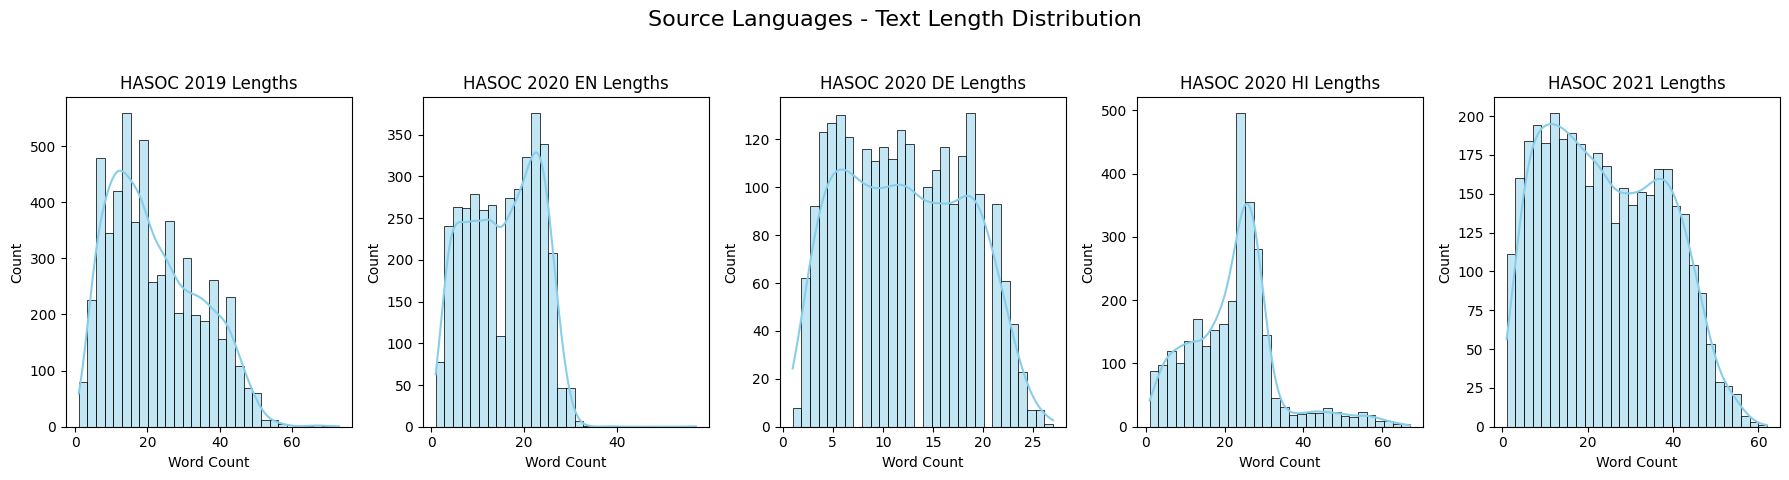

In [ ]:
plot_text_lengths(source_dfs, source_names, "Source Languages")

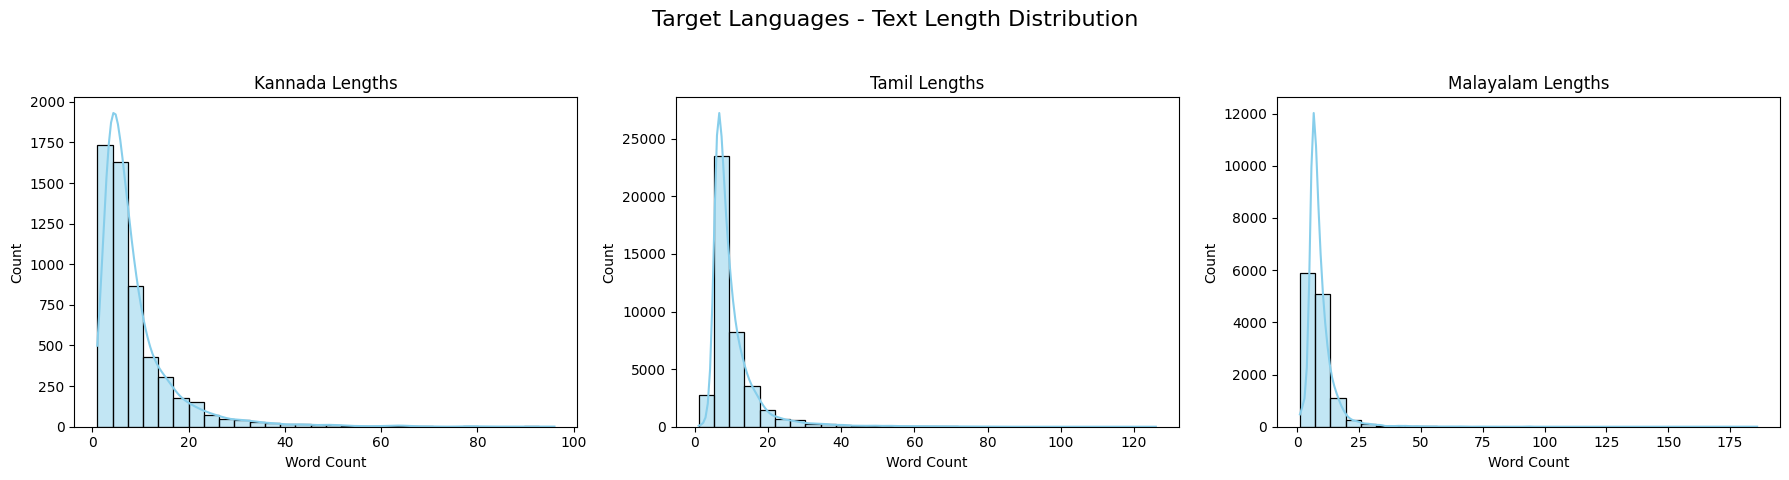

In [ ]:
plot_text_lengths(target_dfs, target_names, "Target Languages")

/tmp/ipykernel_5005/905603238.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


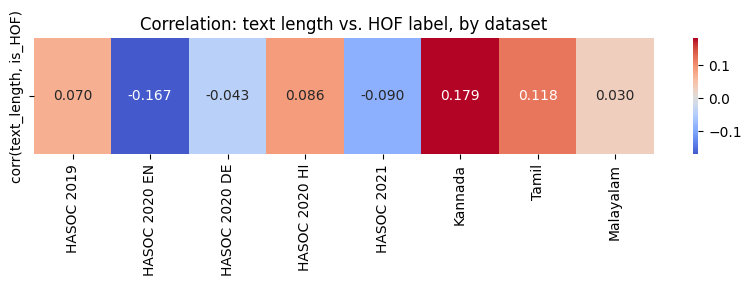

In [ ]:
all_dfs = source_dfs + target_dfs
all_names = source_names + target_names

corr_rows = {}
for df, name in zip(all_dfs, all_names):
    lengths = df['text'].str.split().str.len()
    is_hof = (df['label'] == 'HOF').astype(int)
    corr_rows[name] = lengths.corr(is_hof)

corr_series = pd.Series(corr_rows, name='corr(text_length, is_HOF)')
plt.figure(figsize=(10, 1.5))
sns.heatmap(corr_series.to_frame().T, annot=True, fmt='.3f', cmap='coolwarm', center=0, cbar=True)
plt.title('Correlation: text length vs. HOF label, by dataset')
plt.tight_layout()
plt.show()


The heatmap above shows the correlation between text length (word count) and the HOF label for each source and target dataset. Values close to zero across the board indicate that text length alone is not a strong predictor of offensiveness in either the source (English/German/Hindi HASOC) or target (Kannada/Tamil/Malayalam) data -- any positive or negative lean is slight and dataset-specific, not a pattern that generalizes across languages.

## Splitting the Datasets

Establishes the fixed 80/10/10 train/val/test split per target language that stays constant across every subsequent experiment (RQ1 zero-shot, RQ2 few-shot sweep, RQ4 LIME, monolingual upper bound) — only the *train* pool size varies between them.

In [ ]:
# 80/10/10 train/val/test split per Dravidian target language, stratified on label.

def split_80_10_10(df, name, seed=42):
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=seed, stratify=df['label'])
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=seed, stratify=temp_df['label'])
    print(f"{name}: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

kannada_train_h, kannada_val_h, kannada_test_h = split_80_10_10(kannada_h, "Kannada")
tamil_train_h, tamil_val_h, tamil_test_h = split_80_10_10(tamil_h, "Tamil")
malyalam_train_h, malyalam_val_h, malyalam_test_h = split_80_10_10(malyalam_h, "Malayalam")

target_splits = {
    'Kannada': {'train': kannada_train_h, 'val': kannada_val_h, 'test': kannada_test_h},
    'Tamil': {'train': tamil_train_h, 'val': tamil_val_h, 'test': tamil_test_h},
    'Malayalam': {'train': malyalam_train_h, 'val': malyalam_val_h, 'test': malyalam_test_h},
}

Kannada: train=4472, val=559, test=559
Tamil: train=33346, val=4168, test=4169
Malayalam: train=10070, val=1259, test=1259


## Training Baseline Model

TF-IDF + Logistic Regression per target language — a non-transformer reference point that the RQ1-RQ4 transformer-based results are compared against.

In [ ]:
def run_baseline_corrected(X_train, y_train, X_test, y_test, name):
    print(f"\n \u001b[1m --- Baseline Results for {name} (using 80/10/10 split) --- \u001b[0m")

    # Convert text to numbers using TF-IDF
    vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    # Train Logistic Regression with class weighting
    clf = LogisticRegression(class_weight='balanced', max_iter=1000)
    clf.fit(X_train_tfidf, y_train)

    # Evaluate
    y_pred = clf.predict(X_test_tfidf)

    # Get classification report as a dictionary
    report_dict = classification_report(y_test, y_pred, output_dict=True)

    # Convert dictionary to DataFrame and display
    df_report = pd.DataFrame(report_dict).transpose()
    print("  ")
    display(df_report)
    print("\n -------------------------------------------------------")

    macro_f1 = f1_score(y_test, y_pred, average='macro')

    # Return results as a dictionary
    return {
        'Language': name,
        'Macro F1-score': macro_f1,
        'classification_report': report_dict
    }

# Clear previous baseline results to avoid confusion if the earlier baseline cell was run
baseline_results_list = []
baseline_scores = {}

# Re-run baseline with the newly defined 80/10/10 splits
for lang, splits in target_splits.items():
    train_df = splits['train']
    test_df = splits['test']

    if 'label_map' not in globals():
        print("label_map not found. Defining it for session consistency.")
        label_map = {'NOT': 0, 'HOF': 1} # This mapping is consistent with iYO0bPnvnZ5c

    # Call the corrected baseline function
    baseline_results_list.append(run_baseline_corrected(
        train_df['text'], train_df['label'],
        test_df['text'], test_df['label'],
        lang
    ))

# Re-convert list of scores to a dictionary for easier lookup
baseline_scores = {res['Language']: res['Macro F1-score'] for res in baseline_results_list}

print("Baseline re-executed with consistent 80/10/10 splits for all languages.")

label_map not found. Defining it for session consistency.

  --- Baseline Results for Kannada (using 80/10/10 split) --- 
  


,precision,recall,f1-score,support
HOF,0.621118,0.684932,0.651466,146.000000
NOT,0.884422,0.852300,0.868064,413.000000
accuracy,0.808587,0.808587,0.808587,0.808587
macro avg,0.752770,0.768616,0.759765,559.000000
weighted avg,0.815652,0.808587,0.811493,559.000000



 -------------------------------------------------------

  --- Baseline Results for Tamil (using 80/10/10 split) --- 
  


,precision,recall,f1-score,support
HOF,0.551176,0.776047,0.644561,1027.000000
NOT,0.915534,0.793444,0.850128,3142.000000
accuracy,0.789158,0.789158,0.789158,0.789158
macro avg,0.733355,0.784745,0.747345,4169.000000
weighted avg,0.825777,0.789158,0.799488,4169.000000



 -------------------------------------------------------

  --- Baseline Results for Malayalam (using 80/10/10 split) --- 
  


,precision,recall,f1-score,support
HOF,0.358025,0.591837,0.446154,49.000000
NOT,0.983022,0.957025,0.969849,1210.000000
accuracy,0.942812,0.942812,0.942812,0.942812
macro avg,0.670523,0.774431,0.708002,1259.000000
weighted avg,0.958697,0.942812,0.949467,1259.000000



 -------------------------------------------------------
Baseline re-executed with consistent 80/10/10 splits for all languages.


# RQ1: Zero Shot Cross Lingual Transfer

## RQ1: Model Tokenisation - XLM-RoBERTa-base

Training the XLM-RoBERTa-base model on the combined English, German, and Hindi HASOC datasets.

In [ ]:
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)


# CONFIGURATION

# IMPORTANT:

# False = use all available source-language data
# True = downsample each language to the size of the smallest source-language pool


BALANCE_SOURCE_LANGUAGES = True

SOURCE_RANDOM_SEED = 42


# LABEL MAP

label_map = {
    'NOT': 0,
    'HOF': 1
}


# ADD SOURCE METADATA

def prepare_source_dataset(
    df,
    language,
    dataset_name
):

    """
    Adds source-language and source-dataset metadata.

    This metadata is retained for auditing and can later be
    removed before HuggingFace Dataset conversion.
    """

    df = df.copy()

    df['source_language'] = language

    df['source_dataset'] = dataset_name

    return df[
        [
            'text',
            'label',
            'source_language',
            'source_dataset'
        ]
    ]


# PREPARE INDIVIDUAL SOURCE DATASETS

source_hsc19_en = prepare_source_dataset(
    hsc19_h,
    language='English',
    dataset_name='HASOC 2019'
)


source_hsc20_en = prepare_source_dataset(
    hsc20_en_h,
    language='English',
    dataset_name='HASOC 2020 English'
)


source_hsc21_en = prepare_source_dataset(
    hsc21_h,
    language='English',
    dataset_name='HASOC 2021'
)


source_hsc20_de = prepare_source_dataset(
    hsc20_de_h,
    language='German',
    dataset_name='HASOC 2020 German'
)


source_hsc20_hi = prepare_source_dataset(
    hsc20_hi_h,
    language='Hindi',
    dataset_name='HASOC 2020 Hindi'
)


# COMBINE SOURCE DATA

source_train_df_raw = pd.concat(
    [
        source_hsc19_en,
        source_hsc20_en,
        source_hsc21_en,
        source_hsc20_de,
        source_hsc20_hi
    ],
    ignore_index=True
)


# VALIDATION

assert (
    source_train_df_raw['label']
    .isin(['NOT', 'HOF'])
    .all()
), (
    "Unexpected labels found in source dataset."
)


assert (
    source_train_df_raw['source_language']
    .isin(
        [
            'English',
            'German',
            'Hindi'
        ]
    )
    .all()
), (
    "Unexpected source language found."
)


print("\n" + "-" * 80)

print(
    "SOURCE LANGUAGE TRAINING POOL AUDIT"
)

print("-" * 80)


print(
    f"\nTotal source examples: "
    f"{len(source_train_df_raw):,}"
)


# DATASET-LEVEL COMPOSITION

print(
    "\nSOURCE DATASET COMPOSITION"
)

dataset_summary = (
    source_train_df_raw
    .groupby(
        [
            'source_language',
            'source_dataset'
        ]
    )
    .size()
    .reset_index(
        name='samples'
    )
)


dataset_summary[
    'percentage_of_total'
] = (
    dataset_summary['samples']
    / len(source_train_df_raw)
    * 100
)


display(
    dataset_summary
    .sort_values(
        'samples',
        ascending=False
    )
    .reset_index(
        drop=True
    )
    .round(2)
)


# LANGUAGE-LEVEL COMPOSITION

print(
    "\nSOURCE LANGUAGE COMPOSITION"
)

language_summary = (
    source_train_df_raw[
        'source_language'
    ]
    .value_counts()
    .rename_axis(
        'source_language'
    )
    .reset_index(
        name='samples'
    )
)


language_summary[
    'percentage_of_total'
] = (
    language_summary['samples']
    / len(source_train_df_raw)
    * 100
)


display(
    language_summary
    .round(2)
)


# LANGUAGE × CLASS COMPOSITION

print(
    "\nSOURCE LANGUAGE × CLASS DISTRIBUTION"
)


language_class_summary = (
    pd.crosstab(
        source_train_df_raw[
            'source_language'
        ],
        source_train_df_raw[
            'label'
        ]
    )
)


# Ensure both columns exist
for label in [
    'NOT',
    'HOF'
]:

    if label not in language_class_summary.columns:

        language_class_summary[
            label
        ] = 0


language_class_summary[
    'Total'
] = (
    language_class_summary[
        [
            'NOT',
            'HOF'
        ]
    ]
    .sum(
        axis=1
    )
)


language_class_summary[
    'HOF_%'
] = (
    language_class_summary['HOF']
    / language_class_summary['Total']
    * 100
)


language_class_summary[
    'NOT_%'
] = (
    language_class_summary['NOT']
    / language_class_summary['Total']
    * 100
)


display(
    language_class_summary
    .round(2)
)


# AUTOMATIC LANGUAGE IMBALANCE DIAGNOSTIC

largest_language_size = (
    language_summary[
        'samples'
    ]
    .max()
)


smallest_language_size = (
    language_summary[
        'samples'
    ]
    .min()
)


language_imbalance_ratio = (
    largest_language_size
    / smallest_language_size
)


largest_language = (
    language_summary.loc[
        language_summary[
            'samples'
        ].idxmax(),
        'source_language'
    ]
)


smallest_language = (
    language_summary.loc[
        language_summary[
            'samples'
        ].idxmin(),
        'source_language'
    ]
)


print(
    "\nLANGUAGE IMBALANCE DIAGNOSTIC"
)

print(
    f"Largest language: "
    f"{largest_language} "
    f"({largest_language_size:,} samples)"
)

print(
    f"Smallest language: "
    f"{smallest_language} "
    f"({smallest_language_size:,} samples)"
)

print(
    f"Language size ratio: "
    f"{language_imbalance_ratio:.2f}:1"
)


if language_imbalance_ratio >= 2:

    print(
        "\nWARNING: Source-language imbalance "
        "ratio is >= 2:1."
    )

    print(
        "Consider running a balanced-source "
        "experiment as a robustness check."
    )

else:

    print(
        "\n✓ Source-language sample sizes are "
        "within a 2:1 ratio."
    )


# OPTIONAL LANGUAGE BALANCING

def balance_source_languages(
    df,
    language_col='source_language',
    seed=42
):

    """
    Downsamples every language to the size of the
    smallest language pool.

    This creates equal total representation for:

        English
        German
        Hindi

    NOTE:
    This does not force equal HOF/NOT counts within
    each language. It balances language contribution
    only.
    """

    language_counts = (
        df[language_col]
        .value_counts()
    )


    target_size = (
        language_counts
        .min()
    )


    print(
        "\nBalancing source languages..."
    )

    print(
        f"Target samples per language: "
        f"{target_size:,}"
    )


    balanced_parts = []


    for language in sorted(
        df[language_col]
        .unique()
    ):

        language_df = df[
            df[language_col]
            == language
        ]


        if len(language_df) > target_size:

            sampled_language_df = (
                language_df
                .sample(
                    n=target_size,
                    random_state=seed
                )
            )

        else:

            sampled_language_df = (
                language_df
                .copy()
            )


        balanced_parts.append(
            sampled_language_df
        )


    balanced_df = pd.concat(
        balanced_parts,
        ignore_index=True
    )


    # Shuffle final combined pool
    balanced_df = (
        balanced_df
        .sample(
            frac=1,
            random_state=seed
        )
        .reset_index(
            drop=True
        )
    )


    return balanced_df


# APPLY BALANCING OR KEEP FULL DATA

if BALANCE_SOURCE_LANGUAGES:

    source_train_df = (
        balance_source_languages(
            source_train_df_raw,
            seed=SOURCE_RANDOM_SEED
        )
    )

    print(
        "\n✓ Using BALANCED source-language pool."
    )

else:

    source_train_df = (
        source_train_df_raw
        .copy()
    )

    print(
        "\n✓ Using FULL source-language pool."
    )


# FINAL SOURCE POOL AUDIT

print(
    "\nFINAL SOURCE POOL"
)

final_language_summary = (
    source_train_df[
        'source_language'
    ]
    .value_counts()
)


print(
    final_language_summary
)


print(
    f"\nFinal source pool size: "
    f"{len(source_train_df):,}"
)


# CONVERT LABELS TO NUMERIC

source_train_df = (
    source_train_df
    .copy()
)


source_train_df[
    'label'
] = (
    source_train_df[
        'label'
    ]
    .map(
        label_map
    )
)


assert (
    source_train_df[
        'label'
    ]
    .isin(
        [
            0,
            1
        ]
    )
    .all()
), (
    "Numeric label conversion failed."
)


# LOAD TOKENIZER

model_name = (
    'xlm-roberta-base'
)


tokenizer = (
    AutoTokenizer
    .from_pretrained(
        model_name
    )
)


def tokenize_function(
    examples
):

    return tokenizer(
        examples[
            'text'
        ],
        truncation=True,
        max_length=128
    )


# PREPARE DATA FOR TRAINING

# Keep only columns needed by the model.
#
# source_language and source_dataset remain
# available in source_train_df for analysis,
# but are not passed into the HuggingFace model.

source_training_columns = (
    source_train_df[
        [
            'text',
            'label'
        ]
    ]
    .copy()
)


source_dataset = (
    Dataset
    .from_pandas(
        source_training_columns,
        preserve_index=False
    )
)


source_dataset = (
    source_dataset
    .map(
        tokenize_function,
        batched=True
    )
)


print(
    "\n✓ Tokenization complete."
)

print(
    f"✓ Source training pool ready: "
    f"{len(source_train_df):,} samples."
)

print(
    f"✓ Source language balancing enabled: "
    f"{BALANCE_SOURCE_LANGUAGES}"
)


--------------------------------------------------------------------------------
SOURCE LANGUAGE TRAINING POOL AUDIT
--------------------------------------------------------------------------------

Total source examples: 18,410

SOURCE DATASET COMPOSITION


,source_language,source_dataset,samples,percentage_of_total
0,English,HASOC 2019,5690,30.91
1,English,HASOC 2021,3758,20.41
2,English,HASOC 2020 English,3665,19.91
3,Hindi,HASOC 2020 Hindi,2943,15.99
4,German,HASOC 2020 German,2354,12.79



SOURCE LANGUAGE COMPOSITION


,source_language,samples,percentage_of_total
0,English,13113,71.23
1,Hindi,2943,15.99
2,German,2354,12.79



SOURCE LANGUAGE × CLASS DISTRIBUTION


...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/7062 [00:00<?, ? examples/s]


✓ Tokenization complete.
✓ Source training pool ready: 7,062 samples.
✓ Source language balancing enabled: True


##RQ1: Model Definitions - XLM-RoBERTa-base

In [ ]:
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, AutoModelForSequenceClassification, AutoTokenizer
from evaluate import load
from datasets import ClassLabel
import os # Ensure os is imported
import torch # Ensure torch is imported for device check
import numpy as np # Ensure numpy is imported for compute_metrics
from transformers.trainer_utils import get_last_checkpoint # Added to detect latest checkpoint

# 1. Device check — extended to cover MacBook MPS, not just CUDA/CPU.
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

# 2. Cast label column to ClassLabel to enable stratified split
source_dataset = source_dataset.cast_column("label", ClassLabel(num_classes=2, names=["NOT", "HOF"]))

# Apply 80/10/10 split to source_dataset for consistency with target splits
# First, split the dataset into 80% for training and 20% for temporary (validation+test)
initial_split = source_dataset.train_test_split(test_size=0.2, seed=42, stratify_by_column="label")
train_ds = initial_split['train'] # 80% for training

# Now, split the remaining 20% (initial_split['test']) into two equal halves (10% each) for validation
temp_for_val_test = initial_split['test']
val_test_split = temp_for_val_test.train_test_split(test_size=0.5, seed=42, stratify_by_column="label")
eval_ds = val_test_split['train']      # 10% validation
source_test_ds = val_test_split['test'] # 10% held-out test set

print(f"Source train_ds size: {len(train_ds)}")
print(f"Source eval_ds size: {len(eval_ds)}")
print(f"Source test_ds size: {len(source_test_ds)}")

# 3. Metrics
acc_metric = load("accuracy")
f1_metric = load("f1")
precision_metric = load("precision")
recall_metric = load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = acc_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    prec = precision_metric.compute(predictions=predictions, references=labels, average="macro")["precision"]
    rec = recall_metric.compute(predictions=predictions, references=labels, average="macro")["recall"]
    return {"accuracy": acc, "f1": f1, "precision": prec, "recall": rec}

# Ensure DRIVE_CHECKPOINT_BASE_DIR is defined before use
assert 'DRIVE_CHECKPOINT_BASE_DIR' in globals(), (
    "DRIVE_CHECKPOINT_BASE_DIR is not defined -- run the 'Mounting Google Drive' cell "
    "near the top of the notebook first."
)

SOURCE_MODEL_OUTPUT_DIR = os.path.join(DRIVE_CHECKPOINT_BASE_DIR, 'results_source')

# 4. Smart Checkpoint & Model Loading Logic
source_model_already_trained = False
last_checkpoint = None
SOURCE_MODEL_FINAL_PATH = os.path.join(DRIVE_CHECKPOINT_BASE_DIR, 'results_source_final')

# Option A: Full trained model exists -> Load completely
if os.path.exists(SOURCE_MODEL_FINAL_PATH) and os.path.isdir(SOURCE_MODEL_FINAL_PATH):
    print(f"Found fully trained source model at {SOURCE_MODEL_FINAL_PATH}. Loading model...")
    model = AutoModelForSequenceClassification.from_pretrained(SOURCE_MODEL_FINAL_PATH).to(device)
    tokenizer = AutoTokenizer.from_pretrained(SOURCE_MODEL_FINAL_PATH)
    source_model_already_trained = True

else:
    # Option B: Check if an intermediate training checkpoint exists to resume from
    if os.path.exists(SOURCE_MODEL_OUTPUT_DIR):
        last_checkpoint = get_last_checkpoint(SOURCE_MODEL_OUTPUT_DIR)

    if last_checkpoint is not None:
        print(f"Found latest training checkpoint at {last_checkpoint}. Will resume training from here!")
        model = AutoModelForSequenceClassification.from_pretrained(last_checkpoint).to(device)
    else:
        print(f"No existing model or checkpoints found. Initializing new model from '{model_name}'.")
        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 5. Training arguments
training_args = TrainingArguments(
    output_dir=SOURCE_MODEL_OUTPUT_DIR,
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=3, # Default epochs
    weight_decay=0.01,
    fp16=True if device == "cuda" else False, # Only use fp16 if CUDA is available
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to='none',
    logging_steps=50,
)

# Skip training completely if full model was already loaded
if source_model_already_trained:
    print("Source model already loaded, setting num_train_epochs to 0 to skip training.")
    training_args.num_train_epochs = 0

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# 6. Execute Training (or Resume from Checkpoint)
if not source_model_already_trained:
    if last_checkpoint is not None:
        print(f"Resuming training from checkpoint: {last_checkpoint}")
        train_result = trainer.train(resume_from_checkpoint=last_checkpoint)
    else:
        print("Starting fresh training...")
        train_result = trainer.train()
else:
    train_result = trainer.train() # Epochs set to 0, will pass through instantly

# 7. Save Final Model and Tokenizer
trainer.save_model(SOURCE_MODEL_FINAL_PATH)
tokenizer.save_pretrained(SOURCE_MODEL_FINAL_PATH)
print(f"Source model saved to: {SOURCE_MODEL_FINAL_PATH}")

# Free up memory and GPU resources after training
del model
del trainer
if device == "cuda":
    torch.cuda.empty_cache()
print("Model and trainer objects deleted, GPU cache emptied.")

Using device: cuda


Casting the dataset:   0%|          | 0/7062 [00:00<?, ? examples/s]

Source train_ds size: 5649
Source eval_ds size: 706
Source test_ds size: 707


Found fully trained source model at /content/drive/MyDrive/thesis_checkpoints/results_source_final. Loading model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Source model already loaded, setting num_train_epochs to 0 to skip training.


Epoch,Training Loss,Validation Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Source model saved to: /content/drive/MyDrive/thesis_checkpoints/results_source_final
Model and trainer objects deleted, GPU cache emptied.


##RQ1: Model Evaluation: Zero-Shot Cross-Lingual

In [ ]:
import os
import json
import gc
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)


# RESULTS DIRECTORY

ZERO_SHOT_RESULTS_DIR = os.path.join(
    DRIVE_CHECKPOINT_BASE_DIR,
    "zero_shot_results"
)

os.makedirs(
    ZERO_SHOT_RESULTS_DIR,
    exist_ok=True
)


# TARGET LANGUAGES

ZERO_SHOT_LANGUAGES = [
    "Kannada",
    "Tamil",
    "Malayalam"
]


# RESULTS REGISTRY

zero_shot_results = {}

zero_shot_reports = {}

zero_shot_confusion_matrices = {}


# EVALUATION FUNCTION

def evaluate_zero_shot_target_language(
    lang_name,
    force_re_evaluation=False
):

    # CHECK LANGUAGE

    if lang_name not in target_splits:

        raise ValueError(
            f"Language '{lang_name}' "
            f"not found in target_splits.\n\n"
            f"Available languages:\n"
            f"{list(target_splits.keys())}"
        )


    # SOURCE MODEL

    if not os.path.isdir(
        SOURCE_MODEL_FINAL_PATH
    ):

        raise FileNotFoundError(

            "Source model was not found:\n"
            f"{SOURCE_MODEL_FINAL_PATH}\n\n"
            "Train and save the source model "
            "before running zero-shot evaluation."

        )


    # RESULT PATH

    safe_language = (
        lang_name
        .lower()
        .replace(" ", "_")
    )


    result_path = os.path.join(

        ZERO_SHOT_RESULTS_DIR,

        f"{safe_language}_zero_shot.json"

    )


    # LOAD EXISTING RESULTS

    if (

        os.path.exists(result_path)

        and not force_re_evaluation

    ):

        print(
            "\n✓ Existing zero-shot result found."
        )

        with open(
            result_path,
            "r",
            encoding="utf-8"
        ) as f:

            result = json.load(f)


        zero_shot_results[
            lang_name
        ] = result["macro_f1"]


        zero_shot_reports[
            lang_name
        ] = result["classification_report"]


        zero_shot_confusion_matrices[
            lang_name
        ] = np.array(
            result["confusion_matrix"]
        )


        print(
            f"\nLanguage: {lang_name}"
        )

        print(
            f"Accuracy: "
            f"{result['accuracy']:.4f}"
        )

        print(
            f"Macro Precision: "
            f"{result['macro_precision']:.4f}"
        )

        print(
            f"Macro Recall: "
            f"{result['macro_recall']:.4f}"
        )

        print(
            f"Macro-F1: "
            f"{result['macro_f1']:.4f}"
        )


        return result


    # HEADER

    print(
        "\n" + "-" * 80
    )

    print(
        "RQ1 — ZERO-SHOT CROSS-LINGUAL EVALUATION"
    )

    print(
        "-" * 80
    )

    print(
        f"Target language: {lang_name}"
    )

    print(
        f"Source model: "
        f"{SOURCE_MODEL_FINAL_PATH}"
    )


    # IMPORTANT:
    # USE TARGET TEST SET ONLY

    target_test_df = (

        target_splits[
            lang_name
        ][
            "test"
        ]

        .copy()

        .reset_index(
            drop=True
        )

    )


    print(
        f"\nTarget test examples: "
        f"{len(target_test_df)}"
    )


    # PREPARE TEST DATA

    test_df = target_test_df[
        [
            "text",
            "label"
        ]
    ].copy()


    # LABEL CONVERSION

    if test_df["label"].dtype == object:

        test_df["label"] = (
            test_df["label"]
            .map(label_map)
        )


    if test_df["label"].isna().any():

        raise ValueError(
            f"Invalid labels found in "
            f"{lang_name} test set."
        )


    test_df["label"] = (
        test_df["label"]
        .astype(int)
    )


    # CONVERT TO HF DATASET

    target_test_dataset = Dataset.from_pandas(

        test_df,

        preserve_index=False

    )


    # TOKENIZE

    target_test_dataset = (
        target_test_dataset
        .map(
            tokenize_function,
            batched=True
        )
    )


    # LOAD SOURCE MODEL

    print(
        "\nLoading source model..."
    )


    zero_shot_model = (

        AutoModelForSequenceClassification

        .from_pretrained(

            SOURCE_MODEL_FINAL_PATH,

            num_labels=2

        )

        .to(device)

    )


    zero_shot_model.eval()


    # EVALUATION TRAINER

    zero_shot_args = TrainingArguments(

        output_dir=os.path.join(

            ZERO_SHOT_RESULTS_DIR,

            "temporary"

        ),

        per_device_eval_batch_size=16,

        report_to="none"

    )


    zero_shot_trainer = Trainer(

        model=zero_shot_model,

        args=zero_shot_args,

        data_collator=data_collator

    )


    # PREDICTION

    print(
        "\nGenerating zero-shot predictions..."
    )


    prediction_output = (

        zero_shot_trainer.predict(

            target_test_dataset

        )

    )


    logits = (
        prediction_output.predictions
    )


    predictions = np.argmax(

        logits,

        axis=-1

    )


    labels = np.array(

        test_df["label"]

    )


    # METRICS

    accuracy = accuracy_score(

        labels,

        predictions

    )


    macro_precision = precision_score(

        labels,

        predictions,

        average="macro",

        zero_division=0

    )


    macro_recall = recall_score(

        labels,

        predictions,

        average="macro",

        zero_division=0

    )


    macro_f1 = f1_score(

        labels,

        predictions,

        average="macro",

        zero_division=0

    )


    # CLASSIFICATION REPORT

    report = classification_report(

        labels,

        predictions,

        labels=[
            0,
            1
        ],

        target_names=[
            "NOT",
            "HOF"
        ],

        output_dict=True,

        zero_division=0

    )


    # CONFUSION MATRIX

    cm = confusion_matrix(

        labels,

        predictions,

        labels=[
            0,
            1
        ]

    )


    # DISPLAY RESULTS

    print(
        "\n" + "=" * 80
    )

    print(
        f"ZERO-SHOT RESULTS — {lang_name}"
    )

    print(
        "=" * 80
    )

    print(
        f"Test size: "
        f"{len(test_df)}"
    )

    print(
        f"Accuracy: "
        f"{accuracy:.4f}"
    )

    print(
        f"Macro Precision: "
        f"{macro_precision:.4f}"
    )

    print(
        f"Macro Recall: "
        f"{macro_recall:.4f}"
    )

    print(
        f"Macro-F1: "
        f"{macro_f1:.4f}"
    )


    print(
        "\nClassification Report:"
    )


    display(

        pd.DataFrame(
            report
        )
        .transpose()
        .round(4)

    )


    print(
        "\nConfusion Matrix:"
    )


    display(

        pd.DataFrame(

            cm,

            index=[
                "Actual NOT",
                "Actual HOF"
            ],

            columns=[
                "Predicted NOT",
                "Predicted HOF"
            ]

        )

    )


    # SAVE RESULT

    result = {

        "experiment":
            "zero_shot_cross_lingual",

        "source_model":
            SOURCE_MODEL_FINAL_PATH,

        "target_language":
            lang_name,

        "evaluation_split":
            "target_test",

        "test_size":
            int(
                len(test_df)
            ),

        "accuracy":
            float(
                accuracy
            ),

        "macro_precision":
            float(
                macro_precision
            ),

        "macro_recall":
            float(
                macro_recall
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "classification_report":
            report,

        "confusion_matrix":
            cm.tolist()

    }


    with open(

        result_path,

        "w",

        encoding="utf-8"

    ) as f:

        json.dump(

            result,

            f,

            indent=4

        )


    print(
        "\n✓ Results saved:"
    )

    print(
        result_path
    )


    # UPDATE REGISTRIES

    zero_shot_results[
        lang_name
    ] = macro_f1


    zero_shot_reports[
        lang_name
    ] = report


    zero_shot_confusion_matrices[
        lang_name
    ] = cm


    # CLEANUP

    del zero_shot_model

    del zero_shot_trainer

    gc.collect()


    if device == "cuda":

        torch.cuda.empty_cache()

    elif device == "mps":

        if hasattr(
            torch.mps,
            "empty_cache"
        ):

            torch.mps.empty_cache()


    return result

### Kannada Zero Shot Results

In [ ]:
kannada_zero_shot = evaluate_zero_shot_target_language(
    lang_name="Kannada"
)


✓ Existing zero-shot result found.

Language: Kannada
Accuracy: 0.7299
Macro Precision: 0.6298
Macro Recall: 0.5980
Macro-F1: 0.6054


### Tamil Zero Shot Results

In [ ]:
tamil_zero_shot = evaluate_zero_shot_target_language(
    lang_name="Tamil"
)


✓ Existing zero-shot result found.

Language: Tamil
Accuracy: 0.7345
Macro Precision: 0.6143
Macro Recall: 0.5817
Macro-F1: 0.5880


### Malyalam Zero Shot Results

In [ ]:
malayalam_zero_shot = evaluate_zero_shot_target_language(
    lang_name="Malayalam"
)


✓ Existing zero-shot result found.

Language: Malayalam
Accuracy: 0.7792
Macro Precision: 0.5205
Macro Recall: 0.5914
Macro-F1: 0.4970


RQ1: Zero Shot Results Summary

In [ ]:
rq1_zero_shot_summary = pd.DataFrame({

    "Language": [

        "Kannada",
        "Tamil",
        "Malayalam"

    ],

    "Accuracy": [

        kannada_zero_shot["accuracy"],
        tamil_zero_shot["accuracy"],
        malayalam_zero_shot["accuracy"]

    ],

    "Macro Precision": [

        kannada_zero_shot["macro_precision"],
        tamil_zero_shot["macro_precision"],
        malayalam_zero_shot["macro_precision"]

    ],

    "Macro Recall": [

        kannada_zero_shot["macro_recall"],
        tamil_zero_shot["macro_recall"],
        malayalam_zero_shot["macro_recall"]

    ],

    "Macro F1": [

        kannada_zero_shot["macro_f1"],
        tamil_zero_shot["macro_f1"],
        malayalam_zero_shot["macro_f1"]

    ]

})


display(
    rq1_zero_shot_summary.round(4)
)

,Language,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Kannada,0.7299,0.6298,0.5980,0.6054
1,Tamil,0.7345,0.6143,0.5817,0.5880
2,Malayalam,0.7792,0.5205,0.5914,0.4970


# RQ2 & RQ4: Few Shot Cross Lingual Transfer & Seed Robustness


## RQ2: Few-shot  — Model Training


## Few Shot Stratified Sampling Function

In [ ]:
import os
import json
import numpy as np
import pandas as pd


# FEW-SHOT SAMPLE DIRECTORY

FEW_SHOT_SAMPLE_DIR = os.path.join(
    DRIVE_CHECKPOINT_BASE_DIR,
    "few_shot_samples"
)

os.makedirs(
    FEW_SHOT_SAMPLE_DIR,
    exist_ok=True
)


# FEW-SHOT SAMPLING AUDIT

few_shot_sampling_audit = []


# STRATIFIED FEW-SHOT SAMPLING

def sample_stratified(
    train_df,
    n,
    seed=42,
    language=None,
    reuse_existing_sample=True
):

    # INPUT VALIDATION

    if not isinstance(train_df, pd.DataFrame):

        raise TypeError(
            "train_df must be a pandas DataFrame."
        )


    required_columns = [
        "text",
        "label"
    ]


    missing_columns = [

        column

        for column in required_columns

        if column not in train_df.columns

    ]


    if missing_columns:

        raise ValueError(

            f"Missing required columns: "
            f"{missing_columns}"

        )


    if n <= 0:

        raise ValueError(
            "n must be greater than 0."
        )


    if len(train_df) < n:

        raise ValueError(

            f"Requested {n} examples, but only "
            f"{len(train_df)} examples are available."

        )


    # LABEL VALIDATION

    class_counts = (

        train_df[
            "label"
        ]

        .value_counts()

        .sort_index()

    )


    if len(class_counts) < 2:

        raise ValueError(

            "Few-shot sampling requires "
            "at least two classes."

        )


    if n < len(class_counts):

        raise ValueError(

            f"Shot size ({n}) must be at least "
            f"the number of classes ({len(class_counts)})."

        )


    # LANGUAGE NAME FOR FILE PATH

    if language is None:

        language = "unknown"


    safe_language = (

        str(language)

        .lower()

        .replace(
            " ",
            "_"
        )

    )


    # SAMPLE PATH

    sample_filename = (

        f"{safe_language}_"

        f"{n}_shot_"

        f"seed_{seed}.csv"

    )


    sample_path = os.path.join(

        FEW_SHOT_SAMPLE_DIR,

        sample_filename

    )


    metadata_path = os.path.join(

        FEW_SHOT_SAMPLE_DIR,

        sample_filename.replace(

            ".csv",

            "_metadata.json"

        )

    )


    # REUSE EXISTING SAMPLE

    if (

        reuse_existing_sample

        and

        os.path.exists(
            sample_path
        )

    ):

        print(
            "\n✓ Reusing existing few-shot sample:"
        )

        print(
            sample_path
        )


        sampled = pd.read_csv(
            sample_path
        )


        if len(sampled) != n:

            raise ValueError(

                f"Saved sample contains {len(sampled)} "
                f"rows instead of expected {n}."

            )


        print(
            "\nSaved sample distribution:"
        )


        print(

            sampled[
                "label"
            ]

            .value_counts()

        )


        return (

            sampled

            .reset_index(
                drop=True
            )

        )


    # PROPORTIONAL ALLOCATION

    proportions = (

        class_counts

        / class_counts.sum()

    )


    raw_allocation = (

        proportions

        * n

    )


    allocation = (

        np.floor(
            raw_allocation
        )

        .astype(int)

    )


    # Guarantee at least one example per class

    for label in allocation.index:

        if allocation[label] == 0:

            allocation[label] = 1


    # ADJUST TO EXACTLY N

    current_total = int(
        allocation.sum()
    )


    # Add missing samples

    while current_total < n:

        fractional = (

            raw_allocation

            - np.floor(
                raw_allocation
            )

        )


        ordered_labels = (

            fractional

            .sort_values(
                ascending=False
            )

            .index

            .tolist()

        )


        added = False


        for label in ordered_labels:

            if (

                allocation[label]

                <

                class_counts[label]

            ):

                allocation[label] += 1

                current_total += 1

                added = True

                break


        if not added:

            raise RuntimeError(

                "Unable to allocate additional "
                "few-shot examples."

            )


    # Remove excess samples

    while current_total > n:

        eligible_labels = (

            allocation[
                allocation > 1
            ]

        )


        if len(eligible_labels) == 0:

            raise RuntimeError(

                "Unable to reduce allocation while "
                "preserving all classes."

            )


        label_to_reduce = (

            eligible_labels

            .sort_values(
                ascending=False
            )

            .index[0]

        )


        allocation[
            label_to_reduce
        ] -= 1


        current_total -= 1


    # SAMPLE EACH CLASS

    sampled_parts = []


    for class_position, (
        label,
        count
    ) in enumerate(
        allocation.items()
    ):

        class_df = (

            train_df[
                train_df[
                    "label"
                ]
                == label
            ]

            .copy()

        )


        if len(class_df) < count:

            raise ValueError(

                f"Class '{label}' has "
                f"{len(class_df)} examples but "
                f"{count} were requested."

            )


        class_sample = (

            class_df

            .sample(

                n=int(count),

                random_state=(
                    seed
                    + class_position
                ),

                replace=False

            )

        )


        sampled_parts.append(
            class_sample
        )


    # COMBINE AND SHUFFLE

    sampled = (

        pd.concat(

            sampled_parts,

            ignore_index=True

        )

        .sample(

            frac=1,

            random_state=seed

        )

        .reset_index(
            drop=True
        )

    )


    # FINAL VALIDATION

    if len(sampled) != n:

        raise RuntimeError(

            f"Sampling failed. Expected {n}, "
            f"received {len(sampled)}."

        )


    if sampled["label"].nunique() != len(class_counts):

        raise RuntimeError(

            "Not all classes are represented "
            "in the few-shot sample."

        )


    # DISPLAY DISTRIBUTION

    actual_distribution = (

        sampled[
            "label"
        ]

        .value_counts()

        .sort_index()

    )


    print(
        "\n" + "=" * 70
    )

    print(
        f"FEW-SHOT SAMPLE — {language}"
    )

    print(
        "=" * 70
    )


    print(
        f"\nShot size: {n}"
    )


    print(
        f"Seed: {seed}"
    )


    print(
        "\nClass distribution:"
    )


    print(
        actual_distribution
    )


    # SAVE SAMPLE

    sampled.to_csv(

        sample_path,

        index=False

    )


    metadata = {

        "language":
            language,

        "shot_size":
            int(n),

        "seed":
            int(seed),

        "sample_size":
            int(
                len(sampled)
            ),

        "class_distribution":

            {

                str(label):
                    int(count)

                for label, count

                in actual_distribution.items()

            }

    }


    with open(

        metadata_path,

        "w",

        encoding="utf-8"

    ) as f:

        json.dump(

            metadata,

            f,

            indent=4,

            ensure_ascii=False

        )


    # AUDIT

    audit_record = {

        "language":
            language,

        "shot_size":
            n,

        "seed":
            seed,

        "sample_size":
            len(sampled),

        "sample_path":
            sample_path

    }


    for label in actual_distribution.index:

        audit_record[
            f"{label}_count"
        ] = int(
            actual_distribution[label]
        )


    few_shot_sampling_audit.append(
        audit_record
    )


    print(
        "\n✓ Few-shot sample saved:"
    )

    print(
        sample_path
    )


    return sampled

## Few Shot Training Function

In [ ]:
import os
import gc
import json
import numpy as np
import pandas as pd
import torch

from datasets import Dataset, ClassLabel

from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from transformers.trainer_utils import (
    get_last_checkpoint
)


# FEW-SHOT MODEL DIRECTORY

FEW_SHOT_MODEL_SAVE_DIR_BASE = os.path.join(

    DRIVE_CHECKPOINT_BASE_DIR,

    "few_shot_models"

)


os.makedirs(

    FEW_SHOT_MODEL_SAVE_DIR_BASE,

    exist_ok=True

)


# MODEL PATH REGISTRY

few_shot_model_paths = {}


# MAIN FEW-SHOT EXPERIMENT FUNCTION

def train_few_shot_experiment(

    lang_name,

    few_shot_size,

    seed=42,

    num_train_epochs=5,

    learning_rate=2e-5,

    train_batch_size=8,

    eval_batch_size=8,

    gradient_accumulation_steps=2,

    reuse_existing_sample=True

):


    # VALIDATE LANGUAGE

    if lang_name not in target_splits:

        raise ValueError(

            f"Language '{lang_name}' "
            f"not found in target_splits.\n"

            f"Available languages: "

            f"{list(target_splits.keys())}"

        )


    # VALIDATE SOURCE MODEL

    if not os.path.exists(
        SOURCE_MODEL_FINAL_PATH
    ):

        raise FileNotFoundError(

            "Source model not found:\n"

            f"{SOURCE_MODEL_FINAL_PATH}"

        )


    # SET RANDOM SEEDS

    np.random.seed(
        seed
    )


    torch.manual_seed(
        seed
    )


    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


    # GET LANGUAGE SPLITS

    language_splits = (

        target_splits[
            lang_name
        ]

    )


    train_df = (

        language_splits[
            "train"
        ]

        .copy()

    )


    val_df = (

        language_splits[
            "val"
        ]

        .copy()

    )


    test_df = (

        language_splits[
            "test"
        ]

        .copy()

    )


    # VALIDATE SHOT SIZE

    if few_shot_size > len(train_df):

        raise ValueError(

            f"{lang_name} training split has "
            f"{len(train_df)} examples, but "
            f"{few_shot_size} were requested."

        )


    # EXPERIMENT NAME

    safe_language = (

        lang_name

        .lower()

        .replace(
            " ",
            "_"
        )

    )


    experiment_name = (

        f"{safe_language}_"

        f"{few_shot_size}_shot_"

        f"seed_{seed}"

    )


    experiment_dir = os.path.join(

        FEW_SHOT_MODEL_SAVE_DIR_BASE,

        experiment_name

    )


    final_model_path = os.path.join(

        experiment_dir,

        "final_model"

    )


    os.makedirs(

        experiment_dir,

        exist_ok=True

    )


    # PRINT EXPERIMENT INFORMATION

    print(
        "\n" + "-" * 80
    )

    print(
        "FEW-SHOT TRAINING EXPERIMENT"
    )

    print(
        "-" * 80
    )


    print(
        f"Language: {lang_name}"
    )


    print(
        f"Few-shot size: {few_shot_size}"
    )


    print(
        f"Seed: {seed}"
    )


    print(
        f"Train pool size: {len(train_df)}"
    )


    print(
        f"Validation size: {len(val_df)}"
    )


    print(
        f"Test size: {len(test_df)}"
    )


    # CREATE / REUSE FEW-SHOT SAMPLE

    few_shot_df = sample_stratified(

        train_df=train_df,

        n=few_shot_size,

        seed=seed,

        language=lang_name,

        reuse_existing_sample=
            reuse_existing_sample

    )


    # PREPARE DATAFRAME

    def prepare_dataframe(
        df
    ):

        prepared_df = (

            df[
                [
                    "text",
                    "label"
                ]
            ]

            .copy()

        )


        prepared_df[
            "label"
        ] = (

            prepared_df[
                "label"
            ]

            .map(
                label_map
            )

        )


        if (

            prepared_df[
                "label"
            ]

            .isna()

            .any()

        ):

            unknown_labels = (

                df.loc[

                    prepared_df[
                        "label"
                    ]
                    .isna(),

                    "label"

                ]

                .unique()

                .tolist()

            )


            raise ValueError(

                f"Unknown labels found: "
                f"{unknown_labels}"

            )


        prepared_df[
            "label"
        ] = (

            prepared_df[
                "label"
            ]

            .astype(
                int
            )

        )


        return prepared_df


    # PREPARE DATA

    few_shot_prepared = (

        prepare_dataframe(
            few_shot_df
        )

    )


    val_prepared = (

        prepare_dataframe(
            val_df
        )

    )


    # CREATE HUGGING FACE DATASETS

    few_shot_dataset = (

        Dataset

        .from_pandas(

            few_shot_prepared,

            preserve_index=False

        )

    )


    val_dataset = (

        Dataset

        .from_pandas(

            val_prepared,

            preserve_index=False

        )

    )


    # TOKENIZATION

    few_shot_dataset = (

        few_shot_dataset

        .map(

            tokenize_function,

            batched=True

        )

    )


    val_dataset = (

        val_dataset

        .map(

            tokenize_function,

            batched=True

        )

    )


    # CAST LABEL COLUMN

    label_feature = ClassLabel(

        num_classes=2,

        names=[
            "NOT",
            "HOF"
        ]

    )


    few_shot_dataset = (

        few_shot_dataset

        .cast_column(

            "label",

            label_feature

        )

    )


    val_dataset = (

        val_dataset

        .cast_column(

            "label",

            label_feature

        )

    )


    # CHECK FINAL MODEL

    model_already_trained = (

        os.path.isdir(
            final_model_path
        )

    )


    # CHECK FOR RESUMABLE CHECKPOINT

    last_checkpoint = None


    if not model_already_trained:

        last_checkpoint = (

            get_last_checkpoint(
                experiment_dir
            )

        )


    # LOAD MODEL

    if model_already_trained:

        print(
            "\n✓ Final model already exists."
        )


        print(
            "Loading existing model."
        )


        model = (

            AutoModelForSequenceClassification

            .from_pretrained(

                final_model_path,

                num_labels=2

            )

            .to(
                device
            )

        )


    elif last_checkpoint is not None:

        print(
            "\n✓ Resuming from checkpoint:"
        )

        print(
            last_checkpoint
        )


        model = (

            AutoModelForSequenceClassification

            .from_pretrained(

                last_checkpoint,

                num_labels=2

            )

            .to(
                device
            )

        )


    else:

        print(
            "\nLoading source-trained model:"
        )

        print(
            SOURCE_MODEL_FINAL_PATH
        )


        model = (

            AutoModelForSequenceClassification

            .from_pretrained(

                SOURCE_MODEL_FINAL_PATH,

                num_labels=2

            )

            .to(
                device
            )

        )


    # TRAINING ARGUMENTS

    training_args = TrainingArguments(

        output_dir=
            experiment_dir,

        eval_strategy=
            "epoch",

        save_strategy=
            "epoch",

        save_total_limit=
            2,

        learning_rate=
            learning_rate,

        per_device_train_batch_size=
            train_batch_size,

        per_device_eval_batch_size=
            eval_batch_size,

        gradient_accumulation_steps=
            gradient_accumulation_steps,

        num_train_epochs=
            num_train_epochs,

        weight_decay=
            0.01,

        fp16=(
            device == "cuda"
        ),

        load_best_model_at_end=
            True,

        metric_for_best_model=
            "f1",

        greater_is_better=
            True,

        logging_steps=
            10,

        report_to=
            "none",

        seed=
            seed,

        data_seed=
            seed

    )


    # TRAINER

    trainer = Trainer(

        model=
            model,

        args=
            training_args,

        train_dataset=
            few_shot_dataset,

        eval_dataset=
            val_dataset,

        data_collator=
            data_collator,

        compute_metrics=
            compute_metrics

    )


    # TRAIN / RESUME / SKIP

    if model_already_trained:

        print(
            "\nTraining skipped because the "
            "final model already exists."
        )


    elif last_checkpoint is not None:

        print(
            "\nResuming training..."
        )


        trainer.train(

            resume_from_checkpoint=
                last_checkpoint

        )


    else:

        print(
            "\nStarting training..."
        )


        trainer.train()


    # SAVE FINAL MODEL

    if not model_already_trained:

        trainer.save_model(
            final_model_path
        )


        tokenizer.save_pretrained(
            final_model_path
        )


        print(
            "\n✓ Final model saved:"
        )


        print(
            final_model_path
        )


    # REGISTER MODEL PATH

    if lang_name not in few_shot_model_paths:

        few_shot_model_paths[
            lang_name
        ] = {}


    few_shot_model_paths[
        lang_name
    ][
        few_shot_size
    ] = final_model_path


    # SAVE METADATA

    metadata = {

        "language":
            lang_name,

        "few_shot_size":
            int(
                few_shot_size
            ),

        "seed":
            int(
                seed
            ),

        "train_pool_size":
            int(
                len(train_df)
            ),

        "few_shot_train_size":
            int(
                len(few_shot_dataset)
            ),

        "validation_size":
            int(
                len(val_dataset)
            ),

        "test_size":
            int(
                len(test_df)
            ),

        "source_model":
            SOURCE_MODEL_FINAL_PATH,

        "final_model":
            final_model_path,

        "best_checkpoint":
            trainer.state.best_model_checkpoint

    }


    metadata_path = os.path.join(

        experiment_dir,

        "experiment_metadata.json"

    )


    with open(

        metadata_path,

        "w",

        encoding="utf-8"

    ) as f:

        json.dump(

            metadata,

            f,

            indent=4,

            ensure_ascii=False

        )


    # MEMORY CLEANUP

    del model

    del trainer

    gc.collect()


    if device == "cuda":

        torch.cuda.empty_cache()


    elif device == "mps":

        if hasattr(
            torch.mps,
            "empty_cache"
        ):

            torch.mps.empty_cache()


    print(
        "\n✓ EXPERIMENT COMPLETED"
    )


    print(
        f"Language: {lang_name}"
    )


    print(
        f"Shot size: {few_shot_size}"
    )


    return final_model_path

## Few Shot Evaluation Function

In [ ]:
import os
import gc
import json
import numpy as np
import pandas as pd
import torch

from IPython.display import display

from datasets import Dataset

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)


# RESULTS DIRECTORY

RQ2_RESULTS_DIR = os.path.join(
    DRIVE_CHECKPOINT_BASE_DIR,
    "rq2_few_shot_results"
)

os.makedirs(
    RQ2_RESULTS_DIR,
    exist_ok=True
)


# RESULTS REGISTRIES

few_shot_results = {}

few_shot_reports = {}

few_shot_confusion_matrices = {}


# HELPER FUNCTION — PREPARE TEST DATA

def prepare_rq2_test_dataframe(df):

    test_prepared = (
        df[
            [
                "text",
                "label"
            ]
        ]
        .copy()
    )


    # CONVERT STRING LABELS SUCH AS NOT/HOF TO NUMERIC LABELS

    if test_prepared["label"].dtype == "object":

        test_prepared["label"] = (
            test_prepared["label"]
            .map(label_map)
        )


    # CHECK FOR INVALID OR MISSING LABELS

    if test_prepared["label"].isna().any():

        raise ValueError(
            "Unknown or missing labels found "
            "in the RQ2 test dataset."
        )


    # ENSURE LABELS ARE INTEGERS

    test_prepared["label"] = (
        test_prepared["label"]
        .astype(int)
    )


    return test_prepared


# MAIN RQ2 FEW-SHOT EVALUATION FUNCTION

def evaluate_rq2_few_shot(
    lang_name,
    few_shot_size,
    seed=42,
    batch_size=16,
    force_re_evaluation=False
):


    # 1. VALIDATE LANGUAGE

    if lang_name not in target_splits:

        raise ValueError(
            f"Language '{lang_name}' "
            f"not found in target_splits.\n\n"
            f"Available languages:\n"
            f"{list(target_splits.keys())}"
        )


    # 2. NORMALIZE LANGUAGE NAME

    safe_language = (
        lang_name
        .lower()
        .replace(" ", "_")
    )


    # 3. CREATE SEED-SPECIFIC EXPERIMENT NAME

    experiment_name = (
        f"{safe_language}_"
        f"{few_shot_size}_shot_"
        f"seed_{seed}"
    )


    # 4. CONSTRUCT MODEL PATH

    model_path = os.path.join(
        FEW_SHOT_MODEL_SAVE_DIR_BASE,
        experiment_name,
        "final_model"
    )


    # 5. CONSTRUCT RESULT FILE PATH

    result_filename = (
        f"{safe_language}_"
        f"{few_shot_size}_shot_"
        f"seed_{seed}.json"
    )


    result_path = os.path.join(
        RQ2_RESULTS_DIR,
        result_filename
    )


    # 6. PRINT EVALUATION HEADER

    print(
        "\n" + "=" * 80
    )

    print(
        "RQ2 — FEW-SHOT MODEL EVALUATION"
    )

    print(
        "=" * 80
    )

    print(
        f"Language: {lang_name}"
    )

    print(
        f"Few-shot size: {few_shot_size}"
    )

    print(
        f"Seed: {seed}"
    )

    print(
        f"Model path:\n{model_path}"
    )


    # 7. VALIDATE MODEL PATH

    if not os.path.isdir(model_path):

        raise FileNotFoundError(

            "\nFew-shot model was not found.\n\n"

            f"Expected model path:\n"
            f"{model_path}\n\n"

            f"Expected experiment:\n"
            f"{experiment_name}\n\n"

            "Make sure the corresponding "
            "few-shot training experiment "
            "has completed successfully."
        )


    # 8. REUSE SAVED RESULTS IF AVAILABLE

    if (
        os.path.exists(result_path)
        and not force_re_evaluation
    ):

        print(
            "\n✓ Existing seed-specific "
            "RQ2 evaluation result found."
        )

        print(
            f"Loading saved result:\n{result_path}"
        )


        # LOAD SAVED RESULT

        with open(
            result_path,
            "r",
            encoding="utf-8"
        ) as f:

            saved_result = json.load(f)


        # INITIALISE LANGUAGE REGISTRIES

        if lang_name not in few_shot_results:

            few_shot_results[
                lang_name
            ] = {}


        if lang_name not in few_shot_reports:

            few_shot_reports[
                lang_name
            ] = {}


        if lang_name not in few_shot_confusion_matrices:

            few_shot_confusion_matrices[
                lang_name
            ] = {}


        # STORE SAVED RESULTS

        few_shot_results[
            lang_name
        ][
            few_shot_size
        ] = saved_result[
            "macro_f1"
        ]


        few_shot_reports[
            lang_name
        ][
            few_shot_size
        ] = saved_result[
            "classification_report"
        ]


        few_shot_confusion_matrices[
            lang_name
        ][
            few_shot_size
        ] = np.array(
            saved_result[
                "confusion_matrix"
            ]
        )


        # PRINT SAVED EVALUATION RESULTS

        print(
            "\n" + "=" * 80
        )

        print(
            "RQ2 EVALUATION RESULTS"
        )

        print(
            "=" * 80
        )

        print(
            f"Language: {lang_name}"
        )

        print(
            f"Few-shot size: {few_shot_size}"
        )

        print(
            f"Seed: "
            f"{saved_result.get('seed', seed)}"
        )


        print(
            f"\nAccuracy: "
            f"{saved_result['accuracy']:.4f}"
        )

        print(
            f"Macro Precision: "
            f"{saved_result['macro_precision']:.4f}"
        )

        print(
            f"Macro Recall: "
            f"{saved_result['macro_recall']:.4f}"
        )

        print(
            f"Macro-F1: "
            f"{saved_result['macro_f1']:.4f}"
        )


        # CLASSIFICATION REPORT AS TABLE

        print(
            "\nClassification Report:\n"
        )


        saved_report = (
            saved_result[
                "classification_report"
            ]
        )


        report_df = (
            pd.DataFrame(
                saved_report
            )
            .transpose()
        )


        if "support" in report_df.columns:

            report_df["support"] = (
                report_df["support"]
                .fillna(0)
                .astype(int)
            )


        display(
            report_df.style.format({
                "precision": "{:.4f}",
                "recall": "{:.4f}",
                "f1-score": "{:.4f}",
                "support": "{:d}"
            })
        )


        # CONFUSION MATRIX AS TABLE

        print(
            "\nConfusion Matrix:\n"
        )


        saved_cm = np.array(
            saved_result[
                "confusion_matrix"
            ]
        )


        cm_df = pd.DataFrame(

            saved_cm,

            index=[
                "Actual NOT",
                "Actual HOF"
            ],

            columns=[
                "Predicted NOT",
                "Predicted HOF"
            ]
        )


        display(
            cm_df
        )


        return saved_result


    # 9. LOAD HELD-OUT TEST DATA

    test_df = (
        target_splits[
            lang_name
        ][
            "test"
        ]
        .copy()
    )


    print(
        f"\nHeld-out test examples: "
        f"{len(test_df)}"
    )


    # 10. PREPARE TEST DATA

    test_prepared = (
        prepare_rq2_test_dataframe(
            test_df
        )
    )


    # 11. CREATE HUGGING FACE DATASET

    test_dataset = (
        Dataset
        .from_pandas(
            test_prepared,
            preserve_index=False
        )
    )


    # 12. TOKENIZE TEST DATA

    test_dataset = (
        test_dataset
        .map(
            tokenize_function,
            batched=True
        )
    )


    # 13. LOAD TRAINED FEW-SHOT MODEL

    print(
        "\nLoading trained few-shot model..."
    )


    eval_model = (
        AutoModelForSequenceClassification
        .from_pretrained(
            model_path,
            num_labels=2
        )
        .to(device)
    )


    # 14. CREATE EVALUATION TRAINER

    eval_args = TrainingArguments(

        output_dir=os.path.join(
            RQ2_RESULTS_DIR,
            "temporary_evaluation"
        ),

        per_device_eval_batch_size=
            batch_size,

        report_to="none",

        seed=seed,

        data_seed=seed
    )


    eval_trainer = Trainer(

        model=eval_model,

        args=eval_args,

        data_collator=data_collator
    )


    # 15. GENERATE PREDICTIONS

    print(
        "\nGenerating predictions..."
    )


    prediction_output = (
        eval_trainer.predict(
            test_dataset
        )
    )


    # 16. EXTRACT TRUE AND PREDICTED LABELS

    logits = (
        prediction_output.predictions
    )


    y_pred = (
        np.argmax(
            logits,
            axis=-1
        )
    )


    y_true = np.array(
        test_prepared[
            "label"
        ]
    )


    # 17. CALCULATE METRICS

    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    # 18. GENERATE CLASSIFICATION REPORT

    report_dict = classification_report(

        y_true,

        y_pred,

        labels=[
            0,
            1
        ],

        target_names=[
            "NOT",
            "HOF"
        ],

        output_dict=True,

        zero_division=0
    )


    # 19. GENERATE CONFUSION MATRIX

    cm = confusion_matrix(

        y_true,

        y_pred,

        labels=[
            0,
            1
        ]
    )


    # 20. INITIALISE RESULT REGISTRIES

    if lang_name not in few_shot_results:

        few_shot_results[
            lang_name
        ] = {}


    if lang_name not in few_shot_reports:

        few_shot_reports[
            lang_name
        ] = {}


    if lang_name not in few_shot_confusion_matrices:

        few_shot_confusion_matrices[
            lang_name
        ] = {}


    # 21. STORE RESULTS IN MEMORY

    few_shot_results[
        lang_name
    ][
        few_shot_size
    ] = macro_f1


    few_shot_reports[
        lang_name
    ][
        few_shot_size
    ] = report_dict


    few_shot_confusion_matrices[
        lang_name
    ][
        few_shot_size
    ] = cm


    # 22. CREATE COMPLETE RESULT DICTIONARY

    result = {

        "language":
            lang_name,

        "few_shot_size":
            int(few_shot_size),

        "seed":
            int(seed),

        "experiment_name":
            experiment_name,

        "model_path":
            model_path,

        "test_size":
            int(len(test_df)),

        "accuracy":
            float(accuracy),

        "macro_precision":
            float(macro_precision),

        "macro_recall":
            float(macro_recall),

        "macro_f1":
            float(macro_f1),

        "classification_report":
            report_dict,

        "confusion_matrix":
            cm.tolist()
    }


    # 23. SAVE RESULTS TO JSON

    with open(
        result_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            result,
            f,
            indent=4
        )


    # 24. PRINT EVALUATION RESULTS

    print(
        "\n" + "=" * 80
    )

    print(
        "RQ2 EVALUATION RESULTS"
    )

    print(
        "=" * 80
    )

    print(
        f"Language: {lang_name}"
    )

    print(
        f"Few-shot size: {few_shot_size}"
    )

    print(
        f"Seed: {seed}"
    )


    # MAIN METRICS

    print(
        f"\nAccuracy: "
        f"{accuracy:.4f}"
    )

    print(
        f"Macro Precision: "
        f"{macro_precision:.4f}"
    )

    print(
        f"Macro Recall: "
        f"{macro_recall:.4f}"
    )

    print(
        f"Macro-F1: "
        f"{macro_f1:.4f}"
    )


    # CLASSIFICATION REPORT AS TABLE

    print(
        "\nClassification Report:\n"
    )


    report_df = (
        pd.DataFrame(
            report_dict
        )
        .transpose()
    )


    if "support" in report_df.columns:

        report_df["support"] = (
            report_df["support"]
            .fillna(0)
            .astype(int)
        )


    display(
        report_df.style.format({
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1-score": "{:.4f}",
            "support": "{:d}"
        })
    )


    # CONFUSION MATRIX AS TABLE

    print(
        "\nConfusion Matrix:\n"
    )


    cm_df = pd.DataFrame(

        cm,

        index=[
            "Actual NOT",
            "Actual HOF"
        ],

        columns=[
            "Predicted NOT",
            "Predicted HOF"
        ]
    )


    display(
        cm_df
    )


    # 25. PRINT SAVED RESULT LOCATION

    print(
        "\n✓ Evaluation results saved:"
    )

    print(
        result_path
    )


    # 26. CLEANUP MEMORY

    del eval_model

    del eval_trainer

    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    # 27. RETURN RESULT

    return result

### RQ2 — Kannada Few Shot Experiment

#### Few Shot - Seed 42

In [ ]:
KANNADA_RESULTS = {}


# 50-SHOT

KANNADA_RESULTS[50] = train_few_shot_experiment(

    lang_name="Kannada",

    few_shot_size=50,

    seed=42

)


# 100-SHOT

KANNADA_RESULTS[100] = train_few_shot_experiment(

    lang_name="Kannada",

    few_shot_size=100,

    seed=42

)


# 500-SHOT

KANNADA_RESULTS[500] = train_few_shot_experiment(

    lang_name="Kannada",

    few_shot_size=500,

    seed=42

)


--------------------------------------------------------------------------------
FEW-SHOT TRAINING EXPERIMENT
--------------------------------------------------------------------------------
Language: Kannada
Few-shot size: 50
Seed: 42
Train pool size: 4472
Validation size: 559
Test size: 559

✓ Reusing existing few-shot sample:
/content/drive/MyDrive/thesis_checkpoints/few_shot_samples/kannada_50_shot_seed_42.csv

Saved sample distribution:
label
NOT    37
HOF    13
Name: count, dtype: int64


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/559 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/559 [00:00<?, ? examples/s]

...

Casting the dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/559 [00:00<?, ? examples/s]


✓ Final model already exists.
Loading existing model.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Training skipped because the final model already exists.

✓ EXPERIMENT COMPLETED
Language: Kannada
Shot size: 500


#### Few Shot - Seed 123

In [ ]:
KANNADA_RESULTS = {}


# 50-SHOT

KANNADA_RESULTS[50] = train_few_shot_experiment(

    lang_name="Kannada",

    few_shot_size=50,

    seed=123

)


# 100-SHOT

KANNADA_RESULTS[100] = train_few_shot_experiment(

    lang_name="Kannada",

    few_shot_size=100,

    seed=123

)


# 500-SHOT

KANNADA_RESULTS[500] = train_few_shot_experiment(

    lang_name="Kannada",

    few_shot_size=500,

    seed=123

)


--------------------------------------------------------------------------------
FEW-SHOT TRAINING EXPERIMENT
--------------------------------------------------------------------------------
Language: Kannada
Few-shot size: 50
Seed: 123
Train pool size: 4472
Validation size: 559
Test size: 559

✓ Reusing existing few-shot sample:
/content/drive/MyDrive/thesis_checkpoints/few_shot_samples/kannada_50_shot_seed_123.csv

Saved sample distribution:
label
NOT    37
HOF    13
Name: count, dtype: int64


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/559 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/559 [00:00<?, ? examples/s]

...

Casting the dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/559 [00:00<?, ? examples/s]


✓ Final model already exists.
Loading existing model.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Training skipped because the final model already exists.

✓ EXPERIMENT COMPLETED
Language: Kannada
Shot size: 500


#### Few Shot - Seed 456

In [ ]:
KANNADA_RESULTS = {}


# 50-SHOT

KANNADA_RESULTS[50] = train_few_shot_experiment(

    lang_name="Kannada",

    few_shot_size=50,

    seed=456

)


# 100-SHOT

KANNADA_RESULTS[100] = train_few_shot_experiment(

    lang_name="Kannada",

    few_shot_size=100,

    seed=456

)


# 500-SHOT

KANNADA_RESULTS[500] = train_few_shot_experiment(

    lang_name="Kannada",

    few_shot_size=500,

    seed=456

)


--------------------------------------------------------------------------------
FEW-SHOT TRAINING EXPERIMENT
--------------------------------------------------------------------------------
Language: Kannada
Few-shot size: 50
Seed: 456
Train pool size: 4472
Validation size: 559
Test size: 559

✓ Reusing existing few-shot sample:
/content/drive/MyDrive/thesis_checkpoints/few_shot_samples/kannada_50_shot_seed_456.csv

Saved sample distribution:
label
NOT    37
HOF    13
Name: count, dtype: int64


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/559 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/559 [00:00<?, ? examples/s]

...

Casting the dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/559 [00:00<?, ? examples/s]


✓ Final model already exists.
Loading existing model.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Training skipped because the final model already exists.

✓ EXPERIMENT COMPLETED
Language: Kannada
Shot size: 500


### RQ2 — Tamil Few Shot Experiment

#### Few Shot - Seed 42

In [ ]:
TAMIL_RESULTS = {}


# 50-SHOT

TAMIL_RESULTS[50] = train_few_shot_experiment(

    lang_name="Tamil",

    few_shot_size=50,

    seed=42

)


# 100-SHOT

TAMIL_RESULTS[100] = train_few_shot_experiment(

    lang_name="Tamil",

    few_shot_size=100,

    seed=42

)


# 500-SHOT

TAMIL_RESULTS[500] = train_few_shot_experiment(

    lang_name="Tamil",

    few_shot_size=500,

    seed=42

)


--------------------------------------------------------------------------------
FEW-SHOT TRAINING EXPERIMENT
--------------------------------------------------------------------------------
Language: Tamil
Few-shot size: 50
Seed: 42
Train pool size: 33346
Validation size: 4168
Test size: 4169

✓ Reusing existing few-shot sample:
/content/drive/MyDrive/thesis_checkpoints/few_shot_samples/tamil_50_shot_seed_42.csv

Saved sample distribution:
label
NOT    38
HOF    12
Name: count, dtype: int64


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/4168 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/4168 [00:00<?, ? examples/s]

...

Casting the dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/4168 [00:00<?, ? examples/s]


✓ Final model already exists.
Loading existing model.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Training skipped because the final model already exists.

✓ EXPERIMENT COMPLETED
Language: Tamil
Shot size: 500


#### Few Shot - Seed 123

In [ ]:
TAMIL_RESULTS = {}


# 50-SHOT

TAMIL_RESULTS[50] = train_few_shot_experiment(

    lang_name="Tamil",

    few_shot_size=50,

    seed=123

)


# 100-SHOT

TAMIL_RESULTS[100] = train_few_shot_experiment(

    lang_name="Tamil",

    few_shot_size=100,

    seed=123

)


# 500-SHOT

TAMIL_RESULTS[500] = train_few_shot_experiment(

    lang_name="Tamil",

    few_shot_size=500,

    seed=123

)


--------------------------------------------------------------------------------
FEW-SHOT TRAINING EXPERIMENT
--------------------------------------------------------------------------------
Language: Tamil
Few-shot size: 50
Seed: 123
Train pool size: 33346
Validation size: 4168
Test size: 4169

✓ Reusing existing few-shot sample:
/content/drive/MyDrive/thesis_checkpoints/few_shot_samples/tamil_50_shot_seed_123.csv

Saved sample distribution:
label
NOT    38
HOF    12
Name: count, dtype: int64


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/4168 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/4168 [00:00<?, ? examples/s]

...

Casting the dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/4168 [00:00<?, ? examples/s]


✓ Final model already exists.
Loading existing model.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Training skipped because the final model already exists.

✓ EXPERIMENT COMPLETED
Language: Tamil
Shot size: 500


#### Few Shot - Seed 456

In [ ]:
TAMIL_RESULTS = {}


# 50-SHOT

TAMIL_RESULTS[50] = train_few_shot_experiment(

    lang_name="Tamil",

    few_shot_size=50,

    seed=456

)


# 100-SHOT

TAMIL_RESULTS[100] = train_few_shot_experiment(

    lang_name="Tamil",

    few_shot_size=100,

    seed=456

)


# 500-SHOT

TAMIL_RESULTS[500] = train_few_shot_experiment(

    lang_name="Tamil",

    few_shot_size=500,

    seed=456

)


--------------------------------------------------------------------------------
FEW-SHOT TRAINING EXPERIMENT
--------------------------------------------------------------------------------
Language: Tamil
Few-shot size: 50
Seed: 456
Train pool size: 33346
Validation size: 4168
Test size: 4169

✓ Reusing existing few-shot sample:
/content/drive/MyDrive/thesis_checkpoints/few_shot_samples/tamil_50_shot_seed_456.csv

Saved sample distribution:
label
NOT    38
HOF    12
Name: count, dtype: int64


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/4168 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/4168 [00:00<?, ? examples/s]

...

Casting the dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/4168 [00:00<?, ? examples/s]


✓ Final model already exists.
Loading existing model.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Training skipped because the final model already exists.

✓ EXPERIMENT COMPLETED
Language: Tamil
Shot size: 500


### RQ2 — Malayalam Few Shot Experiment

#### Few Shot - Seed 42

In [ ]:
MALAYALAM_RESULTS = {}


# 50-SHOT

MALAYALAM_RESULTS[50] = train_few_shot_experiment(

    lang_name="Malayalam",

    few_shot_size=50,

    seed=42

)


# 100-SHOT

MALAYALAM_RESULTS[100] = train_few_shot_experiment(

    lang_name="Malayalam",

    few_shot_size=100,

    seed=42

)


# 500-SHOT

MALAYALAM_RESULTS[500] = train_few_shot_experiment(

    lang_name="Malayalam",

    few_shot_size=500,

    seed=42

)


--------------------------------------------------------------------------------
FEW-SHOT TRAINING EXPERIMENT
--------------------------------------------------------------------------------
Language: Malayalam
Few-shot size: 50
Seed: 42
Train pool size: 10070
Validation size: 1259
Test size: 1259

✓ Reusing existing few-shot sample:
/content/drive/MyDrive/thesis_checkpoints/few_shot_samples/malayalam_50_shot_seed_42.csv

Saved sample distribution:
label
NOT    48
HOF     2
Name: count, dtype: int64


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/1259 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1259 [00:00<?, ? examples/s]

...

Casting the dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1259 [00:00<?, ? examples/s]


✓ Final model already exists.
Loading existing model.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Training skipped because the final model already exists.

✓ EXPERIMENT COMPLETED
Language: Malayalam
Shot size: 500


#### Few Shot - Seed 123

In [ ]:
MALAYALAM_RESULTS = {}


# 50-SHOT

MALAYALAM_RESULTS[50] = train_few_shot_experiment(

    lang_name="Malayalam",

    few_shot_size=50,

    seed=123

)


# 100-SHOT

MALAYALAM_RESULTS[100] = train_few_shot_experiment(

    lang_name="Malayalam",

    few_shot_size=100,

    seed=123

)


# 500-SHOT

MALAYALAM_RESULTS[500] = train_few_shot_experiment(

    lang_name="Malayalam",

    few_shot_size=500,

    seed=123

)


--------------------------------------------------------------------------------
FEW-SHOT TRAINING EXPERIMENT
--------------------------------------------------------------------------------
Language: Malayalam
Few-shot size: 50
Seed: 123
Train pool size: 10070
Validation size: 1259
Test size: 1259

✓ Reusing existing few-shot sample:
/content/drive/MyDrive/thesis_checkpoints/few_shot_samples/malayalam_50_shot_seed_123.csv

Saved sample distribution:
label
NOT    48
HOF     2
Name: count, dtype: int64


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/1259 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1259 [00:00<?, ? examples/s]

...

Casting the dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1259 [00:00<?, ? examples/s]


✓ Final model already exists.
Loading existing model.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Training skipped because the final model already exists.

✓ EXPERIMENT COMPLETED
Language: Malayalam
Shot size: 500


#### Few Shot - Seed 456

In [ ]:
MALAYALAM_RESULTS = {}


# 50-SHOT

MALAYALAM_RESULTS[50] = train_few_shot_experiment(

    lang_name="Malayalam",

    few_shot_size=50,

    seed=456

)


# 100-SHOT

MALAYALAM_RESULTS[100] = train_few_shot_experiment(

    lang_name="Malayalam",

    few_shot_size=100,

    seed=456

)


# 500-SHOT

MALAYALAM_RESULTS[500] = train_few_shot_experiment(

    lang_name="Malayalam",

    few_shot_size=500,

    seed=456

)


--------------------------------------------------------------------------------
FEW-SHOT TRAINING EXPERIMENT
--------------------------------------------------------------------------------
Language: Malayalam
Few-shot size: 50
Seed: 456
Train pool size: 10070
Validation size: 1259
Test size: 1259

✓ Reusing existing few-shot sample:
/content/drive/MyDrive/thesis_checkpoints/few_shot_samples/malayalam_50_shot_seed_456.csv

Saved sample distribution:
label
NOT    48
HOF     2
Name: count, dtype: int64


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/1259 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1259 [00:00<?, ? examples/s]

...

Casting the dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1259 [00:00<?, ? examples/s]


✓ Final model already exists.
Loading existing model.


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]


Training skipped because the final model already exists.

✓ EXPERIMENT COMPLETED
Language: Malayalam
Shot size: 500


## RQ2: Few-shot evaluation

In [ ]:
def evaluate_multiple_seeds(
    lang_name,
    few_shot_size,
    seeds=[42, 123, 456]
):

    results = {}

    for seed in seeds:

        print("\n")
        print("#" * 90)
        print(
            f"RUNNING: {lang_name} | "
            f"{few_shot_size}-SHOT | "
            f"SEED {seed}"
        )
        print("#" * 90)

        result = evaluate_rq2_few_shot(
            lang_name=lang_name,
            few_shot_size=few_shot_size,
            seed=seed
        )

        results[seed] = result

    return results

## Kannada Few Shot Results

### Kannada 50 Shot Results

In [ ]:
kannada_50_results = evaluate_multiple_seeds(
    lang_name="Kannada",
    few_shot_size=50,
    seeds=[42, 123, 456]
)



##########################################################################################
RUNNING: Kannada | 50-SHOT | SEED 42
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Kannada
Few-shot size: 50
Seed: 42
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/kannada_50_shot_seed_42/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/kannada_50_shot_seed_42.json

RQ2 EVALUATION RESULTS
Language: Kannada
Few-shot size: 50
Seed: 42

Accuracy: 0.6744
Macro Precision: 0.6132
Macro Recall: 0.6335
Macro-F1: 0.6167

Classification Report:



,precision,recall,f1-score,support
NOT,0.8182,0.7191,0.7655,413
HOF,0.4082,0.5479,0.4678,146
accuracy,0.6744,0.6744,0.6744,0
macro avg,0.6132,0.6335,0.6167,559
weighted avg,0.7111,0.6744,0.6877,559



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,297,116
Actual HOF,66,80




##########################################################################################
RUNNING: Kannada | 50-SHOT | SEED 123
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Kannada
Few-shot size: 50
Seed: 123
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/kannada_50_shot_seed_123/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/kannada_50_shot_seed_123.json

RQ2 EVALUATION RESULTS
Language: Kannada
Few-shot size: 50
Seed: 123

Accuracy: 0.7424
Macro Precision: 0.6515
Macro Recall: 0.6153
Macro-F1: 0.6247

Classification Report:



...

,Predicted NOT,Predicted HOF
Actual NOT,364,49
Actual HOF,95,51




##########################################################################################
RUNNING: Kannada | 50-SHOT | SEED 456
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Kannada
Few-shot size: 50
Seed: 456
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/kannada_50_shot_seed_456/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/kannada_50_shot_seed_456.json

RQ2 EVALUATION RESULTS
Language: Kannada
Few-shot size: 50
Seed: 456

Accuracy: 0.6422
Macro Precision: 0.6062
Macro Recall: 0.6339
Macro-F1: 0.6013

Classification Report:



,precision,recall,f1-score,support
NOT,0.8277,0.6513,0.7290,413
HOF,0.3846,0.6164,0.4737,146
accuracy,0.6422,0.6422,0.6422,0
macro avg,0.6062,0.6339,0.6013,559
weighted avg,0.7120,0.6422,0.6623,559



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,269,144
Actual HOF,56,90


### Kannada 100 Shot Results

In [ ]:
kannada_100_results = evaluate_multiple_seeds(
    lang_name="Kannada",
    few_shot_size=100,
    seeds=[42, 123, 456]
)



##########################################################################################
RUNNING: Kannada | 100-SHOT | SEED 42
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Kannada
Few-shot size: 100
Seed: 42
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/kannada_100_shot_seed_42/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/kannada_100_shot_seed_42.json

RQ2 EVALUATION RESULTS
Language: Kannada
Few-shot size: 100
Seed: 42

Accuracy: 0.7048
Macro Precision: 0.6170
Macro Recall: 0.6165
Macro-F1: 0.6167

Classification Report:



,precision,recall,f1-score,support
NOT,0.7995,0.8015,0.8005,413
HOF,0.4345,0.4315,0.4330,146
accuracy,0.7048,0.7048,0.7048,0
macro avg,0.6170,0.6165,0.6167,559
weighted avg,0.7042,0.7048,0.7045,559



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,331,82
Actual HOF,83,63




##########################################################################################
RUNNING: Kannada | 100-SHOT | SEED 123
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Kannada
Few-shot size: 100
Seed: 123
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/kannada_100_shot_seed_123/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/kannada_100_shot_seed_123.json

RQ2 EVALUATION RESULTS
Language: Kannada
Few-shot size: 100
Seed: 123

Accuracy: 0.7621
Macro Precision: 0.6870
Macro Recall: 0.6663
Macro-F1: 0.6745

Classification Report:



...

,Predicted NOT,Predicted HOF
Actual NOT,358,55
Actual HOF,78,68




##########################################################################################
RUNNING: Kannada | 100-SHOT | SEED 456
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Kannada
Few-shot size: 100
Seed: 456
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/kannada_100_shot_seed_456/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/kannada_100_shot_seed_456.json

RQ2 EVALUATION RESULTS
Language: Kannada
Few-shot size: 100
Seed: 456

Accuracy: 0.7478
Macro Precision: 0.6736
Macro Recall: 0.6743
Macro-F1: 0.6739

Classification Report:



,precision,recall,f1-score,support
NOT,0.8301,0.8281,0.8291,413
HOF,0.5170,0.5205,0.5188,146
accuracy,0.7478,0.7478,0.7478,0
macro avg,0.6736,0.6743,0.6739,559
weighted avg,0.7483,0.7478,0.7480,559



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,342,71
Actual HOF,70,76


### Kannada 500 Shot Results

In [ ]:
kannada_500_results = evaluate_multiple_seeds(
    lang_name="Kannada",
    few_shot_size=500,
    seeds=[42, 123, 456]
)



##########################################################################################
RUNNING: Kannada | 500-SHOT | SEED 42
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Kannada
Few-shot size: 500
Seed: 42
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/kannada_500_shot_seed_42/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/kannada_500_shot_seed_42.json

RQ2 EVALUATION RESULTS
Language: Kannada
Few-shot size: 500
Seed: 42

Accuracy: 0.7692
Macro Precision: 0.6968
Macro Recall: 0.6623
Macro-F1: 0.6741

Classification Report:



,precision,recall,f1-score,support
NOT,0.8170,0.8862,0.8502,413
HOF,0.5766,0.4384,0.4981,146
accuracy,0.7692,0.7692,0.7692,0
macro avg,0.6968,0.6623,0.6741,559
weighted avg,0.7542,0.7692,0.7582,559



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,366,47
Actual HOF,82,64




##########################################################################################
RUNNING: Kannada | 500-SHOT | SEED 123
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Kannada
Few-shot size: 500
Seed: 123
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/kannada_500_shot_seed_123/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/kannada_500_shot_seed_123.json

RQ2 EVALUATION RESULTS
Language: Kannada
Few-shot size: 500
Seed: 123

Accuracy: 0.7710
Macro Precision: 0.7062
Macro Recall: 0.7166
Macro-F1: 0.7108

Classification Report:



...

,Predicted NOT,Predicted HOF
Actual NOT,343,70
Actual HOF,58,88




##########################################################################################
RUNNING: Kannada | 500-SHOT | SEED 456
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Kannada
Few-shot size: 500
Seed: 456
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/kannada_500_shot_seed_456/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/kannada_500_shot_seed_456.json

RQ2 EVALUATION RESULTS
Language: Kannada
Few-shot size: 500
Seed: 456

Accuracy: 0.7639
Macro Precision: 0.6892
Macro Recall: 0.6653
Macro-F1: 0.6744

Classification Report:



,precision,recall,f1-score,support
NOT,0.8200,0.8717,0.8451,413
HOF,0.5583,0.4589,0.5038,146
accuracy,0.7639,0.7639,0.7639,0
macro avg,0.6892,0.6653,0.6744,559
weighted avg,0.7517,0.7639,0.7559,559



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,360,53
Actual HOF,79,67


## Tamil Few Shot Results

### Tamil 50 Shot Results

In [ ]:
tamil_50_results = evaluate_multiple_seeds(
    lang_name="Tamil",
    few_shot_size=50,
    seeds=[42, 123, 456]
)



##########################################################################################
RUNNING: Tamil | 50-SHOT | SEED 42
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Tamil
Few-shot size: 50
Seed: 42
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/tamil_50_shot_seed_42/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/tamil_50_shot_seed_42.json

RQ2 EVALUATION RESULTS
Language: Tamil
Few-shot size: 50
Seed: 42

Accuracy: 0.6469
Macro Precision: 0.6145
Macro Recall: 0.6514
Macro-F1: 0.6062

Classification Report:



,precision,recall,f1-score,support
NOT,0.8526,0.6426,0.7328,3142
HOF,0.3765,0.6602,0.4795,1027
accuracy,0.6469,0.6469,0.6469,0
macro avg,0.6145,0.6514,0.6062,4169
weighted avg,0.7353,0.6469,0.6704,4169



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,2019,1123
Actual HOF,349,678




##########################################################################################
RUNNING: Tamil | 50-SHOT | SEED 123
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Tamil
Few-shot size: 50
Seed: 123
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/tamil_50_shot_seed_123/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/tamil_50_shot_seed_123.json

RQ2 EVALUATION RESULTS
Language: Tamil
Few-shot size: 50
Seed: 123

Accuracy: 0.7546
Macro Precision: 0.6387
Macro Recall: 0.5380
Macro-F1: 0.5190

Classification Report:



...

,Predicted NOT,Predicted HOF
Actual NOT,3032,110
Actual HOF,913,114




##########################################################################################
RUNNING: Tamil | 50-SHOT | SEED 456
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Tamil
Few-shot size: 50
Seed: 456
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/tamil_50_shot_seed_456/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/tamil_50_shot_seed_456.json

RQ2 EVALUATION RESULTS
Language: Tamil
Few-shot size: 50
Seed: 456

Accuracy: 0.6855
Macro Precision: 0.6167
Macro Recall: 0.6413
Macro-F1: 0.6210

Classification Report:



,precision,recall,f1-score,support
NOT,0.8333,0.7285,0.7774,3142
HOF,0.4001,0.5540,0.4647,1027
accuracy,0.6855,0.6855,0.6855,0
macro avg,0.6167,0.6413,0.6210,4169
weighted avg,0.7266,0.6855,0.7003,4169



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,2289,853
Actual HOF,458,569


### Tamil 100 Shot Results

In [ ]:
tamil_100_results = evaluate_multiple_seeds(
    lang_name="Tamil",
    few_shot_size=100,
    seeds=[42, 123, 456]
)



##########################################################################################
RUNNING: Tamil | 100-SHOT | SEED 42
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Tamil
Few-shot size: 100
Seed: 42
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/tamil_100_shot_seed_42/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/tamil_100_shot_seed_42.json

RQ2 EVALUATION RESULTS
Language: Tamil
Few-shot size: 100
Seed: 42

Accuracy: 0.7505
Macro Precision: 0.6371
Macro Recall: 0.5789
Macro-F1: 0.5846

Classification Report:



,precision,recall,f1-score,support
NOT,0.7870,0.9173,0.8471,3142
HOF,0.4872,0.2405,0.3220,1027
accuracy,0.7505,0.7505,0.7505,0
macro avg,0.6371,0.5789,0.5846,4169
weighted avg,0.7131,0.7505,0.7178,4169



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,2882,260
Actual HOF,780,247




##########################################################################################
RUNNING: Tamil | 100-SHOT | SEED 123
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Tamil
Few-shot size: 100
Seed: 123
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/tamil_100_shot_seed_123/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/tamil_100_shot_seed_123.json

RQ2 EVALUATION RESULTS
Language: Tamil
Few-shot size: 100
Seed: 123

Accuracy: 0.7661
Macro Precision: 0.6747
Macro Recall: 0.5895
Macro-F1: 0.5976

Classification Report:



...

,Predicted NOT,Predicted HOF
Actual NOT,2946,196
Actual HOF,779,248




##########################################################################################
RUNNING: Tamil | 100-SHOT | SEED 456
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Tamil
Few-shot size: 100
Seed: 456
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/tamil_100_shot_seed_456/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/tamil_100_shot_seed_456.json

RQ2 EVALUATION RESULTS
Language: Tamil
Few-shot size: 100
Seed: 456

Accuracy: 0.7309
Macro Precision: 0.6337
Macro Recall: 0.6291
Macro-F1: 0.6312

Classification Report:



,precision,recall,f1-score,support
NOT,0.8162,0.8297,0.8229,3142
HOF,0.4513,0.4284,0.4396,1027
accuracy,0.7309,0.7309,0.7309,0
macro avg,0.6337,0.6291,0.6312,4169
weighted avg,0.7263,0.7309,0.7285,4169



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,2607,535
Actual HOF,587,440


### Tamil 500 Shot Results

In [ ]:
tamil_500_results = evaluate_multiple_seeds(
    lang_name="Tamil",
    few_shot_size=500,
    seeds=[42, 123, 456]
)



##########################################################################################
RUNNING: Tamil | 500-SHOT | SEED 42
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Tamil
Few-shot size: 500
Seed: 42
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/tamil_500_shot_seed_42/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/tamil_500_shot_seed_42.json

RQ2 EVALUATION RESULTS
Language: Tamil
Few-shot size: 500
Seed: 42

Accuracy: 0.7736
Macro Precision: 0.6911
Macro Recall: 0.6741
Macro-F1: 0.6813

Classification Report:



,precision,recall,f1-score,support
NOT,0.8361,0.8701,0.8528,3142
HOF,0.5462,0.4781,0.5099,1027
accuracy,0.7736,0.7736,0.7736,0
macro avg,0.6911,0.6741,0.6813,4169
weighted avg,0.7647,0.7736,0.7683,4169



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,2734,408
Actual HOF,536,491




##########################################################################################
RUNNING: Tamil | 500-SHOT | SEED 123
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Tamil
Few-shot size: 500
Seed: 123
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/tamil_500_shot_seed_123/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/tamil_500_shot_seed_123.json

RQ2 EVALUATION RESULTS
Language: Tamil
Few-shot size: 500
Seed: 123

Accuracy: 0.7587
Macro Precision: 0.6767
Macro Recall: 0.6803
Macro-F1: 0.6784

Classification Report:



...

,Predicted NOT,Predicted HOF
Actual NOT,2623,519
Actual HOF,487,540




##########################################################################################
RUNNING: Tamil | 500-SHOT | SEED 456
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Tamil
Few-shot size: 500
Seed: 456
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/tamil_500_shot_seed_456/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/tamil_500_shot_seed_456.json

RQ2 EVALUATION RESULTS
Language: Tamil
Few-shot size: 500
Seed: 456

Accuracy: 0.7234
Macro Precision: 0.6646
Macro Recall: 0.7038
Macro-F1: 0.6721

Classification Report:



,precision,recall,f1-score,support
NOT,0.8715,0.7425,0.8019,3142
HOF,0.4578,0.6650,0.5423,1027
accuracy,0.7234,0.7234,0.7234,0
macro avg,0.6646,0.7038,0.6721,4169
weighted avg,0.7696,0.7234,0.7379,4169



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,2333,809
Actual HOF,344,683


## Malayalam Few Shot Results

### Malayalam 50 Shot Results

In [ ]:
Malayalam_50_results = evaluate_multiple_seeds(
    lang_name="Malayalam",
    few_shot_size=50,
    seeds=[42, 123, 456]
)



##########################################################################################
RUNNING: Malayalam | 50-SHOT | SEED 42
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Malayalam
Few-shot size: 50
Seed: 42
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/malayalam_50_shot_seed_42/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/malayalam_50_shot_seed_42.json

RQ2 EVALUATION RESULTS
Language: Malayalam
Few-shot size: 50
Seed: 42

Accuracy: 0.9611
Macro Precision: 0.4805
Macro Recall: 0.5000
Macro-F1: 0.4901

Classification Report:



,precision,recall,f1-score,support
NOT,0.9611,1.0000,0.9802,1210
HOF,0.0000,0.0000,0.0000,49
accuracy,0.9611,0.9611,0.9611,0
macro avg,0.4805,0.5000,0.4901,1259
weighted avg,0.9237,0.9611,0.9420,1259



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,1210,0
Actual HOF,49,0




##########################################################################################
RUNNING: Malayalam | 50-SHOT | SEED 123
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Malayalam
Few-shot size: 50
Seed: 123
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/malayalam_50_shot_seed_123/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/malayalam_50_shot_seed_123.json

RQ2 EVALUATION RESULTS
Language: Malayalam
Few-shot size: 50
Seed: 123

Accuracy: 0.9611
Macro Precision: 0.4805
Macro Recall: 0.5000
Macro-F1: 0.4901

Classification Report:



...

,Predicted NOT,Predicted HOF
Actual NOT,1210,0
Actual HOF,49,0




##########################################################################################
RUNNING: Malayalam | 50-SHOT | SEED 456
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Malayalam
Few-shot size: 50
Seed: 456
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/malayalam_50_shot_seed_456/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/malayalam_50_shot_seed_456.json

RQ2 EVALUATION RESULTS
Language: Malayalam
Few-shot size: 50
Seed: 456

Accuracy: 0.9492
Macro Precision: 0.5337
Macro Recall: 0.5134
Macro-F1: 0.5164

Classification Report:



,precision,recall,f1-score,support
NOT,0.9621,0.9860,0.9739,1210
HOF,0.1053,0.0408,0.0588,49
accuracy,0.9492,0.9492,0.9492,0
macro avg,0.5337,0.5134,0.5164,1259
weighted avg,0.9287,0.9492,0.9383,1259



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,1193,17
Actual HOF,47,2


### Malayalam 100 Shot Results

In [ ]:
Malayalam_100_results = evaluate_multiple_seeds(
    lang_name="Malayalam",
    few_shot_size=100,
    seeds=[42, 123, 456]
)



##########################################################################################
RUNNING: Malayalam | 100-SHOT | SEED 42
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Malayalam
Few-shot size: 100
Seed: 42
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/malayalam_100_shot_seed_42/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/malayalam_100_shot_seed_42.json

RQ2 EVALUATION RESULTS
Language: Malayalam
Few-shot size: 100
Seed: 42

Accuracy: 0.9611
Macro Precision: 0.4805
Macro Recall: 0.5000
Macro-F1: 0.4901

Classification Report:



,precision,recall,f1-score,support
NOT,0.9611,1.0000,0.9802,1210
HOF,0.0000,0.0000,0.0000,49
accuracy,0.9611,0.9611,0.9611,0
macro avg,0.4805,0.5000,0.4901,1259
weighted avg,0.9237,0.9611,0.9420,1259



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,1210,0
Actual HOF,49,0




##########################################################################################
RUNNING: Malayalam | 100-SHOT | SEED 123
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Malayalam
Few-shot size: 100
Seed: 123
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/malayalam_100_shot_seed_123/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/malayalam_100_shot_seed_123.json

RQ2 EVALUATION RESULTS
Language: Malayalam
Few-shot size: 100
Seed: 123

Accuracy: 0.9611
Macro Precision: 0.4805
Macro Recall: 0.5000
Macro-F1: 0.4901

Classification Report:



...

,Predicted NOT,Predicted HOF
Actual NOT,1210,0
Actual HOF,49,0




##########################################################################################
RUNNING: Malayalam | 100-SHOT | SEED 456
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Malayalam
Few-shot size: 100
Seed: 456
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/malayalam_100_shot_seed_456/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/malayalam_100_shot_seed_456.json

RQ2 EVALUATION RESULTS
Language: Malayalam
Few-shot size: 100
Seed: 456

Accuracy: 0.9611
Macro Precision: 0.4805
Macro Recall: 0.5000
Macro-F1: 0.4901

Classification Report:



,precision,recall,f1-score,support
NOT,0.9611,1.0000,0.9802,1210
HOF,0.0000,0.0000,0.0000,49
accuracy,0.9611,0.9611,0.9611,0
macro avg,0.4805,0.5000,0.4901,1259
weighted avg,0.9237,0.9611,0.9420,1259



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,1210,0
Actual HOF,49,0


### Malayalam 500 Shot Results

In [ ]:
Malayalam_500_results = evaluate_multiple_seeds(
    lang_name="Malayalam",
    few_shot_size=500,
    seeds=[42, 123, 456]
)



##########################################################################################
RUNNING: Malayalam | 500-SHOT | SEED 42
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Malayalam
Few-shot size: 500
Seed: 42
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/malayalam_500_shot_seed_42/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/malayalam_500_shot_seed_42.json

RQ2 EVALUATION RESULTS
Language: Malayalam
Few-shot size: 500
Seed: 42

Accuracy: 0.9611
Macro Precision: 0.4805
Macro Recall: 0.5000
Macro-F1: 0.4901

Classification Report:



,precision,recall,f1-score,support
NOT,0.9611,1.0000,0.9802,1210
HOF,0.0000,0.0000,0.0000,49
accuracy,0.9611,0.9611,0.9611,0
macro avg,0.4805,0.5000,0.4901,1259
weighted avg,0.9237,0.9611,0.9420,1259



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,1210,0
Actual HOF,49,0




##########################################################################################
RUNNING: Malayalam | 500-SHOT | SEED 123
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Malayalam
Few-shot size: 500
Seed: 123
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/malayalam_500_shot_seed_123/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/malayalam_500_shot_seed_123.json

RQ2 EVALUATION RESULTS
Language: Malayalam
Few-shot size: 500
Seed: 123

Accuracy: 0.9611
Macro Precision: 0.4805
Macro Recall: 0.5000
Macro-F1: 0.4901

Classification Report:



...

,Predicted NOT,Predicted HOF
Actual NOT,1210,0
Actual HOF,49,0




##########################################################################################
RUNNING: Malayalam | 500-SHOT | SEED 456
##########################################################################################

RQ2 — FEW-SHOT MODEL EVALUATION
Language: Malayalam
Few-shot size: 500
Seed: 456
Model path:
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/malayalam_500_shot_seed_456/final_model

✓ Existing seed-specific RQ2 evaluation result found.
Loading saved result:
/content/drive/MyDrive/thesis_checkpoints/rq2_few_shot_results/malayalam_500_shot_seed_456.json

RQ2 EVALUATION RESULTS
Language: Malayalam
Few-shot size: 500
Seed: 456

Accuracy: 0.9611
Macro Precision: 0.4805
Macro Recall: 0.5000
Macro-F1: 0.4901

Classification Report:



,precision,recall,f1-score,support
NOT,0.9611,1.0000,0.9802,1210
HOF,0.0000,0.0000,0.0000,49
accuracy,0.9611,0.9611,0.9611,0
macro avg,0.4805,0.5000,0.4901,1259
weighted avg,0.9237,0.9611,0.9420,1259



Confusion Matrix:



,Predicted NOT,Predicted HOF
Actual NOT,1210,0
Actual HOF,49,0


# RQ3: LLM In-Context Few-Shot Prompting

## RQ3.1 — LLM Definitions

In [ ]:
import os
import gc
import json
import random
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# MODEL

LLM_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"


# RQ3 SHOT SIZES

LLM_FEW_SHOT_SIZES = [
    50,
    100
]


# RANDOM SEED

LLM_SEED = 42


# RESULTS DIRECTORY

LLM_RESULTS_DIR = os.path.join(
    DRIVE_CHECKPOINT_BASE_DIR,
    "llm_few_shot_results"
)

os.makedirs(
    LLM_RESULTS_DIR,
    exist_ok=True
)


# DEMONSTRATION DIRECTORY

LLM_DEMO_DIR = os.path.join(
    DRIVE_CHECKPOINT_BASE_DIR,
    "llm_few_shot_demonstrations"
)

os.makedirs(
    LLM_DEMO_DIR,
    exist_ok=True
)


# RESULT REGISTRIES

llm_few_shot_results = {}

llm_few_shot_reports = {}

llm_few_shot_confusion_matrices = {}


# DEVICE

if torch.cuda.is_available():

    LLM_DEVICE = "cuda"

elif torch.backends.mps.is_available():

    LLM_DEVICE = "mps"

else:

    LLM_DEVICE = "cpu"


print(
    f"LLM device: {LLM_DEVICE}"
)


print(
    f"LLM model: {LLM_MODEL_NAME}"
)


print(
    f"Few-shot sizes: "
    f"{LLM_FEW_SHOT_SIZES}"
)

LLM device: cuda
LLM model: Qwen/Qwen2.5-1.5B-Instruct
Few-shot sizes: [50, 100]


## RQ3.2 — LLM Few-Shot Demonstration Sampling

In [ ]:
def sample_llm_demonstrations(
    lang_name,
    shot_size,
    seed=42,
    reuse_existing=True
):


    # VALIDATE LANGUAGE

    if lang_name not in target_splits:

        raise ValueError(

            f"Language '{lang_name}' "
            f"not found in target_splits.\n\n"

            f"Available languages:\n"

            f"{list(target_splits.keys())}"

        )


    # GET TRAINING DATA ONLY

    train_df = (

        target_splits[
            lang_name
        ][
            "train"
        ]

        .copy()

    )


    # VALIDATE SIZE

    if shot_size > len(train_df):

        raise ValueError(

            f"Requested {shot_size} demonstrations, "
            f"but only {len(train_df)} training "
            f"examples are available."

        )


    # FILE PATH

    safe_language = (

        lang_name
        .lower()
        .replace(
            " ",
            "_"
        )

    )


    demo_path = os.path.join(

        LLM_DEMO_DIR,

        f"{safe_language}_"
        f"{shot_size}_shot_"
        f"seed_{seed}.csv"

    )


    # REUSE EXISTING SAMPLE

    if (

        reuse_existing
        and
        os.path.exists(demo_path)

    ):

        print(
            "\n✓ Reusing existing "
            "LLM demonstration sample:"
        )

        print(
            demo_path
        )


        demonstrations = pd.read_csv(
            demo_path
        )


        return demonstrations


    # USE EXISTING STRATIFIED SAMPLING FUNCTION

    demonstrations = sample_stratified(

        train_df=train_df,

        n=shot_size,

        seed=seed,

        language=f"{lang_name}_llm"

    )


    # SAVE DEMONSTRATIONS

    demonstrations.to_csv(

        demo_path,

        index=False

    )


    print(
        "\n✓ LLM demonstrations saved:"
    )

    print(
        demo_path
    )


    # PRINT DISTRIBUTION

    print(
        "\nDemonstration distribution:"
    )

    print(

        demonstrations[
            "label"
        ]

        .value_counts()

    )


    return demonstrations

## RQ3.3 — Load Qwen Instruction Model

In [ ]:
print(
    "\nLoading tokenizer..."
)


llm_tokenizer = (
    AutoTokenizer
    .from_pretrained(
        LLM_MODEL_NAME
    )
)


# PAD TOKEN

if llm_tokenizer.pad_token is None:

    llm_tokenizer.pad_token = (
        llm_tokenizer.eos_token
    )


print(
    "Loading model..."
)


if LLM_DEVICE == "cuda":

    llm_model = (
        AutoModelForCausalLM
        .from_pretrained(

            LLM_MODEL_NAME,

            torch_dtype=torch.float16,

            device_map="auto"

        )
    )


elif LLM_DEVICE == "mps":

    llm_model = (
        AutoModelForCausalLM
        .from_pretrained(

            LLM_MODEL_NAME,

            torch_dtype=torch.float32

        )

        .to(
            "mps"
        )
    )


else:

    llm_model = (
        AutoModelForCausalLM
        .from_pretrained(

            LLM_MODEL_NAME,

            torch_dtype=torch.float32

        )

        .to(
            "cpu"
        )
    )


llm_model.eval()


print(
    "\n✓ Qwen model loaded successfully."
)


Loading tokenizer...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]


✓ Qwen model loaded successfully.


## RQ3.4 — Prompt Construction

In [ ]:
def normalize_label(
    label
):

    # NUMERIC LABEL

    if isinstance(
        label,
        (int, np.integer)
    ):

        if label == 0:

            return "NOT"

        elif label == 1:

            return "HOF"


    # STRING LABEL

    label = str(
        label
    ).strip().upper()


    if label in [
        "0",
        "NOT"
    ]:

        return "NOT"


    if label in [
        "1",
        "HOF"
    ]:

        return "HOF"


    raise ValueError(

        f"Unknown label: {label}"

    )


# BUILD RQ3 PROMPT

def build_llm_few_shot_prompt(

    demonstrations,

    text,

    language

):


    # SYSTEM MESSAGE

    system_message = """
You are a binary offensive-language classifier.

Classify the given text into exactly one
of the following labels:

HOF = Hate or Offensive content

NOT = Non-hateful and Non-offensive content

Use the provided examples as demonstrations.

Return ONLY one label:

HOF

or

NOT

Do not provide an explanation.

"""


    # BUILD DEMONSTRATIONS

    demonstration_blocks = []


    for _, row in demonstrations.iterrows():


        demo_text = str(
            row["text"]
        )


        demo_label = normalize_label(
            row["label"]
        )


        block = (

            f"Text: {demo_text}\n"

            f"Label: {demo_label}"

        )


        demonstration_blocks.append(
            block
        )


    demonstrations_text = (

        "\n\n"

        .join(
            demonstration_blocks
        )

    )


    # USER MESSAGE

    user_message = (

        f"Language: {language}\n\n"

        "Examples:\n\n"

        f"{demonstrations_text}\n\n"

        "Now classify the following text.\n\n"

        f"Text: {text}\n\n"

        "Label:"

    )


    # CHAT FORMAT

    messages = [

        {

            "role": "system",

            "content":
                system_message.strip()

        },

        {

            "role": "user",

            "content":
                user_message

        }

    ]


    prompt = (

        llm_tokenizer

        .apply_chat_template(

            messages,

            tokenize=False,

            add_generation_prompt=True

        )

    )


    return prompt

## RQ3.5 — Single Text Prediction

In [ ]:
def parse_llm_label(
    generated_text
):


    cleaned = (

        generated_text

        .strip()

        .upper()

    )


    # EXACT MATCH

    if cleaned == "HOF":

        return "HOF"


    if cleaned == "NOT":

        return "NOT"


    # SEARCH FOR LABEL

    if "HOF" in cleaned:

        return "HOF"


    if "NOT" in cleaned:

        return "NOT"


    # UNKNOWN

    return None


# PREDICT ONE TEXT

@torch.no_grad()

def predict_llm_label(

    text,

    demonstrations,

    language,

    max_new_tokens=5

):


    # BUILD PROMPT

    prompt = build_llm_few_shot_prompt(

        demonstrations=
            demonstrations,

        text=
            text,

        language=
            language

    )


    # TOKENIZE

    model_inputs = (

        llm_tokenizer(

            prompt,

            return_tensors="pt",

            truncation=True

        )

    )


    # MOVE INPUTS

    if LLM_DEVICE != "cuda":

        model_inputs = {

            key:
                value.to(
                    LLM_DEVICE
                )

            for key,
            value

            in model_inputs.items()

        }


    else:

        # With device_map="auto",
        # use the model input device.

        input_device = (

            next(
                llm_model.parameters()
            )

            .device

        )


        model_inputs = {

            key:
                value.to(
                    input_device
                )

            for key,
            value

            in model_inputs.items()

        }


    # GENERATE

    generated_ids = (

        llm_model.generate(

            **model_inputs,

            max_new_tokens=
                max_new_tokens,

            do_sample=
                False,

            pad_token_id=
                llm_tokenizer.eos_token_id,

            eos_token_id=
                llm_tokenizer.eos_token_id

        )

    )


    # REMOVE INPUT TOKENS

    input_length = (

        model_inputs[
            "input_ids"
        ]

        .shape[1]

    )


    generated_tokens = (

        generated_ids[
            0,
            input_length:
        ]

    )


    generated_text = (

        llm_tokenizer.decode(

            generated_tokens,

            skip_special_tokens=True

        )

    )


    # PARSE LABEL

    prediction = parse_llm_label(
        generated_text
    )


    return (

        prediction,

        generated_text

    )

## RQ3.6 — Main LLM Few Shot Experiment

In [ ]:
def run_llm_few_shot_experiment(

    lang_name,

    shot_size,

    seed=42,

    force_rerun=False,

    save_every=50

):


    # VALIDATE LANGUAGE

    if lang_name not in target_splits:

        raise ValueError(

            f"Language '{lang_name}' "
            f"not found in target_splits."

        )


    # VALIDATE SHOT SIZE

    if shot_size not in [

        50,

        100

    ]:

        raise ValueError(

            "RQ3 supports only 50-shot "
            "and 100-shot experiments."

        )


    # SAFE LANGUAGE NAME

    safe_language = (

        lang_name

        .lower()

        .replace(
            " ",
            "_"
        )

    )


    # RESULT PATHS

    experiment_name = (

        f"{safe_language}_"

        f"{shot_size}_shot_"

        f"seed_{seed}"

    )


    experiment_dir = os.path.join(

        LLM_RESULTS_DIR,

        experiment_name

    )


    os.makedirs(

        experiment_dir,

        exist_ok=True

    )


    final_result_path = os.path.join(

        experiment_dir,

        "final_results.json"

    )


    checkpoint_path = os.path.join(

        experiment_dir,

        "prediction_checkpoint.json"

    )


    # LOAD EXISTING FINAL RESULTS

    if (

        os.path.exists(
            final_result_path
        )

        and

        not force_rerun

    ):


        print(
            "\n✓ Existing final results found."
        )


        print(
            "Loading:"
        )


        print(
            final_result_path
        )


        with open(

            final_result_path,

            "r",

            encoding="utf-8"

        ) as f:

            result = json.load(
                f
            )


        return result


    # PRINT EXPERIMENT HEADER

    print(
        "\n" + "-" * 80
    )


    print(
        "RQ3 — LLM IN-CONTEXT FEW-SHOT LEARNING"
    )


    print(
        "-" * 80
    )


    print(
        f"Language: {lang_name}"
    )


    print(
        f"Shot size: {shot_size}"
    )


    print(
        f"Seed: {seed}"
    )


    # LOAD DEMONSTRATIONS

    demonstrations = (

        sample_llm_demonstrations(

            lang_name=
                lang_name,

            shot_size=
                shot_size,

            seed=
                seed,

            reuse_existing=
                True

        )

    )


    # GET TEST DATA ONLY

    test_df = (

        target_splits[
            lang_name
        ][
            "test"
        ]

        .copy()

        .reset_index(
            drop=True
        )

    )


    print(
        f"\nHeld-out test size: "
        f"{len(test_df)}"
    )


    # PREPARE TRUE LABELS

    y_true = [

        normalize_label(
            label
        )

        for label

        in test_df[
            "label"
        ]

    ]


    # RESUME CHECKPOINT

    predictions = []

    raw_generations = []

    start_index = 0


    if (

        os.path.exists(
            checkpoint_path
        )

        and

        not force_rerun

    ):


        print(
            "\n✓ Prediction checkpoint found."
        )


        with open(

            checkpoint_path,

            "r",

            encoding="utf-8"

        ) as f:

            checkpoint_data = json.load(
                f
            )


        predictions = (

            checkpoint_data.get(

                "predictions",

                []

            )

        )


        raw_generations = (

            checkpoint_data.get(

                "raw_generations",

                []

            )

        )


        start_index = len(
            predictions
        )


        print(
            f"Resuming from example "
            f"{start_index}"
        )


    # RUN INFERENCE

    for index in range(

        start_index,

        len(test_df)

    ):


        text = str(

            test_df.loc[
                index,
                "text"
            ]

        )


        prediction, raw_output = (

            predict_llm_label(

                text=
                    text,

                demonstrations=
                    demonstrations,

                language=
                    lang_name

            )

        )


        # HANDLE INVALID OUTPUT

        if prediction is None:


            prediction = "NOT"


        predictions.append(
            prediction
        )


        raw_generations.append(
            raw_output
        )


        # PROGRESS

        if (

            (index + 1) % 10 == 0

            or

            index + 1 == len(test_df)

        ):


            print(

                f"Completed "
                f"{index + 1}/"
                f"{len(test_df)}"

            )


        # CHECKPOINT

        if (

            (index + 1) % save_every == 0

            or

            index + 1 == len(test_df)

        ):


            checkpoint_data = {

                "language":
                    lang_name,

                "shot_size":
                    shot_size,

                "seed":
                    seed,

                "completed":
                    index + 1,

                "predictions":
                    predictions,

                "raw_generations":
                    raw_generations

            }


            with open(

                checkpoint_path,

                "w",

                encoding="utf-8"

            ) as f:

                json.dump(

                    checkpoint_data,

                    f,

                    ensure_ascii=False,

                    indent=4

                )


            print(
                f"✓ Checkpoint saved "
                f"at {index + 1}"
            )


    # CONVERT LABELS TO NUMERIC

    label_to_id = {

        "NOT": 0,

        "HOF": 1

    }


    y_true_numeric = np.array(

        [

            label_to_id[label]

            for label

            in y_true

        ]

    )


    y_pred_numeric = np.array(

        [

            label_to_id[prediction]

            for prediction

            in predictions

        ]

    )


    # METRICS

    accuracy = accuracy_score(

        y_true_numeric,

        y_pred_numeric

    )


    macro_precision = precision_score(

        y_true_numeric,

        y_pred_numeric,

        average="macro",

        zero_division=0

    )


    macro_recall = recall_score(

        y_true_numeric,

        y_pred_numeric,

        average="macro",

        zero_division=0

    )


    macro_f1 = f1_score(

        y_true_numeric,

        y_pred_numeric,

        average="macro",

        zero_division=0

    )


    # CLASSIFICATION REPORT

    report = classification_report(

        y_true_numeric,

        y_pred_numeric,

        labels=[
            0,
            1
        ],

        target_names=[
            "NOT",
            "HOF"
        ],

        output_dict=True,

        zero_division=0

    )


    # CONFUSION MATRIX

    cm = confusion_matrix(

        y_true_numeric,

        y_pred_numeric,

        labels=[
            0,
            1
        ]

    )


    # DISPLAY RESULTS

    print(
        "\n" + "=" * 80
    )


    print(
        "RQ3 RESULTS"
    )


    print(
        "=" * 80
    )


    print(
        f"Accuracy: "
        f"{accuracy:.4f}"
    )


    print(
        f"Macro Precision: "
        f"{macro_precision:.4f}"
    )


    print(
        f"Macro Recall: "
        f"{macro_recall:.4f}"
    )


    print(
        f"Macro-F1: "
        f"{macro_f1:.4f}"
    )


    print(
        "\nClassification Report:"
    )


    display(

        pd.DataFrame(
            report
        )

        .transpose()

        .round(4)

    )


    # STORE RESULT

    result = {

        "language":
            lang_name,

        "shot_size":
            int(
                shot_size
            ),

        "seed":
            int(
                seed
            ),

        "model":
            LLM_MODEL_NAME,

        "test_size":
            int(
                len(test_df)
            ),

        "accuracy":
            float(
                accuracy
            ),

        "macro_precision":
            float(
                macro_precision
            ),

        "macro_recall":
            float(
                macro_recall
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "classification_report":
            report,

        "confusion_matrix":
            cm.tolist(),

        "predictions":
            predictions,

        "raw_generations":
            raw_generations

    }


    # SAVE FINAL RESULT

    with open(

        final_result_path,

        "w",

        encoding="utf-8"

    ) as f:

        json.dump(

            result,

            f,

            ensure_ascii=False,

            indent=4

        )


    print(
        "\n✓ Final results saved:"
    )


    print(
        final_result_path
    )


    # UPDATE REGISTRIES

    if lang_name not in llm_few_shot_results:

        llm_few_shot_results[
            lang_name
        ] = {}


    if lang_name not in llm_few_shot_reports:

        llm_few_shot_reports[
            lang_name
        ] = {}


    if lang_name not in llm_few_shot_confusion_matrices:

        llm_few_shot_confusion_matrices[
            lang_name
        ] = {}


    llm_few_shot_results[
        lang_name
    ][
        shot_size
    ] = macro_f1


    llm_few_shot_reports[
        lang_name
    ][
        shot_size
    ] = report


    llm_few_shot_confusion_matrices[
        lang_name
    ][
        shot_size
    ] = cm


    return result

### RQ3 — Kannada 50-Shot LLM

In [ ]:
kannada_llm_50 = (

    run_llm_few_shot_experiment(

        lang_name="Kannada",

        shot_size=50,

        seed=42

    )

)


✓ Existing final results found.
Loading:
/content/drive/MyDrive/thesis_checkpoints/llm_few_shot_results/kannada_50_shot_seed_42/final_results.json


### RQ3 — Kannada 100-Shot LLM

In [ ]:
kannada_llm_100 = (

    run_llm_few_shot_experiment(

        lang_name="Kannada",

        shot_size=100,

        seed=42

    )

)


✓ Existing final results found.
Loading:
/content/drive/MyDrive/thesis_checkpoints/llm_few_shot_results/kannada_100_shot_seed_42/final_results.json


### RQ3 — Tamil 50-Shot LLM

In [ ]:
tamil_llm_50 = (

    run_llm_few_shot_experiment(

        lang_name="Tamil",

        shot_size=50,

        seed=42

    )

)


✓ Existing final results found.
Loading:
/content/drive/MyDrive/thesis_checkpoints/llm_few_shot_results/tamil_50_shot_seed_42/final_results.json


### RQ3 — Tamil 100-Shot LLM

In [ ]:
tamil_llm_100 = (

    run_llm_few_shot_experiment(

        lang_name="Tamil",

        shot_size=100,

        seed=42

    )

)


✓ Existing final results found.
Loading:
/content/drive/MyDrive/thesis_checkpoints/llm_few_shot_results/tamil_100_shot_seed_42/final_results.json


### RQ3 — Malayalam 50-Shot LLM

In [ ]:
malayalam_llm_50 = (

    run_llm_few_shot_experiment(

        lang_name="Malayalam",

        shot_size=50,

        seed=42

    )

)


✓ Existing final results found.
Loading:
/content/drive/MyDrive/thesis_checkpoints/llm_few_shot_results/malayalam_50_shot_seed_42/final_results.json


### RQ3 — Malayalam 100-Shot LLM

In [ ]:
malayalam_llm_100 = (

    run_llm_few_shot_experiment(

        lang_name="Malayalam",

        shot_size=100,

        seed=42

    )

)


✓ Existing final results found.
Loading:
/content/drive/MyDrive/thesis_checkpoints/llm_few_shot_results/malayalam_100_shot_seed_42/final_results.json


## RQ3 — LLM Few Shot Results Summary

In [ ]:
RQ3_LANGUAGES = [

    "Kannada",

    "Tamil",

    "Malayalam"

]


RQ3_SHOT_SIZES = [

    50,

    100

]


summary_rows = []


for lang_name in RQ3_LANGUAGES:


    row = {

        "Language":
            lang_name

    }


    for shot_size in RQ3_SHOT_SIZES:


        result_path = os.path.join(

            LLM_RESULTS_DIR,

            f"{lang_name.lower()}_"
            f"{shot_size}_shot_"
            f"seed_42",

            "final_results.json"

        )


        if os.path.exists(
            result_path
        ):


            with open(

                result_path,

                "r",

                encoding="utf-8"

            ) as f:


                result = json.load(
                    f
                )


            row[
                f"{shot_size}-shot Accuracy"
            ] = result[
                "accuracy"
            ]


            row[
                f"{shot_size}-shot Macro-F1"
            ] = result[
                "macro_f1"
            ]


        else:


            row[
                f"{shot_size}-shot Accuracy"
            ] = np.nan


            row[
                f"{shot_size}-shot Macro-F1"
            ] = np.nan


    summary_rows.append(
        row
    )


rq3_llm_summary_df = pd.DataFrame(
    summary_rows
)


display(
    rq3_llm_summary_df.round(4)
)

,Language,50-shot Accuracy,50-shot Macro-F1,100-shot Accuracy,100-shot Macro-F1
0,Kannada,0.5438,0.5395,0.5206,0.5140
1,Tamil,0.5018,0.4891,0.6611,0.5739
2,Malayalam,0.1477,0.1434,0.4186,0.3321


#LIME Explainability

In [ ]:
import os
import gc
import json
import numpy as np
import pandas as pd
import torch

from lime.lime_text import LimeTextExplainer

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)


# LIME CONFIGURATION

LIME_RESULTS_DIR = os.path.join(
    DRIVE_CHECKPOINT_BASE_DIR,
    "lime_explanations"
)

os.makedirs(
    LIME_RESULTS_DIR,
    exist_ok=True
)


LIME_CLASS_NAMES = [
    "NOT",
    "HOF"
]


# Focus of the analysis
LIME_TARGET_CLASS = 1   # HOF


# Number of words LIME displays
LIME_NUM_FEATURES = 10


# Number of perturbations
LIME_NUM_SAMPLES = 1000


print(
    "✓ LIME configuration loaded."
)

✓ LIME configuration loaded.


## LIME Model Prediction Wrapper

In [ ]:
def lime_predict_proba(
    texts,
    model,
    tokenizer,
    device,
    batch_size=16
):

    all_probabilities = []


    for start in range(
        0,
        len(texts),
        batch_size
    ):

        batch_texts = texts[
            start:start + batch_size
        ]


        # TOKENIZE

        inputs = tokenizer(

            batch_texts,

            padding=True,

            truncation=True,

            return_tensors="pt"

        )


        # MOVE TO DEVICE

        inputs = {

            key: value.to(device)

            for key, value

            in inputs.items()

        }


        # MODEL PREDICTION

        with torch.no_grad():

            outputs = model(
                **inputs
            )


            probabilities = torch.softmax(

                outputs.logits,

                dim=-1

            )


        all_probabilities.append(

            probabilities

            .detach()

            .cpu()

            .numpy()

        )


    return np.vstack(
        all_probabilities
    )

## Load Zero Shot + 500 Shot Models

In [ ]:
def load_lime_models(
    lang_name
):


    # ZERO-SHOT MODEL

    print(
        "\nLoading zero-shot model..."
    )


    zero_shot_model = (

        AutoModelForSequenceClassification

        .from_pretrained(

            SOURCE_MODEL_FINAL_PATH,

            num_labels=2

        )

        .to(device)

    )


    zero_shot_model.eval()


    # 500-SHOT MODEL

    if lang_name not in few_shot_model_paths:

        raise ValueError(

            f"No few-shot model path found "
            f"for {lang_name}."

        )


    if 500 not in few_shot_model_paths[
        lang_name
    ]:

        raise ValueError(

            f"No 500-shot model found "
            f"for {lang_name}."

        )


    five_hundred_path = (

        few_shot_model_paths[
            lang_name
        ][
            500
        ]

    )


    print(
        "\nLoading 500-shot model..."
    )


    print(
        five_hundred_path
    )


    five_hundred_model = (

        AutoModelForSequenceClassification

        .from_pretrained(

            five_hundred_path,

            num_labels=2

        )

        .to(device)

    )


    five_hundred_model.eval()


    return (

        zero_shot_model,

        five_hundred_model

    )

## LIME Explanation for One Text

In [ ]:
def explain_text_with_lime(

    text,

    model,

    tokenizer,

    model_name,

    language,

    example_id

):


    # CREATE EXPLAINER

    explainer = LimeTextExplainer(

        class_names=LIME_CLASS_NAMES,

        random_state=42

    )


    # PREDICTION FUNCTION

    def predict_function(
        texts
    ):

        return lime_predict_proba(

            texts,

            model,

            tokenizer,

            device

        )


    # GENERATE EXPLANATION

    explanation = (

        explainer.explain_instance(

            text,

            predict_function,

            labels=[
                LIME_TARGET_CLASS
            ],

            num_features=
                LIME_NUM_FEATURES,

            num_samples=
                LIME_NUM_SAMPLES

        )

    )


    # GET HOF FEATURES

    hof_features = (

        explanation

        .as_list(
            label=LIME_TARGET_CLASS
        )

    )


    # SAVE AS DATAFRAME

    explanation_df = pd.DataFrame(

        hof_features,

        columns=[
            "feature",
            "weight"
        ]

    )


    explanation_df[
        "language"
    ] = language


    explanation_df[
        "model"
    ] = model_name


    explanation_df[
        "example_id"
    ] = example_id


    explanation_df[
        "text"
    ] = text


    # ORDER BY ABSOLUTE IMPORTANCE

    explanation_df[
        "absolute_weight"
    ] = explanation_df[
        "weight"
    ].abs()


    explanation_df = (

        explanation_df

        .sort_values(

            "absolute_weight",

            ascending=False

        )

        .reset_index(
            drop=True
        )

    )


    return (

        explanation,

        explanation_df

    )

## Run LIME Comparision

In [ ]:
def run_lime_comparison(

    lang_name,

    num_examples=20,

    seed=42

):


    print(
        "\n" + "=" * 80
    )

    print(
        f"RQ4 — LIME: {lang_name}"
    )

    print(
        "=" * 80
    )


    # LOAD MODELS

    (
        zero_shot_model,

        five_hundred_model

    ) = load_lime_models(
        lang_name
    )


    # LOAD TARGET TEST SET

    test_df = (

        target_splits[
            lang_name
        ][
            "test"
        ]

        .copy()

        .reset_index(
            drop=True
        )

    )


    # SELECT EXAMPLES

    # Focus on HOF examples because the methodology
    # specifies analysis of the HOF class.

    hof_test_df = test_df[
        test_df["label"].isin(
            [1, "HOF", "hof"]
        )
    ].copy()


    if len(hof_test_df) == 0:

        raise ValueError(

            f"No HOF examples found "
            f"in {lang_name} test set."

        )


    # Reproducible sampling

    num_examples = min(

        num_examples,

        len(hof_test_df)

    )


    sampled_df = (

        hof_test_df

        .sample(

            n=num_examples,

            random_state=seed

        )

        .reset_index(
            drop=True
        )

    )


    print(
        f"\nSelected {len(sampled_df)} "
        f"HOF examples."
    )


    # TOKENIZER

    lime_tokenizer = (

        AutoTokenizer

        .from_pretrained(
            SOURCE_MODEL_FINAL_PATH
        )

    )


    # RESULTS

    zero_shot_explanations = []

    five_hundred_explanations = []


    # PROCESS EACH TEXT

    for index, row in sampled_df.iterrows():


        text = str(
            row["text"]
        )


        print(

            f"\nExplaining "
            f"{index + 1}/"
            f"{len(sampled_df)}"

        )



        # ZERO-SHOT


        _, zero_df = (

            explain_text_with_lime(

                text=

                    text,

                model=

                    zero_shot_model,

                tokenizer=

                    lime_tokenizer,

                model_name=

                    "zero_shot",

                language=

                    lang_name,

                example_id=

                    index

            )

        )


        zero_shot_explanations.append(
            zero_df
        )



        # 500-SHOT


        _, five_df = (

            explain_text_with_lime(

                text=

                    text,

                model=

                    five_hundred_model,

                tokenizer=

                    lime_tokenizer,

                model_name=

                    "500_shot",

                language=

                    lang_name,

                example_id=

                    index

            )

        )


        five_hundred_explanations.append(
            five_df
        )


    # COMBINE RESULTS

    zero_shot_df = pd.concat(

        zero_shot_explanations,

        ignore_index=True

    )


    five_hundred_df = pd.concat(

        five_hundred_explanations,

        ignore_index=True

    )


    # SAVE

    safe_language = (

        lang_name

        .lower()

        .replace(
            " ",
            "_"
        )

    )


    zero_path = os.path.join(

        LIME_RESULTS_DIR,

        f"{safe_language}_zero_shot_lime.csv"

    )


    five_path = os.path.join(

        LIME_RESULTS_DIR,

        f"{safe_language}_500_shot_lime.csv"

    )


    zero_shot_df.to_csv(

        zero_path,

        index=False

    )


    five_hundred_df.to_csv(

        five_path,

        index=False

    )


    print(
        "\n✓ Zero-shot LIME saved:"
    )

    print(
        zero_path
    )


    print(
        "\n✓ 500-shot LIME saved:"
    )

    print(
        five_path
    )


    # CLEANUP

    del zero_shot_model

    del five_hundred_model

    gc.collect()


    if device == "cuda":

        torch.cuda.empty_cache()


    elif device == "mps":

        if hasattr(
            torch.mps,
            "empty_cache"
        ):

            torch.mps.empty_cache()


    return (

        zero_shot_df,

        five_hundred_df

    )

In [ ]:
# RQ4 — KANNADA LIME

kannada_lime_zero, kannada_lime_500 = (

    run_lime_comparison(

        lang_name="Kannada",

        num_examples=20,

        seed=42

    )

)


RQ4 — LIME: Kannada

Loading zero-shot model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Loading 500-shot model...
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/kannada_500_shot_seed_456/final_model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Selected 20 HOF examples.

Explaining 1/20

Explaining 2/20

Explaining 3/20

Explaining 4/20

Explaining 5/20

Explaining 6/20

Explaining 7/20

Explaining 8/20

Explaining 9/20

Explaining 10/20

Explaining 11/20

Explaining 12/20

Explaining 13/20

Explaining 14/20

Explaining 15/20

Explaining 16/20

Explaining 17/20

Explaining 18/20

Explaining 19/20

Explaining 20/20

✓ Zero-shot LIME saved:
/content/drive/MyDrive/thesis_checkpoints/lime_explanations/kannada_zero_shot_lime.csv

✓ 500-shot LIME saved:
/content/drive/MyDrive/thesis_checkpoints/lime_explanations/kannada_500_shot_lime.csv


In [ ]:
# RQ4 — TAMIL LIME

tamil_lime_zero, tamil_lime_500 = (

    run_lime_comparison(

        lang_name="Tamil",

        num_examples=20,

        seed=42

    )

)


RQ4 — LIME: Tamil

Loading zero-shot model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Loading 500-shot model...
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/tamil_500_shot_seed_456/final_model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Selected 20 HOF examples.

Explaining 1/20

Explaining 2/20

Explaining 3/20

Explaining 4/20

Explaining 5/20

Explaining 6/20

Explaining 7/20

Explaining 8/20

Explaining 9/20

Explaining 10/20

Explaining 11/20

Explaining 12/20

Explaining 13/20

Explaining 14/20

Explaining 15/20

Explaining 16/20

Explaining 17/20

Explaining 18/20

Explaining 19/20

Explaining 20/20

✓ Zero-shot LIME saved:
/content/drive/MyDrive/thesis_checkpoints/lime_explanations/tamil_zero_shot_lime.csv

✓ 500-shot LIME saved:
/content/drive/MyDrive/thesis_checkpoints/lime_explanations/tamil_500_shot_lime.csv


In [ ]:
# RQ4 — MALAYALAM LIME

malayalam_lime_zero, malayalam_lime_500 = (

    run_lime_comparison(

        lang_name="Malayalam",

        num_examples=20,

        seed=42

    )

)


RQ4 — LIME: Malayalam

Loading zero-shot model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Loading 500-shot model...
/content/drive/MyDrive/thesis_checkpoints/few_shot_models/malayalam_500_shot_seed_456/final_model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Selected 20 HOF examples.

Explaining 1/20

Explaining 2/20

Explaining 3/20

Explaining 4/20

Explaining 5/20

Explaining 6/20

Explaining 7/20

Explaining 8/20

Explaining 9/20

Explaining 10/20

Explaining 11/20

Explaining 12/20

Explaining 13/20

Explaining 14/20

Explaining 15/20

Explaining 16/20

Explaining 17/20

Explaining 18/20

Explaining 19/20

Explaining 20/20

✓ Zero-shot LIME saved:
/content/drive/MyDrive/thesis_checkpoints/lime_explanations/malayalam_zero_shot_lime.csv

✓ 500-shot LIME saved:
/content/drive/MyDrive/thesis_checkpoints/lime_explanations/malayalam_500_shot_lime.csv


## Aggregate Lime Features

In [ ]:
def aggregate_lime_features(
    lime_df,
    top_n=20
):

    aggregated = (

        lime_df

        .groupby(
            "feature"
        )

        .agg(

            mean_weight=(
                "weight",
                "mean"
            ),

            mean_absolute_weight=(
                "absolute_weight",
                "mean"
            ),

            occurrences=(
                "feature",
                "count"
            )

        )

        .reset_index()

    )


    aggregated = (

        aggregated

        .sort_values(

            "mean_absolute_weight",

            ascending=False

        )

        .head(
            top_n
        )

        .reset_index(
            drop=True
        )

    )


    return aggregated

### Kannada - Lime Feature Aggregation

In [ ]:
kannada_zero_features = aggregate_lime_features(
    kannada_lime_zero,
    top_n=20
)

kannada_500_features = aggregate_lime_features(
    kannada_lime_500,
    top_n=20
)

In [ ]:
print("Kannada — Zero Shot")
display(
    kannada_zero_features
)

Kannada — Zero Shot


,feature,mean_weight,mean_absolute_weight,occurrences
0,hoythu,0.455819,0.455819,1
1,bhahudu,0.442872,0.442872,1
2,kodudanna,-0.367338,0.367338,1
3,yash,-0.330491,0.330491,1
4,ಉರ,0.328247,0.328247,1
5,nillisbeku,0.296555,0.296555,1
6,boglod,0.263203,0.263203,1
7,ಹ,0.248631,0.248631,2
8,barathadalli,0.232855,0.232855,1
9,army,0.227498,0.227498,1


In [ ]:
print("Kannada — 500 Few Shot")
display(
    kannada_500_features
)

Kannada — 500 Few Shot


,feature,mean_weight,mean_absolute_weight,occurrences
0,thullagaa,0.379879,0.379879,1
1,nayak,0.279633,0.279633,1
2,thilko,0.255715,0.255715,1
3,nabike,-0.249483,0.249483,1
4,nu,0.249194,0.249194,1
5,gaandu,0.232205,0.232205,1
6,ಡ,-0.206275,0.206275,4
7,ತ,0.001763,0.195566,2
8,bhahudu,0.190066,0.190066,1
9,movie,-0.178404,0.178404,1


### Tamil - Lime Feature Aggregation

In [ ]:
tamil_zero_features = aggregate_lime_features(
    tamil_lime_zero,
    top_n=20
)

tamil_500_features = aggregate_lime_features(
    tamil_lime_500,
    top_n=20
)

In [ ]:
print("Tamil — Zero Shot")
display(
    tamil_zero_features
)

Tamil — Zero Shot


,feature,mean_weight,mean_absolute_weight,occurrences
0,vagina,0.678792,0.678792,1
1,pudicha,0.423203,0.423203,1
2,ந,0.386969,0.386969,1
3,jealous,0.371674,0.371674,1
4,puli,0.365457,0.365457,1
5,kelattu,0.339817,0.339817,1
6,trailor,0.274387,0.274387,1
7,yachum,0.250995,0.250995,1
8,raththam,0.234080,0.234080,1
9,mokkaya,0.228417,0.228417,1


In [ ]:
print("Tamil — 500 Few Shot")
display(
    tamil_500_features
)

Tamil — 500 Few Shot


,feature,mean_weight,mean_absolute_weight,occurrences
0,eruka,0.469745,0.469745,1
1,puli,0.459775,0.459775,1
2,mokkaya,0.403279,0.403279,1
3,யல,0.299317,0.299317,1
4,sikiriya,0.294035,0.294035,1
5,panrea,0.293714,0.293714,1
6,perayum,0.278906,0.278906,1
7,thala,-0.273362,0.273362,2
8,kelattu,0.272094,0.272094,1
9,thaanda,0.263819,0.263819,1


### Malayalam — LIME Feature Aggregation

In [ ]:
malayalam_zero_features = aggregate_lime_features(
    malayalam_lime_zero,
    top_n=20
)

malayalam_500_features = aggregate_lime_features(
    malayalam_lime_500,
    top_n=20
)

In [ ]:
print("Malayalam — Zero Shot")
display(
    malayalam_zero_features
)

Malayalam — Zero Shot


,feature,mean_weight,mean_absolute_weight,occurrences
0,nalla,0.476105,0.476105,2
1,perumbavor,0.461629,0.461629,1
2,കഴ,0.444457,0.444457,1
3,kashttapedu,0.432161,0.432161,1
4,support,-0.382175,0.382175,1
5,ഇവൻ,0.329383,0.329383,1
6,aanunn,0.301073,0.301073,1
7,tholvi,0.277078,0.277078,1
8,adichuuu,0.270436,0.270436,1
9,ഷൻ,-0.253245,0.253245,1


In [ ]:
print("Malayalam — 500 Few Shot")
display(
    malayalam_500_features
)

Malayalam — 500 Few Shot


,feature,mean_weight,mean_absolute_weight,occurrences
0,monemarayirikum,0.006276,0.006276,1
1,kashttapedu,0.002728,0.002728,1
2,oolakal,0.002227,0.002227,1
3,abinayipikan,0.002179,0.002179,1
4,pattiye,0.002068,0.002068,1
5,nanavm,0.002021,0.002021,1
6,odikooo,0.001856,0.001856,1
7,oombiya,-0.001853,0.001853,1
8,kazhapp,0.001817,0.001817,1
9,double,-0.001777,0.001777,1


# Monolingual Experiment

## Monolingual XLM-R Configuration

In [ ]:
import os
import gc
import json
import numpy as np
import pandas as pd
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# LANGUAGES

MONOLINGUAL_LANGUAGES = [
    "Kannada",
    "Tamil",
    "Malayalam"
]


# MODEL

MONOLINGUAL_MODEL_NAME = model_name


# OUTPUT DIRECTORY

MONOLINGUAL_RESULTS_DIR = os.path.join(
    DRIVE_CHECKPOINT_BASE_DIR,
    "monolingual_results"
)

os.makedirs(
    MONOLINGUAL_RESULTS_DIR,
    exist_ok=True
)


# MODEL DIRECTORIES

MONOLINGUAL_MODEL_DIR = os.path.join(
    DRIVE_CHECKPOINT_BASE_DIR,
    "monolingual_upper_bound"
)

os.makedirs(
    MONOLINGUAL_MODEL_DIR,
    exist_ok=True
)


print("✓ Monolingual experiment configured.")

✓ Monolingual experiment configured.


## Monolingual Test - Training

In [ ]:
import os
import gc
import json
import numpy as np
import pandas as pd
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# MONOLINGUAL XLM-R — TRAINING FUNCTION

def train_monolingual_xlmr(
    lang_name,
    num_train_epochs=3,
    force_retrain=False
):


    # CHECK LANGUAGE

    if lang_name not in target_splits:

        raise ValueError(
            f"Language '{lang_name}' "
            f"not found in target_splits."
        )


    # SAFE LANGUAGE NAME

    safe_language = (
        lang_name
        .lower()
        .replace(" ", "_")
    )


    model_output_dir = os.path.join(

        MONOLINGUAL_MODEL_DIR,

        safe_language

    )


    final_model_path = os.path.join(

        model_output_dir,

        "final"

    )


    os.makedirs(
        model_output_dir,
        exist_ok=True
    )


    # REUSE EXISTING MODEL

    if (

        os.path.isdir(
            final_model_path
        )

        and not force_retrain

    ):

        print(
            f"\n✓ Existing {lang_name} "
            f"monolingual model found."
        )

        print(
            final_model_path
        )

        return final_model_path


    # GET LANGUAGE DATA

    train_df = (

        target_splits[
            lang_name
        ][
            "train"
        ]

        .copy()

    )


    val_df = (

        target_splits[
            lang_name
        ][
            "val"
        ]

        .copy()

    )


    # KEEP ONLY REQUIRED COLUMNS

    train_df = train_df[
        ["text", "label"]
    ].copy()


    val_df = val_df[
        ["text", "label"]
    ].copy()


    # LABEL NORMALIZATION

    if train_df["label"].dtype == object:

        train_df["label"] = (
            train_df["label"]
            .map(label_map)
        )

        val_df["label"] = (
            val_df["label"]
            .map(label_map)
        )


    train_df["label"] = (
        train_df["label"]
        .astype(int)
    )

    val_df["label"] = (
        val_df["label"]
        .astype(int)
    )


    # DATASETS

    train_dataset = Dataset.from_pandas(
        train_df,
        preserve_index=False
    )

    val_dataset = Dataset.from_pandas(
        val_df,
        preserve_index=False
    )


    # TOKENIZER

    tokenizer = AutoTokenizer.from_pretrained(
        MONOLINGUAL_MODEL_NAME
    )


    # TOKENIZATION

    def tokenize_batch(batch):

        return tokenizer(

            batch["text"],

            truncation=True,

            padding=False

        )


    train_dataset = train_dataset.map(
        tokenize_batch,
        batched=True
    )

    val_dataset = val_dataset.map(
        tokenize_batch,
        batched=True
    )


    # MODEL

    model = (

        AutoModelForSequenceClassification

        .from_pretrained(

            MONOLINGUAL_MODEL_NAME,

            num_labels=2

        )

    )


    # DATA COLLATOR

    collator = DataCollatorWithPadding(
        tokenizer=tokenizer
    )


    # TRAINING ARGUMENTS

    training_args = TrainingArguments(

        output_dir=model_output_dir,

        eval_strategy="epoch",

        save_strategy="epoch",

        learning_rate=2e-5,

        per_device_train_batch_size=8,

        per_device_eval_batch_size=8,

        gradient_accumulation_steps=2,

        num_train_epochs=num_train_epochs,

        weight_decay=0.01,

        fp16=(
            True
            if torch.cuda.is_available()
            else False
        ),

        load_best_model_at_end=True,

        metric_for_best_model="eval_loss",

        greater_is_better=False,

        report_to="none",

        logging_steps=50

    )


    # TRAINER

    trainer = Trainer(

        model=model,

        args=training_args,

        train_dataset=train_dataset,

        eval_dataset=val_dataset,

        data_collator=collator

    )


    # TRAIN

    print(
        f"\nStarting monolingual training: "
        f"{lang_name}"
    )

    print(
        f"Training examples: "
        f"{len(train_dataset)}"
    )

    print(
        f"Validation examples: "
        f"{len(val_dataset)}"
    )


    trainer.train()


    # SAVE FINAL MODEL

    trainer.save_model(
        final_model_path
    )

    tokenizer.save_pretrained(
        final_model_path
    )


    print(
        f"\n✓ {lang_name} model saved:"
    )

    print(
        final_model_path
    )


    # CLEANUP

    del model
    del trainer

    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    elif torch.backends.mps.is_available():

        torch.mps.empty_cache()


    return final_model_path

### Monolingual Test- Kannada

In [ ]:
kannada_monolingual_path = train_monolingual_xlmr(
    lang_name="Kannada"
)


✓ Existing Kannada monolingual model found.
/content/drive/MyDrive/thesis_checkpoints/monolingual_upper_bound/kannada/final


### Monolingual Test- Tamil

In [ ]:
tamil_monolingual_path = train_monolingual_xlmr(
    lang_name="Tamil"
)


✓ Existing Tamil monolingual model found.
/content/drive/MyDrive/thesis_checkpoints/monolingual_upper_bound/tamil/final


### Monolingual Test- Malayalam

In [ ]:
malayalam_monolingual_path = train_monolingual_xlmr(
    lang_name="Malayalam"
)


✓ Existing Malayalam monolingual model found.
/content/drive/MyDrive/thesis_checkpoints/monolingual_upper_bound/malayalam/final


## Monolingual Test - Evaluation

In [ ]:
def evaluate_monolingual_xlmr(
    lang_name,
    force_re_evaluation=False
):


    safe_language = (
        lang_name
        .lower()
        .replace(" ", "_")
    )


    model_path = os.path.join(

        MONOLINGUAL_MODEL_DIR,

        safe_language,

        "final"

    )


    result_path = os.path.join(

        MONOLINGUAL_RESULTS_DIR,

        f"{safe_language}_results.json"

    )


    # EXISTING RESULTS

    if (

        os.path.exists(result_path)

        and not force_re_evaluation

    ):

        print(
            f"✓ Existing results found "
            f"for {lang_name}."
        )

        with open(
            result_path,
            "r",
            encoding="utf-8"
        ) as f:

            return json.load(f)


    # LOAD TEST DATA

    test_df = (

        target_splits[
            lang_name
        ][
            "test"
        ]

        .copy()

        .reset_index(
            drop=True
        )

    )


    if test_df["label"].dtype == object:

        test_df["label"] = (
            test_df["label"]
            .map(label_map)
        )


    test_df["label"] = (
        test_df["label"]
        .astype(int)
    )


    # DATASET

    test_dataset = Dataset.from_pandas(

        test_df[
            ["text", "label"]
        ],

        preserve_index=False

    )


    # TOKENIZER

    tokenizer = AutoTokenizer.from_pretrained(
        model_path
    )


    def tokenize_batch(batch):

        return tokenizer(

            batch["text"],

            truncation=True,

            padding=False

        )


    test_dataset = test_dataset.map(

        tokenize_batch,

        batched=True

    )


    # MODEL

    model = (

        AutoModelForSequenceClassification

        .from_pretrained(
            model_path
        )

        .to(device)

    )


    model.eval()


    # COLLATOR

    collator = DataCollatorWithPadding(

        tokenizer=tokenizer

    )


    # TRAINER

    args = TrainingArguments(

        output_dir=os.path.join(

            MONOLINGUAL_RESULTS_DIR,

            "temporary"

        ),

        per_device_eval_batch_size=16,

        report_to="none"

    )


    trainer = Trainer(

        model=model,

        args=args,

        data_collator=collator

    )


    # PREDICTION

    output = trainer.predict(
        test_dataset
    )


    predictions = np.argmax(

        output.predictions,

        axis=-1

    )


    labels = np.array(
        test_df["label"]
    )


    # METRICS

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(

        labels,
        predictions,

        average="macro",

        zero_division=0

    )

    recall = recall_score(

        labels,
        predictions,

        average="macro",

        zero_division=0

    )

    macro_f1 = f1_score(

        labels,
        predictions,

        average="macro",

        zero_division=0

    )


    report = classification_report(

        labels,

        predictions,

        labels=[0, 1],

        target_names=[
            "NOT",
            "HOF"
        ],

        output_dict=True,

        zero_division=0

    )


    cm = confusion_matrix(

        labels,

        predictions,

        labels=[0, 1]

    )


    # RESULT

    result = {

        "experiment":
            "monolingual_xlmr",

        "language":
            lang_name,

        "model_path":
            model_path,

        "evaluation_split":
            "own_language_test",

        "test_size":
            int(len(test_df)),

        "accuracy":
            float(accuracy),

        "macro_precision":
            float(precision),

        "macro_recall":
            float(recall),

        "macro_f1":
            float(macro_f1),

        "classification_report":
            report,

        "confusion_matrix":
            cm.tolist()

    }


    with open(

        result_path,

        "w",

        encoding="utf-8"

    ) as f:

        json.dump(

            result,

            f,

            indent=4

        )


    print(
        "\n" + "=" * 70
    )

    print(
        f"MONOLINGUAL RESULTS — {lang_name}"
    )

    print(
        "=" * 70
    )

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print(
        f"Macro Precision: {precision:.4f}"
    )

    print(
        f"Macro Recall: {recall:.4f}"
    )

    print(
        f"Macro-F1: {macro_f1:.4f}"
    )


    # CLEANUP

    del model
    del trainer

    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    elif torch.backends.mps.is_available():

        torch.mps.empty_cache()


    return result

### Monolingual Test - Evaluation (Kannada)

In [ ]:
kannada_mono_results = evaluate_monolingual_xlmr(
    "Kannada"
)

✓ Existing results found for Kannada.


### Monolingual Test - Evaluation (Tamil)

In [ ]:
tamil_mono_results = evaluate_monolingual_xlmr(
    "Tamil"
)

✓ Existing results found for Tamil.


### Monolingual Test - Evaluation (Malayalam)

In [ ]:
malayalam_mono_results = evaluate_monolingual_xlmr(
    "Malayalam"
)

✓ Existing results found for Malayalam.


## Monolingual Test - Results

In [ ]:
monolingual_summary = pd.DataFrame([

    {
        "Language": "Kannada",
        "Accuracy": kannada_mono_results["accuracy"],
        "Macro Precision": kannada_mono_results["macro_precision"],
        "Macro Recall": kannada_mono_results["macro_recall"],
        "Macro F1": kannada_mono_results["macro_f1"]
    },

    {
        "Language": "Tamil",
        "Accuracy": tamil_mono_results["accuracy"],
        "Macro Precision": tamil_mono_results["macro_precision"],
        "Macro Recall": tamil_mono_results["macro_recall"],
        "Macro F1": tamil_mono_results["macro_f1"]
    },

    {
        "Language": "Malayalam",
        "Accuracy": malayalam_mono_results["accuracy"],
        "Macro Precision": malayalam_mono_results["macro_precision"],
        "Macro Recall": malayalam_mono_results["macro_recall"],
        "Macro F1": malayalam_mono_results["macro_f1"]
    }

])


display(
    monolingual_summary.round(4)
)

,Language,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Kannada,0.8193,0.7718,0.7360,0.7502
1,Tamil,0.8208,0.7595,0.7822,0.7692
2,Malayalam,0.9611,0.4805,0.5000,0.4901


# Comparision Results

In [ ]:
import pandas as pd
import numpy as np


# CONSOLIDATE FEW-SHOT RESULTS

kannada_few_shot_results = {
    50: kannada_50_results,
    100: kannada_100_results,
    500: kannada_500_results
}

tamil_few_shot_results = {
    50: tamil_50_results,
    100: tamil_100_results,
    500: tamil_500_results
}

malayalam_few_shot_results = {
    50: Malayalam_50_results,
    100: Malayalam_100_results,
    500: Malayalam_500_results
}


llm_few_shot_results = {
    "Kannada": {
        50: kannada_llm_50,
        100: kannada_llm_100
    },
    "Tamil": {
        50: tamil_llm_50,
        100: tamil_llm_100
    },
    "Malayalam": {
        50: malayalam_llm_50,
        100: malayalam_llm_100
    }
}


# CONFIGURATION

SEEDS = [42, 123, 456]

METRICS = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1"
]


# HELPER: SINGLE RESULT

def get_metric(result, metric_name):

    if result is None:
        return np.nan

    return result.get(
        metric_name,
        np.nan
    )


# HELPER: FEW-SHOT MEAN ± SD

def get_fewshot_statistics(
    seed_results,
    metric_name
):

    values = []

    for seed in SEEDS:

        if seed not in seed_results:
            values.append(np.nan)
            continue

        value = seed_results[seed].get(
            metric_name,
            np.nan
        )

        values.append(value)


    values = np.array(
        values,
        dtype=float
    )


    # Mean
    mean_value = np.nanmean(values)


    # Standard deviation across seeds
    # ddof=1 = sample standard deviation
    if np.sum(~np.isnan(values)) > 1:

        std_value = np.nanstd(
            values,
            ddof=1
        )

    else:

        std_value = np.nan


    return mean_value, std_value


# HELPER: FORMAT MEAN ± SD

def format_mean_sd(
    mean_value,
    std_value,
    decimals=4
):

    if np.isnan(mean_value):

        return "NaN"


    if np.isnan(std_value):

        return f"{mean_value:.{decimals}f}"


    return (
        f"{mean_value:.{decimals}f} ± "
        f"{std_value:.{decimals}f}"
    )


# HELPER: ADD FEW-SHOT ROW

def create_fewshot_row(
    language,
    shots,
    seed_results
):

    row = {

        "Language": language,

        "Experiment": (
            f"XLM-R {shots}-shot"
        ),

        "Shots": shots,

        "Model": "XLM-R"

    }


    # Mean ± SD columns

    for metric in METRICS:

        mean_value, std_value = (
            get_fewshot_statistics(
                seed_results,
                metric
            )
        )


        column_name = {

            "accuracy":
                "Accuracy",

            "macro_precision":
                "Macro Precision",

            "macro_recall":
                "Macro Recall",

            "macro_f1":
                "Macro F1"

        }[metric]


        row[column_name] = format_mean_sd(
            mean_value,
            std_value
        )


    # Individual seed columns

    for seed in SEEDS:

        seed_result = seed_results.get(
            seed,
            {}
        )


        row[
            f"Seed {seed} F1"
        ] = round(
            get_metric(
                seed_result,
                "macro_f1"
            ),
            4
        )


    return row


# HELPER: CREATE STANDARD ROW

def create_standard_row(
    language,
    experiment,
    shots,
    model,
    result
):

    return {

        "Language":
            language,

        "Experiment":
            experiment,

        "Shots":
            shots,

        "Model":
            model,

        "Accuracy":
            round(
                get_metric(
                    result,
                    "accuracy"
                ),
                4
            ),

        "Macro Precision":
            round(
                get_metric(
                    result,
                    "macro_precision"
                ),
                4
            ),

        "Macro Recall":
            round(
                get_metric(
                    result,
                    "macro_recall"
                ),
                4
            ),

        "Macro F1":
            round(
                get_metric(
                    result,
                    "macro_f1"
                ),
                4
            ),

        "Seed 42 F1":
            np.nan,

        "Seed 123 F1":
            np.nan,

        "Seed 456 F1":
            np.nan

    }


# BUILD COMPARISON TABLE

comparison_rows = []


# KANNADA

comparison_rows.append(

    create_standard_row(
        "Kannada",
        "Zero-shot XLM-R",
        0,
        "XLM-R",
        kannada_zero_shot
    )

)


for shots in [50, 100, 500]:

    comparison_rows.append(

        create_fewshot_row(
            "Kannada",
            shots,
            kannada_few_shot_results[shots]
        )

    )


comparison_rows.append(

    create_standard_row(
        "Kannada",
        "Qwen 50-shot",
        50,
        "Qwen2.5-1.5B",
        llm_few_shot_results[
            "Kannada"
        ][50]
    )

)


comparison_rows.append(

    create_standard_row(
        "Kannada",
        "Qwen 100-shot",
        100,
        "Qwen2.5-1.5B",
        llm_few_shot_results[
            "Kannada"
        ][100]
    )

)


comparison_rows.append(

    create_standard_row(
        "Kannada",
        "Monolingual XLM-R",
        "Full",
        "XLM-R",
        kannada_mono_results
    )

)


# TAMIL

comparison_rows.append(

    create_standard_row(
        "Tamil",
        "Zero-shot XLM-R",
        0,
        "XLM-R",
        tamil_zero_shot
    )

)


for shots in [50, 100, 500]:

    comparison_rows.append(

        create_fewshot_row(
            "Tamil",
            shots,
            tamil_few_shot_results[shots]
        )

    )


comparison_rows.append(

    create_standard_row(
        "Tamil",
        "Qwen 50-shot",
        50,
        "Qwen2.5-1.5B",
        llm_few_shot_results[
            "Tamil"
        ][50]
    )

)


comparison_rows.append(

    create_standard_row(
        "Tamil",
        "Qwen 100-shot",
        100,
        "Qwen2.5-1.5B",
        llm_few_shot_results[
            "Tamil"
        ][100]
    )

)


comparison_rows.append(

    create_standard_row(
        "Tamil",
        "Monolingual XLM-R",
        "Full",
        "XLM-R",
        tamil_mono_results
    )

)


# MALAYALAM

comparison_rows.append(

    create_standard_row(
        "Malayalam",
        "Zero-shot XLM-R",
        0,
        "XLM-R",
        malayalam_zero_shot
    )

)


for shots in [50, 100, 500]:

    comparison_rows.append(

        create_fewshot_row(
            "Malayalam",
            shots,
            malayalam_few_shot_results[shots]
        )

    )


comparison_rows.append(

    create_standard_row(
        "Malayalam",
        "Qwen 50-shot",
        50,
        "Qwen2.5-1.5B",
        llm_few_shot_results[
            "Malayalam"
        ][50]
    )

)


comparison_rows.append(

    create_standard_row(
        "Malayalam",
        "Qwen 100-shot",
        100,
        "Qwen2.5-1.5B",
        llm_few_shot_results[
            "Malayalam"
        ][100]
    )

)


comparison_rows.append(

    create_standard_row(
        "Malayalam",
        "Monolingual XLM-R",
        "Full",
        "XLM-R",
        malayalam_mono_results
    )

)


# CREATE DATAFRAME

final_comparison = pd.DataFrame(
    comparison_rows
)


# REORDER COLUMNS

final_comparison = final_comparison[

    [
        "Language",
        "Experiment",
        "Shots",
        "Model",

        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",

        "Seed 42 F1",
        "Seed 123 F1",
        "Seed 456 F1"
    ]

]


# DISPLAY

display(
    final_comparison
)

,Language,Experiment,Shots,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Seed 42 F1,Seed 123 F1,Seed 456 F1
0,Kannada,Zero-shot XLM-R,0,XLM-R,0.7299,0.6298,0.598,0.6054,NaN,NaN,NaN
1,Kannada,XLM-R 50-shot,50,XLM-R,0.6863 ± 0.0511,0.6236 ± 0.0244,0.6276 ± 0.0106,0.6142 ± 0.0119,0.6167,0.6247,0.6013
2,Kannada,XLM-R 100-shot,100,XLM-R,0.7382 ± 0.0298,0.6592 ± 0.0371,0.6524 ± 0.0313,0.6550 ± 0.0332,0.6167,0.6745,0.6739
3,Kannada,XLM-R 500-shot,500,XLM-R,0.7680 ± 0.0037,0.6974 ± 0.0085,0.6814 ± 0.0305,0.6865 ± 0.0211,0.6741,0.7108,0.6744
4,Kannada,Qwen 50-shot,50,Qwen2.5-1.5B,0.5438,0.6216,0.6448,0.5395,NaN,NaN,NaN
5,Kannada,Qwen 100-shot,100,Qwen2.5-1.5B,0.5206,0.5842,0.6025,0.514,NaN,NaN,NaN
6,Kannada,Monolingual XLM-R,Full,XLM-R,0.8193,0.7718,0.736,0.7502,NaN,NaN,NaN
7,Tamil,Zero-shot XLM-R,0,XLM-R,0.7345,0.6143,0.5817,0.588,NaN,NaN,NaN
8,Tamil,XLM-R 50-shot,50,XLM-R,0.6957 ± 0.0546,0.6233 ± 0.0134,0.6102 ± 0.0627,0.5821 ± 0.0551,0.6062,0.5190,0.6210
9,Tamil,XLM-R 100-shot,100,XLM-R,0.7492 ± 0.0177,0.6485 ± 0.0227,0.5992 ± 0.0264,0.6045 ± 0.0241,0.5846,0.5976,0.6312


In [ ]:
import pandas as pd
import numpy as np


# CONFIGURATION

SEEDS = [42, 123, 456]

METRICS = {
    "accuracy": "Accuracy",
    "macro_precision": "Macro Precision",
    "macro_recall": "Macro Recall",
    "macro_f1": "Macro F1"
}


# FEW-SHOT RESULT DICTIONARIES

kannada_few_shot_results = {
    50: kannada_50_results,
    100: kannada_100_results,
    500: kannada_500_results
}

tamil_few_shot_results = {
    50: tamil_50_results,
    100: tamil_100_results,
    500: tamil_500_results
}

malayalam_few_shot_results = {
    50: Malayalam_50_results,
    100: Malayalam_100_results,
    500: Malayalam_500_results
}


llm_few_shot_results = {
    "Kannada": {
        50: kannada_llm_50,
        100: kannada_llm_100
    },
    "Tamil": {
        50: tamil_llm_50,
        100: tamil_llm_100
    },
    "Malayalam": {
        50: malayalam_llm_50,
        100: malayalam_llm_100
    }
}


# HELPER FUNCTIONS

def get_metric(result, metric_name):

    if result is None:
        return np.nan

    return result.get(
        metric_name,
        np.nan
    )


def mean_sd(seed_results, metric_name):

    values = []

    for seed in SEEDS:

        if seed in seed_results:

            value = get_metric(
                seed_results[seed],
                metric_name
            )

            if not pd.isna(value):
                values.append(value)

    if len(values) == 0:
        return np.nan, np.nan

    mean_value = np.mean(values)

    # SD across seeds
    if len(values) > 1:
        sd_value = np.std(
            values,
            ddof=1
        )
    else:
        sd_value = np.nan

    return mean_value, sd_value


def format_mean_sd(mean_value, sd_value):

    if pd.isna(mean_value):
        return "—"

    if pd.isna(sd_value):
        return f"{mean_value:.4f}"

    return f"{mean_value:.4f} ± {sd_value:.4f}"


def create_standard_row(
    language,
    experiment,
    shots,
    model,
    result
):

    return {

        "Language": language,
        "Experiment": experiment,
        "Shots": shots,
        "Model": model,

        "Accuracy": (
            f"{get_metric(result, 'accuracy'):.4f}"
            if not pd.isna(
                get_metric(result, 'accuracy')
            )
            else "—"
        ),

        "Macro Precision": (
            f"{get_metric(result, 'macro_precision'):.4f}"
            if not pd.isna(
                get_metric(result, 'macro_precision')
            )
            else "—"
        ),

        "Macro Recall": (
            f"{get_metric(result, 'macro_recall'):.4f}"
            if not pd.isna(
                get_metric(result, 'macro_recall')
            )
            else "—"
        ),

        "Macro F1": (
            f"{get_metric(result, 'macro_f1'):.4f}"
            if not pd.isna(
                get_metric(result, 'macro_f1')
            )
            else "—"
        )
    }


def create_fewshot_row(
    language,
    shots,
    seed_results
):

    row = {

        "Language": language,
        "Experiment": f"XLM-R {shots}-shot",
        "Shots": shots,
        "Model": "XLM-R"

    }

    for metric_key, column_name in METRICS.items():

        mean_value, sd_value = mean_sd(
            seed_results,
            metric_key
        )

        row[column_name] = format_mean_sd(
            mean_value,
            sd_value
        )

    return row


# BUILD TABLE 1

comparison_rows = []


# KANNADA

comparison_rows.append(
    create_standard_row(
        "Kannada",
        "Zero-shot XLM-R",
        0,
        "XLM-R",
        kannada_zero_shot
    )
)

for shots in [50, 100, 500]:

    comparison_rows.append(
        create_fewshot_row(
            "Kannada",
            shots,
            kannada_few_shot_results[shots]
        )
    )

comparison_rows.append(
    create_standard_row(
        "Kannada",
        "Qwen 50-shot",
        50,
        "Qwen2.5-1.5B",
        llm_few_shot_results["Kannada"][50]
    )
)

comparison_rows.append(
    create_standard_row(
        "Kannada",
        "Qwen 100-shot",
        100,
        "Qwen2.5-1.5B",
        llm_few_shot_results["Kannada"][100]
    )
)

comparison_rows.append(
    create_standard_row(
        "Kannada",
        "Monolingual XLM-R",
        "Full",
        "XLM-R",
        kannada_mono_results
    )
)


# TAMIL

comparison_rows.append(
    create_standard_row(
        "Tamil",
        "Zero-shot XLM-R",
        0,
        "XLM-R",
        tamil_zero_shot
    )
)

for shots in [50, 100, 500]:

    comparison_rows.append(
        create_fewshot_row(
            "Tamil",
            shots,
            tamil_few_shot_results[shots]
        )
    )

comparison_rows.append(
    create_standard_row(
        "Tamil",
        "Qwen 50-shot",
        50,
        "Qwen2.5-1.5B",
        llm_few_shot_results["Tamil"][50]
    )
)

comparison_rows.append(
    create_standard_row(
        "Tamil",
        "Qwen 100-shot",
        100,
        "Qwen2.5-1.5B",
        llm_few_shot_results["Tamil"][100]
    )
)

comparison_rows.append(
    create_standard_row(
        "Tamil",
        "Monolingual XLM-R",
        "Full",
        "XLM-R",
        tamil_mono_results
    )
)


# MALAYALAM

comparison_rows.append(
    create_standard_row(
        "Malayalam",
        "Zero-shot XLM-R",
        0,
        "XLM-R",
        malayalam_zero_shot
    )
)

for shots in [50, 100, 500]:

    comparison_rows.append(
        create_fewshot_row(
            "Malayalam",
            shots,
            malayalam_few_shot_results[shots]
        )
    )

comparison_rows.append(
    create_standard_row(
        "Malayalam",
        "Qwen 50-shot",
        50,
        "Qwen2.5-1.5B",
        llm_few_shot_results["Malayalam"][50]
    )
)

comparison_rows.append(
    create_standard_row(
        "Malayalam",
        "Qwen 100-shot",
        100,
        "Qwen2.5-1.5B",
        llm_few_shot_results["Malayalam"][100]
    )
)

comparison_rows.append(
    create_standard_row(
        "Malayalam",
        "Monolingual XLM-R",
        "Full",
        "XLM-R",
        malayalam_mono_results
    )
)


# FINAL TABLE 1

table_1 = pd.DataFrame(
    comparison_rows
)


# DISPLAY TABLE 1

print(
    "TABLE 1: MAIN MODEL COMPARISON"
)

display(table_1)



TABLE 1: MAIN MODEL COMPARISON


,Language,Experiment,Shots,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Kannada,Zero-shot XLM-R,0,XLM-R,0.7299,0.6298,0.5980,0.6054
1,Kannada,XLM-R 50-shot,50,XLM-R,0.6863 ± 0.0511,0.6236 ± 0.0244,0.6276 ± 0.0106,0.6142 ± 0.0119
2,Kannada,XLM-R 100-shot,100,XLM-R,0.7382 ± 0.0298,0.6592 ± 0.0371,0.6524 ± 0.0313,0.6550 ± 0.0332
3,Kannada,XLM-R 500-shot,500,XLM-R,0.7680 ± 0.0037,0.6974 ± 0.0085,0.6814 ± 0.0305,0.6865 ± 0.0211
4,Kannada,Qwen 50-shot,50,Qwen2.5-1.5B,0.5438,0.6216,0.6448,0.5395
5,Kannada,Qwen 100-shot,100,Qwen2.5-1.5B,0.5206,0.5842,0.6025,0.5140
6,Kannada,Monolingual XLM-R,Full,XLM-R,0.8193,0.7718,0.7360,0.7502
7,Tamil,Zero-shot XLM-R,0,XLM-R,0.7345,0.6143,0.5817,0.5880
8,Tamil,XLM-R 50-shot,50,XLM-R,0.6957 ± 0.0546,0.6233 ± 0.0134,0.6102 ± 0.0627,0.5821 ± 0.0551
9,Tamil,XLM-R 100-shot,100,XLM-R,0.7492 ± 0.0177,0.6485 ± 0.0227,0.5992 ± 0.0264,0.6045 ± 0.0241


In [ ]:

# TABLE 2: SEED ROBUSTNESS COMPARISON

seed_rows = []


# HELPER FUNCTION

def create_seed_row(
    language,
    shots,
    seed_results
):

    row = {

        "Language": language,
        "Shots": shots

    }


    # Individual seed Macro-F1

    seed_values = []

    for seed in SEEDS:

        value = get_metric(
            seed_results.get(seed),
            "macro_f1"
        )

        row[
            f"Seed {seed}"
        ] = (
            round(value, 4)
            if not pd.isna(value)
            else np.nan
        )

        if not pd.isna(value):
            seed_values.append(value)


    # Mean

    if len(seed_values) > 0:

        row["Mean"] = round(
            np.mean(seed_values),
            4
        )

    else:

        row["Mean"] = np.nan


    # Standard deviation

    if len(seed_values) > 1:

        row["SD"] = round(
            np.std(
                seed_values,
                ddof=1
            ),
            4
        )

    else:

        row["SD"] = np.nan


    # Mean ± SD

    if (
        not pd.isna(row["Mean"])
        and not pd.isna(row["SD"])
    ):

        row["Mean ± SD"] = (
            f"{row['Mean']:.4f} ± "
            f"{row['SD']:.4f}"
        )

    else:

        row["Mean ± SD"] = "—"


    return row


# KANNADA

for shots in [50, 100, 500]:

    seed_rows.append(

        create_seed_row(
            "Kannada",
            shots,
            kannada_few_shot_results[shots]
        )

    )


# TAMIL

for shots in [50, 100, 500]:

    seed_rows.append(

        create_seed_row(
            "Tamil",
            shots,
            tamil_few_shot_results[shots]
        )

    )


# MALAYALAM

for shots in [50, 100, 500]:

    seed_rows.append(

        create_seed_row(
            "Malayalam",
            shots,
            malayalam_few_shot_results[shots]
        )

    )


# CREATE TABLE

seed_comparison = pd.DataFrame(
    seed_rows
)


# COLUMN ORDER

seed_comparison = seed_comparison[
    [
        "Language",
        "Shots",
        "Seed 42",
        "Seed 123",
        "Seed 456",
        "Mean",
        "SD",
        "Mean ± SD"
    ]
]


# DISPLAY TABLE 2

print(
    "TABLE 2: XLM-R FEW-SHOT SEED ROBUSTNESS (MACRO-F1)"
)

display(
    seed_comparison
)



TABLE 2: XLM-R FEW-SHOT SEED ROBUSTNESS (MACRO-F1)


,Language,Shots,Seed 42,Seed 123,Seed 456,Mean,SD,Mean ± SD
0,Kannada,50,0.6167,0.6247,0.6013,0.6142,0.0119,0.6142 ± 0.0119
1,Kannada,100,0.6167,0.6745,0.6739,0.6550,0.0332,0.6550 ± 0.0332
2,Kannada,500,0.6741,0.7108,0.6744,0.6865,0.0211,0.6865 ± 0.0211
3,Tamil,50,0.6062,0.5190,0.6210,0.5821,0.0551,0.5821 ± 0.0551
4,Tamil,100,0.5846,0.5976,0.6312,0.6045,0.0241,0.6045 ± 0.0241
5,Tamil,500,0.6813,0.6784,0.6721,0.6773,0.0047,0.6773 ± 0.0047
6,Malayalam,50,0.4901,0.4901,0.5164,0.4988,0.0152,0.4988 ± 0.0152
7,Malayalam,100,0.4901,0.4901,0.4901,0.4901,0.0000,0.4901 ± 0.0000
8,Malayalam,500,0.4901,0.4901,0.4901,0.4901,0.0000,0.4901 ± 0.0000


In [ ]:
import pandas as pd
import numpy as np


# CONFIGURATION

SEEDS = [42, 123, 456]


# HELPER FUNCTIONS

def get_metric(result, metric_name):

    if result is None:
        return np.nan

    return result.get(
        metric_name,
        np.nan
    )


def fmt(value):

    if pd.isna(value):
        return "—"

    return f"{value:.4f}"


def mean_sd(seed_results, metric_name):

    values = []

    for seed in SEEDS:

        result = seed_results.get(seed)

        value = get_metric(
            result,
            metric_name
        )

        if not pd.isna(value):
            values.append(value)

    if len(values) == 0:
        return np.nan, np.nan

    mean_value = np.mean(values)

    if len(values) > 1:
        sd_value = np.std(
            values,
            ddof=1
        )
    else:
        sd_value = np.nan

    return mean_value, sd_value


def fmt_mean_sd(
    seed_results,
    metric_name
):

    mean_value, sd_value = mean_sd(
        seed_results,
        metric_name
    )

    if pd.isna(mean_value):
        return "—"

    if pd.isna(sd_value):
        return f"{mean_value:.4f}"

    return (
        f"{mean_value:.4f} ± "
        f"{sd_value:.4f}"
    )


# FEW-SHOT RESULT DICTIONARIES

kannada_few_shot_results = {
    50: kannada_50_results,
    100: kannada_100_results,
    500: kannada_500_results
}

tamil_few_shot_results = {
    50: tamil_50_results,
    100: tamil_100_results,
    500: tamil_500_results
}

malayalam_few_shot_results = {
    50: Malayalam_50_results,
    100: Malayalam_100_results,
    500: Malayalam_500_results
}


# TABLE 1 — XLM-R ZERO-SHOT

zero_shot_rows = []

zero_shot_data = [

    (
        "Kannada",
        kannada_zero_shot
    ),

    (
        "Tamil",
        tamil_zero_shot
    ),

    (
        "Malayalam",
        malayalam_zero_shot
    )

]


for language, result in zero_shot_data:

    zero_shot_rows.append({

        "Language":
            language,

        "Model":
            "XLM-R",

        "Accuracy":
            fmt(
                get_metric(
                    result,
                    "accuracy"
                )
            ),

        "Macro Precision":
            fmt(
                get_metric(
                    result,
                    "macro_precision"
                )
            ),

        "Macro Recall":
            fmt(
                get_metric(
                    result,
                    "macro_recall"
                )
            ),

        "Macro F1":
            fmt(
                get_metric(
                    result,
                    "macro_f1"
                )
            )

    })


zero_shot_table = pd.DataFrame(
    zero_shot_rows
)


print("=" * 80)
print("TABLE 1: XLM-R ZERO-SHOT RESULTS")
print("=" * 80)

display(
    zero_shot_table
)


# TABLE 2 — XLM-R FEW-SHOT MEAN ± SD

fewshot_rows = []


fewshot_languages = {

    "Kannada":
        kannada_few_shot_results,

    "Tamil":
        tamil_few_shot_results,

    "Malayalam":
        malayalam_few_shot_results

}


for language, results in fewshot_languages.items():

    for shots in [50, 100, 500]:

        seed_results = results[shots]

        fewshot_rows.append({

            "Language":
                language,

            "Shots":
                shots,

            "Model":
                "XLM-R",

            "Accuracy":
                fmt_mean_sd(
                    seed_results,
                    "accuracy"
                ),

            "Macro Precision":
                fmt_mean_sd(
                    seed_results,
                    "macro_precision"
                ),

            "Macro Recall":
                fmt_mean_sd(
                    seed_results,
                    "macro_recall"
                ),

            "Macro F1":
                fmt_mean_sd(
                    seed_results,
                    "macro_f1"
                )

        })


fewshot_table = pd.DataFrame(
    fewshot_rows
)


print("=" * 80)
print("TABLE 2: XLM-R FEW-SHOT RESULTS — MEAN ± SD")
print("=" * 80)

display(
    fewshot_table
)


# TABLE 3 — XLM-R SEED ROBUSTNESS

seed_rows = []


for language, results in fewshot_languages.items():

    for shots in [50, 100, 500]:

        seed_results = results[shots]

        row = {

            "Language":
                language,

            "Shots":
                shots

        }


        # Individual seed Macro-F1

        seed_values = []

        for seed in SEEDS:

            value = get_metric(
                seed_results.get(seed),
                "macro_f1"
            )

            row[
                f"Seed {seed}"
            ] = fmt(value)

            if not pd.isna(value):
                seed_values.append(value)


        # Mean

        if len(seed_values) > 0:

            mean_value = np.mean(
                seed_values
            )

        else:

            mean_value = np.nan


        # SD

        if len(seed_values) > 1:

            sd_value = np.std(
                seed_values,
                ddof=1
            )

        else:

            sd_value = np.nan


        row["Mean"] = fmt(
            mean_value
        )

        row["SD"] = fmt(
            sd_value
        )

        row["Mean ± SD"] = (

            f"{mean_value:.4f} ± "
            f"{sd_value:.4f}"

            if (
                not pd.isna(mean_value)
                and not pd.isna(sd_value)
            )

            else "—"
        )


        seed_rows.append(row)


seed_table = pd.DataFrame(
    seed_rows
)


print("=" * 80)
print("TABLE 3: XLM-R FEW-SHOT SEED ROBUSTNESS — MACRO-F1")
print("=" * 80)

display(
    seed_table
)


# TABLE 4 — QWEN FEW-SHOT

qwen_rows = []


for language in [
    "Kannada",
    "Tamil",
    "Malayalam"
]:

    for shots in [50, 100]:

        result = llm_few_shot_results[
            language
        ][shots]

        qwen_rows.append({

            "Language":
                language,

            "Shots":
                shots,

            "Model":
                "Qwen2.5-1.5B",

            "Accuracy":
                fmt(
                    get_metric(
                        result,
                        "accuracy"
                    )
                ),

            "Macro Precision":
                fmt(
                    get_metric(
                        result,
                        "macro_precision"
                    )
                ),

            "Macro Recall":
                fmt(
                    get_metric(
                        result,
                        "macro_recall"
                    )
                ),

            "Macro F1":
                fmt(
                    get_metric(
                        result,
                        "macro_f1"
                    )
                )

        })


qwen_table = pd.DataFrame(
    qwen_rows
)


print("=" * 80)
print("TABLE 4: QWEN FEW-SHOT RESULTS")
print("=" * 80)

display(
    qwen_table
)


# TABLE 5 — XLM-R MONOLINGUAL

monolingual_data = [

    (
        "Kannada",
        kannada_mono_results
    ),

    (
        "Tamil",
        tamil_mono_results
    ),

    (
        "Malayalam",
        malayalam_mono_results
    )

]


monolingual_rows = []


for language, result in monolingual_data:

    monolingual_rows.append({

        "Language":
            language,

        "Training":
            "Full Target-Language Data",

        "Model":
            "XLM-R",

        "Accuracy":
            fmt(
                get_metric(
                    result,
                    "accuracy"
                )
            ),

        "Macro Precision":
            fmt(
                get_metric(
                    result,
                    "macro_precision"
                )
            ),

        "Macro Recall":
            fmt(
                get_metric(
                    result,
                    "macro_recall"
                )
            ),

        "Macro F1":
            fmt(
                get_metric(
                    result,
                    "macro_f1"
                )
            )

    })


monolingual_table = pd.DataFrame(
    monolingual_rows
)


print("=" * 80)
print("TABLE 5: XLM-R MONOLINGUAL RESULTS")
print("=" * 80)

display(
    monolingual_table
)


# TABLE 6 — OVERALL MODEL / EXPERIMENT COMPARISON

overall_rows = []


# ZERO-SHOT

for language, result in zero_shot_data:

    overall_rows.append({

        "Language":
            language,

        "Experiment":
            "Zero-shot",

        "Shots":
            0,

        "Model":
            "XLM-R",

        "Macro F1":
            fmt(
                get_metric(
                    result,
                    "macro_f1"
                )
            )

    })


# XLM-R FEW-SHOT

for language, results in fewshot_languages.items():

    for shots in [50, 100, 500]:

        overall_rows.append({

            "Language":
                language,

            "Experiment":
                "Few-shot",

            "Shots":
                shots,

            "Model":
                "XLM-R",

            "Macro F1":
                fmt_mean_sd(
                    results[shots],
                    "macro_f1"
                )

        })


# QWEN FEW-SHOT

for language in [
    "Kannada",
    "Tamil",
    "Malayalam"
]:

    for shots in [50, 100]:

        result = llm_few_shot_results[
            language
        ][shots]

        overall_rows.append({

            "Language":
                language,

            "Experiment":
                "Few-shot",

            "Shots":
                shots,

            "Model":
                "Qwen2.5-1.5B",

            "Macro F1":
                fmt(
                    get_metric(
                        result,
                        "macro_f1"
                    )
                )

        })


# MONOLINGUAL

for language, result in monolingual_data:

    overall_rows.append({

        "Language":
            language,

        "Experiment":
            "Monolingual",

        "Shots":
            "Full",

        "Model":
            "XLM-R",

        "Macro F1":
            fmt(
                get_metric(
                    result,
                    "macro_f1"
                )
            )

    })


overall_table = pd.DataFrame(
    overall_rows
)


print("=" * 80)
print("TABLE 6: OVERALL MODEL AND EXPERIMENT COMPARISON")
print("=" * 80)

display(
    overall_table
)



TABLE 1: XLM-R ZERO-SHOT RESULTS


,Language,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Kannada,XLM-R,0.7299,0.6298,0.5980,0.6054
1,Tamil,XLM-R,0.7345,0.6143,0.5817,0.5880
2,Malayalam,XLM-R,0.7792,0.5205,0.5914,0.4970


TABLE 2: XLM-R FEW-SHOT RESULTS — MEAN ± SD


,Language,Shots,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Kannada,50,XLM-R,0.6863 ± 0.0511,0.6236 ± 0.0244,0.6276 ± 0.0106,0.6142 ± 0.0119
1,Kannada,100,XLM-R,0.7382 ± 0.0298,0.6592 ± 0.0371,0.6524 ± 0.0313,0.6550 ± 0.0332
2,Kannada,500,XLM-R,0.7680 ± 0.0037,0.6974 ± 0.0085,0.6814 ± 0.0305,0.6865 ± 0.0211
3,Tamil,50,XLM-R,0.6957 ± 0.0546,0.6233 ± 0.0134,0.6102 ± 0.0627,0.5821 ± 0.0551
4,Tamil,100,XLM-R,0.7492 ± 0.0177,0.6485 ± 0.0227,0.5992 ± 0.0264,0.6045 ± 0.0241
5,Tamil,500,XLM-R,0.7519 ± 0.0257,0.6775 ± 0.0133,0.6861 ± 0.0156,0.6773 ± 0.0047
6,Malayalam,50,XLM-R,0.9571 ± 0.0069,0.4983 ± 0.0307,0.5045 ± 0.0077,0.4988 ± 0.0152
7,Malayalam,100,XLM-R,0.9611 ± 0.0000,0.4805 ± 0.0000,0.5000 ± 0.0000,0.4901 ± 0.0000
8,Malayalam,500,XLM-R,0.9611 ± 0.0000,0.4805 ± 0.0000,0.5000 ± 0.0000,0.4901 ± 0.0000


TABLE 3: XLM-R FEW-SHOT SEED ROBUSTNESS — MACRO-F1


...

,Language,Shots,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Kannada,50,Qwen2.5-1.5B,0.5438,0.6216,0.6448,0.5395
1,Kannada,100,Qwen2.5-1.5B,0.5206,0.5842,0.6025,0.5140
2,Tamil,50,Qwen2.5-1.5B,0.5018,0.5523,0.5679,0.4891
3,Tamil,100,Qwen2.5-1.5B,0.6611,0.5716,0.5811,0.5739
4,Malayalam,50,Qwen2.5-1.5B,0.1477,0.5178,0.5468,0.1434
5,Malayalam,100,Qwen2.5-1.5B,0.4186,0.5125,0.5800,0.3321


TABLE 5: XLM-R MONOLINGUAL RESULTS


,Language,Training,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Kannada,Full Target-Language Data,XLM-R,0.8193,0.7718,0.7360,0.7502
1,Tamil,Full Target-Language Data,XLM-R,0.8208,0.7595,0.7822,0.7692
2,Malayalam,Full Target-Language Data,XLM-R,0.9611,0.4805,0.5000,0.4901


TABLE 6: OVERALL MODEL AND EXPERIMENT COMPARISON


,Language,Experiment,Shots,Model,Macro F1
0,Kannada,Zero-shot,0,XLM-R,0.6054
1,Tamil,Zero-shot,0,XLM-R,0.5880
2,Malayalam,Zero-shot,0,XLM-R,0.4970
3,Kannada,Few-shot,50,XLM-R,0.6142 ± 0.0119
4,Kannada,Few-shot,100,XLM-R,0.6550 ± 0.0332
5,Kannada,Few-shot,500,XLM-R,0.6865 ± 0.0211
6,Tamil,Few-shot,50,XLM-R,0.5821 ± 0.0551
7,Tamil,Few-shot,100,XLM-R,0.6045 ± 0.0241
8,Tamil,Few-shot,500,XLM-R,0.6773 ± 0.0047
9,Malayalam,Few-shot,50,XLM-R,0.4988 ± 0.0152


In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go


# ============================================================
# THESIS VISUALISATION CONFIGURATION
# ============================================================

LANGUAGE_ORDER = [
    "Kannada",
    "Tamil",
    "Malayalam"
]

METRIC_LABELS = {
    "accuracy": "Accuracy",
    "macro_precision": "Macro Precision",
    "macro_recall": "Macro Recall",
    "macro_f1": "Macro F1"
}

SEEDS = [42, 123, 456]


# Consistent colours across all thesis figures
LANGUAGE_COLORS = {
    "Kannada": "#1F77B4",
    "Tamil": "#FF7F0E",
    "Malayalam": "#2CA02C"
}


MODEL_COLORS = {
    "Zero-shot XLM-R": "#636EFA",
    "XLM-R Few-shot": "#00CC96",
    "Qwen2.5-1.5B": "#EF553B",
    "Monolingual XLM-R": "#AB63FA"
}


# Common layout used throughout the thesis
THESIS_LAYOUT = dict(
    template="plotly_white",
    font=dict(
        family="Arial",
        size=14,
        color="#222222"
    ),
    title=dict(
        x=0.5,
        xanchor="center",
        font=dict(size=20)
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),
    margin=dict(
        l=70,
        r=40,
        t=100,
        b=70
    ),
    hoverlabel=dict(
        font_size=13
    )
)

In [ ]:
# ============================================================
# FIGURE 1 — ZERO-SHOT PERFORMANCE
# ============================================================

zero_shot_data = []

zero_shot_results = {
    "Kannada": kannada_zero_shot,
    "Tamil": tamil_zero_shot,
    "Malayalam": malayalam_zero_shot
}


for language in LANGUAGE_ORDER:

    result = zero_shot_results[language]

    for metric_key, metric_label in METRIC_LABELS.items():

        zero_shot_data.append({
            "Language": language,
            "Metric": metric_label,
            "Score": result.get(metric_key, np.nan)
        })


zero_shot_df = pd.DataFrame(zero_shot_data)


fig_zero_shot = px.bar(
    zero_shot_df,
    x="Language",
    y="Score",
    color="Metric",
    barmode="group",
    category_orders={
        "Language": LANGUAGE_ORDER,
        "Metric": [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1"
        ]
    },
    text="Score",
    title="Zero-Shot XLM-R Performance Across Target Languages",
    labels={
        "Score": "Evaluation Score",
        "Language": "Target Language",
        "Metric": "Metric"
    }
)


fig_zero_shot.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside",
    cliponaxis=False
)


fig_zero_shot.update_yaxes(
    range=[0, 1.05],
    tickformat=".1f",
    title="Evaluation Score"
)


fig_zero_shot.update_xaxes(
    title="Target Language"
)


fig_zero_shot.update_layout(
    **THESIS_LAYOUT,
    height=550
)


fig_zero_shot.show()

In [ ]:
# ============================================================
# PREPARE FEW-SHOT RESULTS
# ============================================================

fewshot_sources = {
    "Kannada": {
        50: kannada_50_results,
        100: kannada_100_results,
        500: kannada_500_results
    },

    "Tamil": {
        50: tamil_50_results,
        100: tamil_100_results,
        500: tamil_500_results
    },

    "Malayalam": {
        50: Malayalam_50_results,
        100: Malayalam_100_results,
        500: Malayalam_500_results
    }
}


fewshot_rows = []


for language in LANGUAGE_ORDER:

    for shots in [50, 100, 500]:

        seed_results = fewshot_sources[language][shots]

        for metric_key, metric_label in METRIC_LABELS.items():

            values = []

            for seed in SEEDS:

                if seed in seed_results:

                    value = seed_results[seed].get(
                        metric_key,
                        np.nan
                    )

                    if not pd.isna(value):
                        values.append(value)

            mean_value = np.mean(values)

            if len(values) > 1:
                sd_value = np.std(
                    values,
                    ddof=1
                )
            else:
                sd_value = 0


            fewshot_rows.append({
                "Language": language,
                "Shots": shots,
                "Metric": metric_label,
                "Mean": mean_value,
                "SD": sd_value
            })


fewshot_plot_df = pd.DataFrame(
    fewshot_rows
)

In [ ]:
# ============================================================
# FIGURE 2 — FEW-SHOT MACRO-F1 LEARNING CURVE
# ============================================================

macro_f1_df = fewshot_plot_df[
    fewshot_plot_df["Metric"] == "Macro F1"
].copy()


fig_fewshot_f1 = px.line(
    macro_f1_df,
    x="Shots",
    y="Mean",
    color="Language",
    error_y="SD",
    markers=True,
    category_orders={
        "Language": LANGUAGE_ORDER
    },
    color_discrete_map=LANGUAGE_COLORS,
    title=(
        "XLM-R Few-Shot Learning Curves: "
        "Macro-F1 Across Training Set Sizes"
    ),
    labels={
        "Shots": "Number of Labelled Target-Language Examples",
        "Mean": "Mean Macro-F1",
        "Language": "Target Language",
        "SD": "Standard Deviation"
    }
)


fig_fewshot_f1.update_traces(
    line=dict(width=3),
    marker=dict(size=10)
)


fig_fewshot_f1.update_xaxes(
    type="linear",
    tickmode="array",
    tickvals=[50, 100, 500],
    title="Number of Labelled Target-Language Examples"
)


fig_fewshot_f1.update_yaxes(
    range=[0, 1.05],
    tickformat=".1f",
    title="Mean Macro-F1"
)


fig_fewshot_f1.update_layout(
    **THESIS_LAYOUT,
    height=550
)


fig_fewshot_f1.show()

In [ ]:
# ============================================================
# FIGURE 3 — FEW-SHOT RESULTS ACROSS ALL METRICS
# ============================================================

fig_fewshot_all = px.line(
    fewshot_plot_df,
    x="Shots",
    y="Mean",
    color="Language",
    facet_col="Metric",
    facet_col_wrap=2,
    error_y="SD",
    markers=True,
    category_orders={
        "Language": LANGUAGE_ORDER,
        "Metric": [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1"
        ]
    },
    color_discrete_map=LANGUAGE_COLORS,
    title=(
        "XLM-R Few-Shot Performance Across "
        "Training Set Sizes"
    ),
    labels={
        "Shots": "Labelled Examples",
        "Mean": "Mean Score",
        "Language": "Target Language"
    }
)


fig_fewshot_all.update_traces(
    line=dict(width=2.5),
    marker=dict(size=8)
)


fig_fewshot_all.update_yaxes(
    range=[0, 1.05],
    tickformat=".1f"
)


fig_fewshot_all.update_xaxes(
    tickmode="array",
    tickvals=[50, 100, 500]
)


fig_fewshot_all.update_layout(
    **THESIS_LAYOUT,
    height=750,
    showlegend=True
)


fig_fewshot_all.for_each_annotation(
    lambda annotation:
    annotation.update(
        text=annotation.text.split("=")[-1]
    )
)


fig_fewshot_all.show()

In [ ]:
# ============================================================
# PREPARE INDIVIDUAL SEED RESULTS
# ============================================================

seed_rows = []


for language in LANGUAGES:


    for shots in [50, 100, 500]:


        seed_results = few_shot_results[
            language
        ][shots]


        for seed in SEEDS:


            result = seed_results.get(
                seed,
                None
            )


            macro_f1 = get_metric(
                result,
                "macro_f1"
            )


            seed_rows.append({

                "Language":
                    language,

                "Shots":
                    shots,

                "Seed":
                    str(seed),

                "Macro-F1":
                    macro_f1

            })


seed_plot_df = pd.DataFrame(
    seed_rows
)

In [ ]:
# ============================================================
# FIGURE 3
# SEED ROBUSTNESS ANALYSIS
# ============================================================

fig_seed = px.scatter(

    seed_plot_df,

    x="Shots",

    y="Macro-F1",

    color="Seed",

    facet_col="Language",

    category_orders={

        "Language":
            LANGUAGES

    },

    title=(
        "Robustness of Few-Shot XLM-R "
        "Performance Across Random Seeds"
    ),

    labels={

        "Shots":
            "Number of Labelled Examples",

        "Macro-F1":
            "Macro-F1",

        "Seed":
            "Random Seed"

    }

)


fig_seed.update_traces(

    marker=dict(
        size=11,
        opacity=0.85
    )

)


fig_seed.update_yaxes(

    range=[
        0,
        1.05
    ],

    tickformat=".1f"

)


fig_seed.update_xaxes(

    tickmode="array",

    tickvals=[
        50,
        100,
        500
    ]

)


fig_seed.update_layout(

    **THESIS_LAYOUT,

    height=500

)


# Remove Plotly's default "Language=" prefix
fig_seed.for_each_annotation(

    lambda annotation:

    annotation.update(

        text=
        annotation.text.split("=")[-1]

    )

)


fig_seed.show()

In [ ]:
# ============================================================
# HELPER FUNCTION
# ============================================================

def fewshot_mean(
    seed_results,
    metric="macro_f1"
):

    values = []

    for seed in SEEDS:

        value = seed_results.get(
            seed,
            {}
        ).get(
            metric,
            np.nan
        )

        if not pd.isna(value):
            values.append(value)


    return np.mean(values) if values else np.nan

In [ ]:
# ============================================================
# BUILD OVERALL COMPARISON DATAFRAME
# ============================================================

comparison_rows = []


zero_shot_map = {
    "Kannada": kannada_zero_shot,
    "Tamil": tamil_zero_shot,
    "Malayalam": malayalam_zero_shot
}


monolingual_map = {
    "Kannada": kannada_mono_results,
    "Tamil": tamil_mono_results,
    "Malayalam": malayalam_mono_results
}


qwen_map = {
    "Kannada": {
        50: kannada_llm_50,
        100: kannada_llm_100
    },

    "Tamil": {
        50: tamil_llm_50,
        100: tamil_llm_100
    },

    "Malayalam": {
        50: malayalam_llm_50,
        100: malayalam_llm_100
    }
}


for language in LANGUAGE_ORDER:

    # Zero-shot
    comparison_rows.append({
        "Language": language,
        "Experiment": "Zero-shot XLM-R",
        "Macro F1": zero_shot_map[
            language
        ].get("macro_f1", np.nan),
        "Experiment Type": "Zero-shot XLM-R"
    })


    # XLM-R few-shot
    for shots in [50, 100, 500]:

        comparison_rows.append({
            "Language": language,
            "Experiment": f"XLM-R {shots}-shot",
            "Macro F1": fewshot_mean(
                fewshot_sources[
                    language
                ][shots]
            ),
            "Experiment Type": "XLM-R Few-shot"
        })


    # Qwen
    for shots in [50, 100]:

        comparison_rows.append({
            "Language": language,
            "Experiment": f"Qwen {shots}-shot",
            "Macro F1": qwen_map[
                language
            ][shots].get(
                "macro_f1",
                np.nan
            ),
            "Experiment Type": "Qwen2.5-1.5B"
        })


    # Monolingual upper bound
    comparison_rows.append({
        "Language": language,
        "Experiment": "Monolingual XLM-R",
        "Macro F1": monolingual_map[
            language
        ].get(
            "macro_f1",
            np.nan
        ),
        "Experiment Type": "Monolingual XLM-R"
    })


overall_comparison_df = pd.DataFrame(
    comparison_rows
)

In [ ]:
# ============================================================
# FIGURE 5 — OVERALL EXPERIMENT COMPARISON
# ============================================================

experiment_order = [
    "Zero-shot XLM-R",
    "XLM-R 50-shot",
    "XLM-R 100-shot",
    "XLM-R 500-shot",
    "Qwen 50-shot",
    "Qwen 100-shot",
    "Monolingual XLM-R"
]


fig_comparison = px.bar(
    overall_comparison_df,
    x="Experiment",
    y="Macro F1",
    color="Experiment Type",
    facet_col="Language",
    category_orders={
        "Experiment": experiment_order,
        "Language": LANGUAGE_ORDER
    },
    color_discrete_map=MODEL_COLORS,
    title=(
        "Macro-F1 Comparison Across "
        "Transfer, Few-Shot, LLM, and Monolingual Experiments"
    ),
    labels={
        "Experiment": "Experimental Configuration",
        "Macro F1": "Macro-F1",
        "Experiment Type": "Model / Experiment Type"
    }
)


fig_comparison.update_traces(
    texttemplate="%{y:.3f}",
    textposition="outside",
    cliponaxis=False
)


fig_comparison.update_yaxes(
    range=[0, 1.05],
    tickformat=".1f"
)


fig_comparison.update_xaxes(
    tickangle=-35
)


fig_comparison.update_layout(
    **THESIS_LAYOUT,
    height=600
)


fig_comparison.for_each_annotation(
    lambda annotation:
    annotation.update(
        text=annotation.text.split("=")[-1]
    )
)


fig_comparison.show()